# Notebook Sanity Check - Análisis detallado
- Unidad narrativa: **intervalo de decisión** → cadena causal (dinámica → control → métricas/reward → decisión RL → update).
- Fuente: **JSON en chunks de episodios**.

## Caja 0 - Imports + settings

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Path del directorio de resultados
RUN_DIR = Path(r".../results_history_CartPole/cart_pole/20260416_2048")


## Caja 1 - Helpers mínimos

In [2]:
def extract_episode_id(ep):
    if isinstance(ep, dict) and 'episode_id' in ep:
        try:
            return int(ep['episode_id'])
        except Exception:
            return None
    if isinstance(ep, dict) and isinstance(ep.get('episode_data'), dict) and 'episode_id' in ep['episode_data']:
        try:
            return int(ep['episode_data']['episode_id'])
        except Exception:
            return None
    return None


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def discover_chunk_files(run_dir: Path):
    # Heurística simple: toma *.json y excluye metadata/config por nombre
    files = []
    for p in sorted(run_dir.resolve().rglob('*.json')):
        name = p.name.lower()
        if 'metadata' in name:
            continue
        if 'config' in name:
            continue
        files.append(p)
    return files


#def build_episode_index(chunk_paths):                  ### SE ELIMINA YA QUE ES MUY COSTOSO ESTE MÉTODO, RESUELTO MANUAL
#    # episode_id -> (chunk_path, index_in_chunk)
#    idx = {}
#    for cp in chunk_paths:
#        try:
#            obj = load_json(cp)
#        except Exception:
#            continue
#        episodes = list(iter_episode_dicts(obj))
#        for i, ep in enumerate(episodes):
#            eid = extract_episode_id(ep)
#            if eid is None:
#                continue
#            if eid not in idx:
#                idx[eid] = (cp, i)
#    return idx

def find_key_by_value(episode_index: dict, episode_id: int):
    for file_name, ep_groups in episode_index.items():
        if episode_id in ep_groups:
            return file_name, ep_groups.index(episode_id)
    return None, None
        
def load_episode_from_index(episode_index: dict, episode_id: int):
    dir_file, idx_episode_id = find_key_by_value(episode_index, episode_id)
    episodes = list(load_json(dir_file))
    ep_data = episodes[idx_episode_id]
    return ep_data, dir_file


def list_series_keys(d):
    return [k for k, v in d.items() if isinstance(k, str) and isinstance(v, list)]


def build_df(series_dict):
    keys = list_series_keys(series_dict)
    if not keys:
        return pd.DataFrame()

    lists = {k: series_dict[k] for k in keys if isinstance(series_dict.get(k), list)}
    if not lists:
        return pd.DataFrame()

    n = max(map(len, lists.values()))
    data = {k: v + [np.nan] * (n - len(v)) for k, v in lists.items()}
    return pd.DataFrame(data)

def absmax(s):
    if s is None or len(s) == 0:
        return None
    a = np.abs(pd.to_numeric(pd.Series(s), errors='coerce')).dropna()
    return float(a.max()) if len(a) else None

def load_episode_from_lookup(episode_lookup, episode_id):
    chunk_path, idx_episode = episode_lookup[int(episode_id)]
    episodes = load_json(chunk_path)
    episode = episodes[idx_episode]
    return episode, chunk_path


def minmax_01(s):
    s = pd.to_numeric(pd.Series(s), errors='coerce')

    out = pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    valid = s.dropna()

    if len(valid) == 0:
        return out

    vmin = float(valid.min())
    vmax = float(valid.max())

    if vmax == vmin:
        return out

    out.loc[valid.index] = (valid - vmin) / (vmax - vmin)
    return out

def cols_with_prefix(df, prefix):
    return [c for c in df.columns if c.startswith(prefix)]


def cols_with_suffix(df, suffix):
    return [c for c in df.columns if c.endswith(suffix)]


def build_col_inventory_df(col_map):
    rows = []

    for family, cols in col_map.items():
        rows.append({
            'family': family,
            'n_cols': len(cols),
            'cols': cols,
        })

    return pd.DataFrame(rows)


def build_step_column_map(step_df):
    cols = list(step_df.columns)

    col_map = {
        'dynamic_raw': [c for c in cols if c.endswith('_raw')],
        'dynamic_norm': [c for c in cols if c.endswith('_norm')],
        'controller_global': [c for c in cols if c in [
            't_sec',
            'cart_force',
            'u_total',
            'u_total_raw',
            'u_total_saturated',
            'is_saturated_global',
            'prev_u_total',
            'delta_u_total',
        ]],
        'controller_error': [c for c in cols if c.startswith((
            'error_',
            'prev_error_',
            'delta_error_',
            'derivative_error_',
            'integral_error_',
        ))],
        'controller_action': [c for c in cols if c.startswith((
            'control_action_',
            'prev_control_action_',
            'delta_control_action_',
        ))],
        'controller_effective_action': [c for c in cols if c.startswith((
            'u_eff_',
            'prev_u_eff_',
            'delta_u_eff_',
            'u_contrib_',
        ))],
        'controller_gains': [c for c in cols if c.startswith((
            'kp_',
            'ki_',
            'kd_',
        ))],
    }

    used = set()
    for cols_family in col_map.values():
        used.update(cols_family)

    col_map['other'] = [c for c in cols if c not in used]

    return col_map


def build_interval_column_map(interval_df):
    cols = list(interval_df.columns)

    col_map = {
        'interval_meta': [c for c in cols if c.startswith('interval_')],
        'principal_terms': [c for c in cols if c.startswith('L_')],
        'principal_gates': [c for c in cols if c.startswith('principal_gate_')],
        'principal_contributions': [c for c in cols if c.startswith('principal_contribution_')],
        'processed_metric_aggregates': [c for c in cols if c.endswith((
            '_mean_squared',
            '_mean',
            '_rms',
            '_abs',
            '_accum',
            '_proportion',
            '_keep_last',
        ))],
        'agent_actions': [c for c in cols if c.startswith('action_')],
        'global_reward': [c for c in cols if c == 'global_interval_reward'],
        'assigned_agent_rewards': [c for c in cols if c.startswith('reward_')],
        'extra_rewards': [c for c in cols if c.startswith('extra_')],
        'coordination_rewards': [c for c in cols if c.startswith('coordination_')],
    }

    used = set()
    for cols_family in col_map.values():
        used.update(cols_family)

    col_map['other'] = [c for c in cols if c not in used]

    return col_map


def mean_abs_col(df, col):
    return float(pd.to_numeric(df[col], errors='coerce').abs().mean())


def max_abs_col(df, col):
    return float(pd.to_numeric(df[col], errors='coerce').abs().max())


def sum_existing_frame_cols(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return np.nan

    values_df = df[existing].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    return float(values_df.to_numpy().sum())


def reduce_interval_series(s, agg):
    if agg == 'bool_mean':
        return float(pd.Series(s).astype(bool).mean())

    s_num = pd.to_numeric(pd.Series(s), errors='coerce').dropna()

    if len(s_num) == 0:
        return np.nan

    if agg == 'mean_abs':
        return float(s_num.abs().mean())

    if agg == 'max_abs':
        return float(s_num.abs().max())

    if agg == 'sum_abs':
        return float(s_num.abs().sum())

    return float(getattr(s_num, agg)())


def add_interval_aggs(interval_df, step_df, agg_jobs,
                      start_col='interval_start_step_idx',
                      end_col='interval_end_step_idx'):
    out = interval_df.copy()

    for source_col, agg, new_col in agg_jobs:
        vals = []

        for a, b in zip(out[start_col], out[end_col]):
            s = step_df.loc[int(a):int(b), source_col]
            vals.append(reduce_interval_series(s, agg))

        out[new_col] = vals

    return out


def add_row_sum(df, new_col, cols):
    out = df.copy()
    existing = [c for c in cols if c in out.columns]

    if len(existing) == 0:
        out[new_col] = np.nan
        return out

    values_df = out[existing].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    out[new_col] = values_df.sum(axis=1)

    return out


def linear_normalize_clipped(values, in_min, in_max, out_min, out_max):
    arr = np.asarray(values, dtype=float)
    norm = out_min + (arr - in_min) * (out_max - out_min) / (in_max - in_min)
    return np.clip(norm, out_min, out_max)


def build_state_norm_validation_df(step_df, ranges_params, output_limits):
    out_min, out_max = output_limits
    records = []

    for var_name, raw_range in ranges_params.items():
        raw_col = f'{var_name}_raw'
        norm_col = f'{var_name}_norm'

        raw_values = pd.to_numeric(step_df[raw_col], errors='coerce').to_numpy()
        obs_norm_values = pd.to_numeric(step_df[norm_col], errors='coerce').to_numpy()

        exp_norm_values = linear_normalize_clipped(
            raw_values,
            raw_range[0],
            raw_range[1],
            out_min,
            out_max
        )

        out_of_range_raw = (raw_values < raw_range[0]) | (raw_values > raw_range[1])
        clipped_norm = (obs_norm_values <= out_min) | (obs_norm_values >= out_max)
        mapping_abs_error = np.abs(obs_norm_values - exp_norm_values)

        records.append({
            'var_name': var_name,
            'raw_col': raw_col,
            'norm_col': norm_col,
            'raw_min_cfg': raw_range[0],
            'raw_max_cfg': raw_range[1],
            'norm_min_cfg': out_min,
            'norm_max_cfg': out_max,
            'raw_min_obs': float(np.nanmin(raw_values)),
            'raw_max_obs': float(np.nanmax(raw_values)),
            'norm_min_obs': float(np.nanmin(obs_norm_values)),
            'norm_max_obs': float(np.nanmax(obs_norm_values)),
            'prp_out_of_range_raw': float(np.mean(out_of_range_raw)),
            'prp_clipped_norm': float(np.mean(clipped_norm)),
            'mapping_mae_norm': float(np.nanmean(mapping_abs_error)),
        })

    return pd.DataFrame(records)

def safe_divide_series(num, den):
    num = pd.to_numeric(pd.Series(num), errors='coerce')
    den = pd.to_numeric(pd.Series(den), errors='coerce')

    out = pd.Series(np.nan, index=num.index, dtype=float)
    mask = den.abs() > 1e-12
    out.loc[mask] = num.loc[mask] / den.loc[mask]

    return out


def get_controller_loop_vars(step_df):
    return [
        c.replace('control_action_', '')
        for c in step_df.columns
        if c.startswith('control_action_')
    ]


def build_controller_sanity_df(step_df, loop_vars):
    df = step_df.copy()

    df['u_total_sat_gap'] = (
        pd.to_numeric(df['u_total_raw'], errors='coerce')
        - pd.to_numeric(df['u_total'], errors='coerce')
    )
    df['u_total_sat_gap_abs'] = df['u_total_sat_gap'].abs()
    df['is_saturated_global_int'] = pd.Series(df['is_saturated_global']).astype(int)

    control_abs_cols = []
    u_eff_abs_cols = []

    for var_name in loop_vars:
        control_col = f'control_action_{var_name}'
        u_eff_col = f'u_eff_{var_name}'
        delta_control_col = f'delta_control_action_{var_name}'
        delta_u_eff_col = f'delta_u_eff_{var_name}'
        error_col = f'error_{var_name}'

        df[f'control_action_abs_{var_name}'] = pd.to_numeric(df[control_col], errors='coerce').abs()
        df[f'u_eff_abs_{var_name}'] = pd.to_numeric(df[u_eff_col], errors='coerce').abs()
        df[f'u_eff_loss_abs_{var_name}'] = (
            df[f'control_action_abs_{var_name}'] - df[f'u_eff_abs_{var_name}']
        ).clip(lower=0.0)

        df[f'delta_control_action_abs_{var_name}'] = pd.to_numeric(df[delta_control_col], errors='coerce').abs()
        df[f'delta_u_eff_abs_{var_name}'] = pd.to_numeric(df[delta_u_eff_col], errors='coerce').abs()
        df[f'error_abs_{var_name}'] = pd.to_numeric(df[error_col], errors='coerce').abs()

        df[f'u_eff_ratio_{var_name}'] = safe_divide_series(df[u_eff_col], df[control_col])

        control_abs_cols.append(f'control_action_abs_{var_name}')
        u_eff_abs_cols.append(f'u_eff_abs_{var_name}')

    df['control_action_abs_total_loops'] = df[control_abs_cols].sum(axis=1)
    df['u_eff_abs_total_loops'] = df[u_eff_abs_cols].sum(axis=1)

    for var_name in loop_vars:
        df[f'control_share_{var_name}'] = safe_divide_series(
            df[f'control_action_abs_{var_name}'],
            df['control_action_abs_total_loops']
        )

        df[f'u_eff_share_{var_name}'] = safe_divide_series(
            df[f'u_eff_abs_{var_name}'],
            df['u_eff_abs_total_loops']
        )

    return df


def build_controller_summary_df(controller_sc_df, loop_vars):
    rows = []

    rows.append({
        'section': 'global',
        'metric': 'sat_prp_steps',
        'value': float(controller_sc_df['is_saturated_global_int'].mean())
    })
    rows.append({
        'section': 'global',
        'metric': 'u_total_raw_mean_abs',
        'value': float(pd.to_numeric(controller_sc_df['u_total_raw'], errors='coerce').abs().mean())
    })
    rows.append({
        'section': 'global',
        'metric': 'u_total_saturated_mean_abs',
        'value': float(pd.to_numeric(controller_sc_df['u_total'], errors='coerce').abs().mean())
    })
    rows.append({
        'section': 'global',
        'metric': 'u_total_sat_gap_mean_abs',
        'value': float(pd.to_numeric(controller_sc_df['u_total_sat_gap_abs'], errors='coerce').mean())
    })
    rows.append({
        'section': 'global',
        'metric': 'u_total_sat_gap_max_abs',
        'value': float(pd.to_numeric(controller_sc_df['u_total_sat_gap_abs'], errors='coerce').max())
    })

    for var_name in loop_vars:
        rows.append({
            'section': var_name,
            'metric': 'error_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'error_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'control_action_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'control_action_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'u_eff_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'u_eff_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'u_eff_loss_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'u_eff_loss_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'delta_control_action_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'delta_control_action_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'delta_u_eff_mean_abs',
            'value': float(pd.to_numeric(controller_sc_df[f'delta_u_eff_abs_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'control_share_mean',
            'value': float(pd.to_numeric(controller_sc_df[f'control_share_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'u_eff_share_mean',
            'value': float(pd.to_numeric(controller_sc_df[f'u_eff_share_{var_name}'], errors='coerce').mean())
        })
        rows.append({
            'section': var_name,
            'metric': 'u_eff_ratio_mean',
            'value': float(pd.to_numeric(controller_sc_df[f'u_eff_ratio_{var_name}'], errors='coerce').dropna().mean())
        })

    return pd.DataFrame(rows)


def row_sum_existing(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return pd.Series(np.nan, index=df.index, dtype=float)

    values_df = df[existing].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    return values_df.sum(axis=1)


def row_mean_existing(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return pd.Series(np.nan, index=df.index, dtype=float)

    values_df = df[existing].apply(pd.to_numeric, errors='coerce')
    return values_df.mean(axis=1)


def row_max_existing(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return pd.Series(np.nan, index=df.index, dtype=float)

    values_df = df[existing].apply(pd.to_numeric, errors='coerce')
    return values_df.max(axis=1)


def build_reward_column_map(interval_df):
    cols = list(interval_df.columns)

    total_dynamic_incentive_prefix = 'extra_conditional_dynamic_incentive_'
    subfamily_prefixes = [
        'extra_conditional_dynamic_incentive_tracking_',
        'extra_conditional_dynamic_incentive_capture_',
        'extra_conditional_dynamic_incentive_direction_',
        'extra_conditional_dynamic_incentive_effort_',
    ]

    col_map = {
        'principal_terms': [c for c in cols if c.startswith('L_')],
        'principal_gates': [c for c in cols if c.startswith('principal_gate_')],
        'principal_contributions': [c for c in cols if c.startswith('principal_contribution_')],
        'processed_metric_aggregates': [c for c in cols if c.endswith((
            '_mean_squared',
            '_mean',
            '_rms',
            '_abs',
            '_accum',
            '_proportion',
            '_keep_last',
        ))],
        'agent_actions': [c for c in cols if c.startswith('action_')],
        'global_reward': [c for c in cols if c == 'global_interval_reward'],
        'assigned_agent_rewards': [c for c in cols if c.startswith('reward_')],

        'extra_penalty_instantaneous': [
            c for c in cols if c.startswith('extra_penalty_instantaneous_')
        ],
        'extra_penalty_delta': [
            c for c in cols
            if c.startswith('extra_penalty_')
            and not c.startswith('extra_penalty_instantaneous_')
        ],
        'extra_bonus_goal': [c for c in cols if c.startswith('extra_bonus_goal_')],
        'extra_bonus_band': [c for c in cols if c.startswith('extra_bonus_band_')],
        'extra_dynamic_penalty': [
            c for c in cols if c.startswith('extra_conditional_dynamic_penalty_')
        ],
        'extra_dynamic_incentive_total': [
            c for c in cols
            if c.startswith(total_dynamic_incentive_prefix)
            and not any(c.startswith(p) for p in subfamily_prefixes)
        ],
        'extra_dynamic_incentive_tracking': [
            c for c in cols if c.startswith('extra_conditional_dynamic_incentive_tracking_')
        ],
        'extra_dynamic_incentive_capture': [
            c for c in cols if c.startswith('extra_conditional_dynamic_incentive_capture_')
        ],
        'extra_dynamic_incentive_direction': [
            c for c in cols if c.startswith('extra_conditional_dynamic_incentive_direction_')
        ],
        'extra_dynamic_incentive_effort': [
            c for c in cols if c.startswith('extra_conditional_dynamic_incentive_effort_')
        ],
        'extra_total_by_loop': [c for c in cols if c.startswith('extra_total_')],

        'coordination_state': [
            c for c in cols
            if c.startswith('coordination_task_') or c.startswith('coordination_credit_')
        ],
        'coordination_reward_total': [c for c in cols if c == 'coordination_reward_total'],
        'coordination_bonus_by_loop': [
            c for c in cols if c.startswith('extra_conditional_coordination_bonus_')
        ],
    }

    used = set()
    for cols_family in col_map.values():
        used.update(cols_family)

    col_map['other'] = [c for c in cols if c not in used]

    return col_map


def build_reward_config_df(config_main):
    reward_base_cfg = config_main['reward_base']
    reward_cfg = reward_base_cfg['reward_config']
    calc_cfg = reward_base_cfg['reward_calculation']

    principal_cfg = calc_cfg['principal_reward']
    extra_cfg = calc_cfg['extra_rewards']
    coordination_cfg = calc_cfg['coordination_reward']

    rows = [
        {'section': 'reward_base', 'metric': 'reward_approach', 'value': reward_cfg['reward_approach']},
        {'section': 'principal', 'metric': 'enabled', 'value': principal_cfg['enabled']},
        {'section': 'principal', 'metric': 'method', 'value': principal_cfg['method'] if principal_cfg['enabled'] else None},
        {'section': 'extras', 'metric': 'enabled', 'value': extra_cfg['enabled']},
        {'section': 'coordination', 'metric': 'enabled', 'value': coordination_cfg['enabled']},
    ]

    if principal_cfg['enabled']:
        if principal_cfg['method'] == 'lineal_combination':
            feature_names = list(principal_cfg['lineal_combination_params']['features'].keys())
        elif principal_cfg['method'] == 'weighted_exponential':
            feature_names = list(principal_cfg['weighted_exponential_params']['features'].keys())
        else:
            feature_names = []

        rows.append({
            'section': 'principal',
            'metric': 'features',
            'value': feature_names
        })

    if extra_cfg['enabled']:
        rows.extend([
            {
                'section': 'extras',
                'metric': 'penalty_instantaneous_enabled',
                'value': extra_cfg['penalty_approach']['penalty_instantaneous_reward']['enabled']
            },
            {
                'section': 'extras',
                'metric': 'penalty_delta_var_enabled',
                'value': extra_cfg['penalty_approach']['penalty_delta_var']['enabled']
            },
            {
                'section': 'extras',
                'metric': 'goal_bonus_enabled',
                'value': extra_cfg['bonus_approach']['goal_bonus_reward']['enabled']
            },
            {
                'section': 'extras',
                'metric': 'band_bonus_enabled',
                'value': extra_cfg['bonus_approach']['bandwidth_bonus']['enabled']
            },
            {
                'section': 'extras',
                'metric': 'dynamic_penalty_enabled',
                'value': extra_cfg['conditional_approach']['dynamic_penalty']['enabled']
            },
            {
                'section': 'extras',
                'metric': 'dynamic_incentive_enabled',
                'value': extra_cfg['conditional_approach']['dynamic_incentive']['enabled']
            },
        ])

    if coordination_cfg['enabled']:
        rows.extend([
            {
                'section': 'coordination',
                'metric': 'reward_mode',
                'value': coordination_cfg['reward_mode']
            },
            {
                'section': 'coordination',
                'metric': 'assign_mode',
                'value': coordination_cfg['assign_mode']
            },
            {
                'section': 'coordination',
                'metric': 'global_weight',
                'value': coordination_cfg['global_weight']
            },
        ])

    return pd.DataFrame(rows)

def get_controller_var_objs(config_main):
    controllers_cfg = config_main['controller_base']['controllers']
    return [
        controllers_cfg[k]['params']['name_objective_var']
        for k in controllers_cfg.keys()
    ]


def get_active_principal_feature_names(config_main):
    principal_cfg = config_main['reward_base']['reward_calculation']['principal_reward']

    if not principal_cfg['enabled']:
        return []

    method = principal_cfg['method']

    if method == 'lineal_combination':
        return list(principal_cfg['lineal_combination_params']['features'].keys())

    if method == 'weighted_exponential':
        return list(principal_cfg['weighted_exponential_params']['features'].keys())

    return []


def build_active_principal_feature_df(config_main, interval_df):
    feature_names = get_active_principal_feature_names(config_main)
    var_objs = get_controller_var_objs(config_main)

    rows = []

    for feature_name in feature_names:
        for var_obj in var_objs:
            term_col = f'{feature_name}_{var_obj}'
            gate_col = f'principal_gate_{feature_name}_{var_obj}'
            contrib_col = f'principal_contribution_{feature_name}_{var_obj}'

            rows.append({
                'feature_name': feature_name,
                'var_obj': var_obj,
                'term_col': term_col,
                'term_available': term_col in interval_df.columns,
                'gate_col': gate_col,
                'gate_available': gate_col in interval_df.columns,
                'contrib_col': contrib_col,
                'contrib_available': contrib_col in interval_df.columns,
            })

    return pd.DataFrame(rows)


def get_active_available_principal_cols(feature_df, col_type):
    col_name_map = {
        'term': 'term_col',
        'gate': 'gate_col',
        'contrib': 'contrib_col',
    }
    flag_name_map = {
        'term': 'term_available',
        'gate': 'gate_available',
        'contrib': 'contrib_available',
    }

    col_name = col_name_map[col_type]
    flag_name = flag_name_map[col_type]

    return feature_df.loc[feature_df[flag_name], col_name].tolist()

## Caja 2 - Discover chunks + index de episodios

In [5]:
chunk_files = discover_chunk_files(RUN_DIR)
print(f'chunks encontrados: {len(chunk_files)}')
chunk_files[:5]


chunks encontrados: 50


[WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260416_2048/episodes_chunks_0000.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260416_2048/episodes_chunks_0001.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260416_2048/episodes_chunks_0002.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260416_2048/episodes_chunks_0003.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260416_2048/episodes_chunks_0004.json')]

In [54]:
global_records = []
episode_lookup = {}

for cf in chunk_files:
    chunk_data = load_json(cf)

    for idx_ep, ep in enumerate(chunk_data):
        ep_id = extract_episode_id(ep)

        if ep_id is None:
            continue

        episode_lookup[int(ep_id)] = (cf, idx_ep)

        record = {
            'episode_id': int(ep_id),
            'source_chunk': str(cf),
        }

        if 'step_data' in ep and 'n_step' in ep['step_data']:
            record['n_step'] = int(ep['step_data']['n_step'])

        if 'interval_data' in ep and 'n_interval' in ep['interval_data']:
            record['n_interval'] = int(ep['interval_data']['n_interval'])

        if 'end_episode_data' in ep:
            end_data = ep['end_episode_data']
            for k, v in end_data.items():
                record[k] = v

        global_records.append(record)

global_df = pd.DataFrame(global_records).sort_values('episode_id').reset_index(drop=True)

if 'total_reward' in global_df.columns and 'n_step' in global_df.columns:
    step_den = pd.to_numeric(global_df['n_step'], errors='coerce').replace(0, np.nan)
    global_df['reward_per_step'] = pd.to_numeric(global_df['total_reward'], errors='coerce') / step_den

if 'total_reward' in global_df.columns and 'n_interval' in global_df.columns:
    int_den = pd.to_numeric(global_df['n_interval'], errors='coerce').replace(0, np.nan)
    global_df['reward_per_interval'] = pd.to_numeric(global_df['total_reward'], errors='coerce') / int_den

if 'end_termination_reason' in global_df.columns:
    global_df['is_success'] = (global_df['end_termination_reason'] == 'stabilization_success').astype(int)
    global_df['is_limit_exceeded'] = (global_df['end_termination_reason'] == 'limit_exceeded').astype(int)
else:
    global_df['is_success'] = 0
    global_df['is_limit_exceeded'] = 0

for col in [
    'total_reward',
    'n_step',
    'n_interval',
    'reward_per_step',
    'reward_per_interval',
    'accumulated_band_bonus',
]:
    if col in global_df.columns:
        global_df[f'{col}_01'] = minmax_01(global_df[col])

global_df['screening_score'] = 0.0

if 'total_reward_01' in global_df.columns:
    global_df['screening_score'] += 0.45 * global_df['total_reward_01']

if 'reward_per_step_01' in global_df.columns:
    global_df['screening_score'] += 0.25 * global_df['reward_per_step_01']

if 'n_step_01' in global_df.columns:
    global_df['screening_score'] += 0.10 * global_df['n_step_01']

if 'accumulated_band_bonus_01' in global_df.columns:
    global_df['screening_score'] += 0.10 * global_df['accumulated_band_bonus_01']

global_df['screening_score'] += 0.15 * global_df['is_success']
global_df['screening_score'] -= 0.10 * global_df['is_limit_exceeded']

print('episodios indexados:', len(episode_lookup))
print('global_df shape:', global_df.shape)

global_df.head(5)

episodios indexados: 5000
global_df shape: (5000, 23)


,episode_id,source_chunk,n_step,n_interval,end_terminated,end_termination_reason,total_reward,total_agent_decisions,accumulated_band_bonus,goal_bonus,...,reward_per_interval,is_success,is_limit_exceeded,total_reward_01,n_step_01,n_interval_01,reward_per_step_01,reward_per_interval_01,accumulated_band_bonus_01,screening_score
0,0,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2149,108,True,limit_exceeded,-88.420555,108,0.0,0.0,...,-0.818709,0,1,0.419306,0.295906,0.295567,0.080579,0.079186,0.0,0.138423
1,1,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2394,120,True,limit_exceeded,-84.219821,120,0.0,0.0,...,-0.701832,0,1,0.449129,0.355970,0.354680,0.218369,0.215089,0.0,0.192297
2,2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2134,107,True,limit_exceeded,-85.103887,107,0.0,0.0,...,-0.795363,0,1,0.442853,0.292228,0.290640,0.109798,0.106332,0.0,0.155956
3,3,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,1682,85,True,limit_exceeded,-57.878111,85,0.0,0.0,...,-0.680919,0,1,0.636145,0.181417,0.182266,0.236137,0.239406,0.0,0.263441
4,4,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,1961,98,True,limit_exceeded,-46.197114,98,0.0,0.0,...,-0.471399,0,1,0.719075,0.249816,0.246305,0.486806,0.483032,0.0,0.370267


- Se construye una vista global liviana a nivel de episodio usando `end_episode_data`, `step_data.n_step` e `interval_data.n_interval`.
- El objetivo es seleccionar el episodio antes de cargarlo, ya sea por reward total, duración, reward normalizado por step/intervalo, score compuesto o razón de término.
- Esta misma base se puede reutilizar después en el análisis global final.

In [57]:
# --- CONFIGURACIÓN CELDA ---
FILTER_TERMINATION = None   # None | 'stabilization_success' | 'limit_exceeded' | 'time_limit'
SORT_COL = 'screening_score'  # 'total_reward' | 'n_step' | 'n_interval' | 'reward_per_step' | 'reward_per_interval' | 'screening_score'
SORT_ASC = False
TOP_N = 20

screening_view = global_df.copy()

if FILTER_TERMINATION is not None and 'end_termination_reason' in screening_view.columns:
    screening_view = screening_view.loc[
        screening_view['end_termination_reason'] == FILTER_TERMINATION
    ].copy()

screening_view = screening_view.sort_values(SORT_COL, ascending=SORT_ASC).reset_index(drop=True)

screening_cols = [
    'episode_id',
    'total_reward',
    'n_step',
    'n_interval',
    'reward_per_step',
    'reward_per_interval',
    'accumulated_band_bonus',
    'goal_bonus',
    'end_termination_reason',
    'epsilon',
    'learning_rate',
    'screening_score',
]
screening_cols = [c for c in screening_cols if c in screening_view.columns]

screening_top_df = screening_view.loc[:, screening_cols].head(TOP_N).copy()
screening_top_df

,episode_id,total_reward,n_step,n_interval,reward_per_step,reward_per_interval,accumulated_band_bonus,goal_bonus,end_termination_reason,epsilon,learning_rate,screening_score
0,2672,-7.960759,4957,248,-0.001606,-0.032100,0.0,0.0,stabilization_success,0.046086,0.026939,0.942637
1,2799,-6.628004,4035,202,-0.001643,-0.032812,0.0,0.0,stabilization_success,0.039815,0.024490,0.924079
2,1638,-10.701774,4321,216,-0.002477,-0.049545,0.0,0.0,stabilization_success,0.151613,0.058519,0.913260
3,1719,-9.697548,3636,182,-0.002667,-0.053283,0.0,0.0,stabilization_success,0.138109,0.055069,0.898575
4,2692,-6.727666,5021,251,-0.001340,-0.026803,0.0,0.0,time_limit,0.045037,0.026538,0.799682
5,2688,-7.096501,5021,251,-0.001413,-0.028273,0.0,0.0,time_limit,0.045245,0.026617,0.798079
6,2671,-7.171103,5021,251,-0.001428,-0.028570,0.0,0.0,time_limit,0.046139,0.026959,0.797755
7,2680,-7.542399,5021,251,-0.001502,-0.030049,0.0,0.0,time_limit,0.045663,0.026778,0.796142
8,2638,-7.922201,5021,251,-0.001578,-0.031563,0.0,0.0,time_limit,0.047926,0.027635,0.794491
9,2801,-8.411367,5021,251,-0.001675,-0.033511,0.0,0.0,time_limit,0.039724,0.024454,0.792366


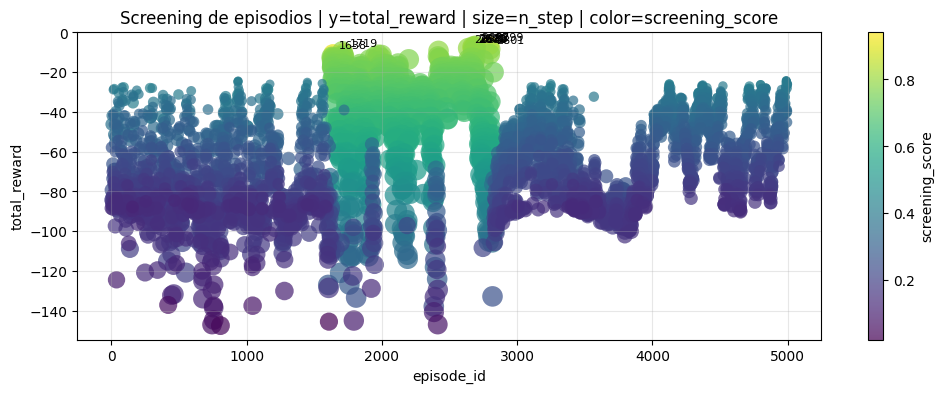

In [58]:
# --- CONFIGURACIÓN CELDA ---
PLOT_X = 'episode_id'
PLOT_Y = 'total_reward'
PLOT_SIZE = 'n_step'
PLOT_COLOR = 'screening_score'
ANNOTATE_TOP_N = 10
ALPHA = 0.70

plot_df = screening_view.copy()

x = pd.to_numeric(plot_df[PLOT_X], errors='coerce').to_numpy()
y = pd.to_numeric(plot_df[PLOT_Y], errors='coerce').to_numpy()

if PLOT_SIZE in plot_df.columns:
    size_01 = minmax_01(plot_df[PLOT_SIZE])
    sizes = 40 + 180 * size_01.to_numpy()
else:
    sizes = np.full(len(plot_df), 60.0)

if PLOT_COLOR in plot_df.columns:
    color_values = pd.to_numeric(plot_df[PLOT_COLOR], errors='coerce').fillna(0.0).to_numpy()
else:
    color_values = np.zeros(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 4))

sc = ax.scatter(
    x,
    y,
    s=sizes,
    c=color_values,
    cmap='viridis',
    alpha=ALPHA,
    edgecolor='none'
)

ax.set_xlabel(PLOT_X)
ax.set_ylabel(PLOT_Y)
ax.set_title(f'Screening de episodios | y={PLOT_Y} | size={PLOT_SIZE} | color={PLOT_COLOR}')
ax.grid(True, alpha=0.3)

cb = plt.colorbar(sc, ax=ax)
cb.set_label(PLOT_COLOR)

annot_df = screening_view.head(ANNOTATE_TOP_N)

for _, row in annot_df.iterrows():
    ax.annotate(
        str(int(row['episode_id'])),
        (row[PLOT_X], row[PLOT_Y]),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

plt.show()

## Caja 3 - Cargar episodio

In [59]:
# --- CONFIGURACIÓN CELDA ---
EPISODE_SOURCE = 'ranking'   # 'ranking' | 'manual'
RANK_ROW = 0
EPISODE_ID_MANUAL = 4500

if EPISODE_SOURCE == 'ranking':
    EPISODE_ID = int(screening_top_df.iloc[RANK_ROW]['episode_id'])
else:
    EPISODE_ID = int(EPISODE_ID_MANUAL)

print('EPISODE_ID seleccionado:', EPISODE_ID)

EPISODE_ID seleccionado: 2672


In [60]:
episode, source_chunk = load_episode_from_lookup(episode_lookup, EPISODE_ID)
print('source_chunk:', source_chunk)
print('episode keys:', list(episode.keys()))

step_data = episode['step_data']
interval_data = episode['interval_data']
end_data = episode['end_episode_data']

print('step_data keys:', len(step_data))
print('interval_data keys:', len(interval_data))
print('end_data keys:', len(end_data))


source_chunk: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\results_history_CartPole\cart_pole\20260416_2048\episodes_chunks_0026.json
episode keys: ['episode_id', 'step_data', 'interval_data', 'end_episode_data']
step_data keys: 37
interval_data keys: 73
end_data keys: 8


## Caja 4 - DataFrames step/interval + inventario de columnas
- Se construyen `step_df` e `interval_df` desde la estructura persistida del episodio.
- Además, se organizan las columnas por familias funcionales para dejar explícito qué bloques alimentan los análisis posteriores:
  - dinámica raw y norm;
  - controlador;
  - métricas principales;
  - compuertas y contribuciones;
  - acciones;
  - rewards asignados;
  - extras;
  - coordinación.

In [62]:
step_df = build_df(step_data).reset_index(drop=True)
interval_df = build_df(interval_data).reset_index(drop=True)

step_col_map = build_step_column_map(step_df)
interval_col_map = build_interval_column_map(interval_df)

print('step_df shape:', step_df.shape)
print('interval_df shape:', interval_df.shape)

display(step_df.head(3))
display(interval_df.head(5))


step_df shape: (4957, 36)
interval_df shape: (248, 72)


,t_sec,cart_position_raw,cart_velocity_raw,pendulum_angle_raw,pendulum_velocity_raw,cart_position_norm,cart_velocity_norm,pendulum_angle_norm,pendulum_velocity_norm,cart_force,...,u_eff_pendulum_angle,u_eff_cart_position,delta_u_eff_pendulum_angle,delta_u_eff_cart_position,kp_pendulum_angle,kp_cart_position,ki_pendulum_angle,ki_cart_position,kd_pendulum_angle,kd_cart_position
0,0.000,0.000000e+00,0.000000,0.157,0.000000,0.000000e+00,0.000000,0.149924,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0
1,0.001,7.452986e-07,0.001491,0.157,0.000062,1.490597e-07,0.000186,0.149924,0.000015,9.004412,...,0.22511,0.000000,0.22511,0.000000,1.5,0.5,1.5,0.5,0.5,0.5
2,0.002,2.981851e-06,0.002983,0.157,0.000122,5.963702e-07,0.000373,0.149924,0.000030,9.011013,...,0.22535,-0.000075,0.00024,-0.000075,1.5,0.5,1.5,0.5,0.5,0.5


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,...,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,coordination_credit_raw_pendulum_angle,coordination_credit_raw_cart_position,coordination_credit_share_pendulum_angle,coordination_credit_share_cart_position,extra_conditional_coordination_bonus_pendulum_angle,extra_conditional_coordination_bonus_cart_position
0,0,0,19,0.00,20,0.149927,0.000025,0.000380,0.003999,0.002534,...,0.082939,0.000000,0.0,0.0,0.034108,3.932282e-08,0.999970,0.000001,0.0,0.0
1,1,20,39,0.02,20,0.149910,0.000155,0.003469,0.012719,0.000291,...,0.084439,-0.001500,0.0,0.0,0.046317,0.000000e+00,0.999978,0.000000,0.0,0.0
2,2,40,59,0.04,20,0.149677,0.000453,0.013962,0.024632,0.000268,...,0.087646,-0.003207,0.0,0.0,0.057341,4.437294e-06,0.999905,0.000077,0.0,0.0
3,3,60,79,0.06,20,0.149007,0.000967,0.032880,0.039841,0.000447,...,0.092659,-0.005013,0.0,0.0,0.071328,4.676374e-07,0.999979,0.000007,0.0,0.0
4,4,80,99,0.08,20,0.147643,0.001752,0.058529,0.057746,0.000110,...,0.098947,-0.006288,0.0,0.0,0.076860,4.039385e-05,0.999462,0.000525,0.0,0.0


In [63]:
step_inventory_df = build_col_inventory_df(step_col_map)
step_inventory_df

,family,n_cols,cols
0,dynamic_raw,5,"[cart_position_raw, cart_velocity_raw, pendulu..."
1,dynamic_norm,4,"[cart_position_norm, cart_velocity_norm, pendu..."
2,controller_global,6,"[t_sec, cart_force, u_total, u_total_raw, is_s..."
3,controller_error,8,"[error_pendulum_angle, error_cart_position, de..."
4,controller_action,4,"[control_action_pendulum_angle, control_action..."
5,controller_effective_action,4,"[u_eff_pendulum_angle, u_eff_cart_position, de..."
6,controller_gains,6,"[kp_pendulum_angle, kp_cart_position, ki_pendu..."
7,other,0,[]


In [64]:
interval_inventory_df = build_col_inventory_df(interval_col_map)
interval_inventory_df

,family,n_cols,cols
0,interval_meta,5,"[interval_id, interval_start_step_idx, interva..."
1,principal_terms,6,"[L_e_pendulum_angle, L_e_cart_position, L_edot..."
2,principal_gates,4,"[principal_gate_L_edot_pendulum_angle, princip..."
3,principal_contributions,4,"[principal_contribution_L_edot_pendulum_angle,..."
4,processed_metric_aggregates,8,"[error_pendulum_angle_mean_squared, error_cart..."
5,agent_actions,6,"[action_kp_pendulum_angle, action_ki_pendulum_..."
6,global_reward,1,[global_interval_reward]
7,assigned_agent_rewards,6,"[reward_kp_pendulum_angle, reward_ki_pendulum_..."
8,extra_rewards,24,"[extra_penalty_instantaneous_pendulum_angle, e..."
9,coordination_rewards,8,"[coordination_task_potential, coordination_tas..."


In [65]:
analysis_input_df = pd.DataFrame([
    {
        'next_box': 'Caja 6.5 - Sanity Check de Validación de Rango de Normalización',
        'source_df': 'step_df',
        'families': ['dynamic_raw', 'dynamic_norm'],
    },
    {
        'next_box': 'Sanity check: Controller Data',
        'source_df': 'step_df',
        'families': [
            'controller_global',
            'controller_error',
            'controller_action',
            'controller_effective_action',
            'controller_gains',
        ],
    },
    {
        'next_box': 'Sanity check / análisis de reward',
        'source_df': 'interval_df',
        'families': [
            'principal_terms',
            'principal_gates',
            'principal_contributions',
            'processed_metric_aggregates',
            'agent_actions',
            'assigned_agent_rewards',
            'extra_rewards',
            'coordination_rewards',
        ],
    },
])

analysis_input_df

,next_box,source_df,families
0,Caja 6.5 - Sanity Check de Validación de Rango...,step_df,"[dynamic_raw, dynamic_norm]"
1,Sanity check: Controller Data,step_df,"[controller_global, controller_error, controll..."
2,Sanity check / análisis de reward,interval_df,"[principal_terms, principal_gates, principal_c..."


In [66]:
step_df.columns

Index(['t_sec', 'cart_position_raw', 'cart_velocity_raw', 'pendulum_angle_raw',
       'pendulum_velocity_raw', 'cart_position_norm', 'cart_velocity_norm',
       'pendulum_angle_norm', 'pendulum_velocity_norm', 'cart_force',
       'u_total', 'u_total_raw', 'is_saturated_global', 'delta_u_total',
       'error_pendulum_angle', 'error_cart_position',
       'delta_error_pendulum_angle', 'delta_error_cart_position',
       'derivative_error_pendulum_angle', 'derivative_error_cart_position',
       'integral_error_pendulum_angle', 'integral_error_cart_position',
       'control_action_pendulum_angle', 'control_action_cart_position',
       'delta_control_action_pendulum_angle',
       'delta_control_action_cart_position', 'u_eff_pendulum_angle',
       'u_eff_cart_position', 'delta_u_eff_pendulum_angle',
       'delta_u_eff_cart_position', 'kp_pendulum_angle', 'kp_cart_position',
       'ki_pendulum_angle', 'ki_cart_position', 'kd_pendulum_angle',
       'kd_cart_position'],
      dtype=

In [67]:
interval_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_t_start_sec', 'interval_n_steps', 'L_e_pendulum_angle',
       'L_e_cart_position', 'L_edot_pendulum_angle', 'L_edot_cart_position',
       'L_delta_u_pendulum_angle', 'L_delta_u_cart_position',
       'principal_gate_L_edot_pendulum_angle',
       'principal_gate_L_edot_cart_position',
       'principal_gate_L_delta_u_pendulum_angle',
       'principal_gate_L_delta_u_cart_position',
       'principal_contribution_L_edot_pendulum_angle',
       'principal_contribution_L_edot_cart_position',
       'principal_contribution_L_delta_u_pendulum_angle',
       'principal_contribution_L_delta_u_cart_position',
       'error_pendulum_angle_mean_squared', 'error_cart_position_mean_squared',
       'derivative_error_pendulum_angle_mean_squared',
       'derivative_error_cart_position_mean_squared',
       'delta_u_eff_pendulum_angle_mean_squared',
       'delta_u_eff_cart_position_mean_squared',
       'in

## Caja 5 - Ficha del episodio
- Se resume el episodio en una ficha compacta y legible.
- La ficha no solo reporta tamaño y término, sino también:
  - comportamiento físico;
  - intensidad de control;
  - uso de saturación;
  - consistencia básica del reward acumulado por intervalos.

In [68]:
n_steps = int(step_df.shape[0])
n_intervals = int(interval_df.shape[0])

t_end_sec = float(pd.to_numeric(step_df['t_sec'], errors='coerce').max())
sat_prp_steps = float(step_df['is_saturated_global'].astype(bool).mean())

reward_sum_intervals = float(
    pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0.0).sum()
)

reward_gap_end_vs_intervals = float(end_data['total_reward']) - reward_sum_intervals

principal_contrib_cols = interval_col_map['principal_contributions']
assigned_reward_cols = interval_col_map['assigned_agent_rewards']
extra_total_cols = [c for c in interval_df.columns if c.startswith('extra_total_')]
goal_bonus_cols = [c for c in interval_df.columns if c.startswith('extra_bonus_goal_')]
band_bonus_cols = [c for c in interval_df.columns if c.startswith('extra_bonus_band_')]

episode_core_card = {
    'episode_id': int(EPISODE_ID),
    'source_chunk': str(source_chunk),
    'end_terminated': bool(end_data['end_terminated']),
    'end_termination_reason': end_data['end_termination_reason'],
    'n_steps': n_steps,
    'n_intervals': n_intervals,
    't_end_sec': t_end_sec,
    'total_reward_end_data': float(end_data['total_reward']),
    'total_reward_sum_intervals': reward_sum_intervals,
    'reward_gap_end_vs_interval_sum': reward_gap_end_vs_intervals,
    'total_agent_decisions': int(end_data['total_agent_decisions']),
    'epsilon': float(end_data['epsilon']),
    'learning_rate': float(end_data['learning_rate']),
}

episode_physical_card = {
    'pendulum_angle_mean_abs': mean_abs_col(step_df, 'pendulum_angle_raw'),
    'pendulum_angle_max_abs': max_abs_col(step_df, 'pendulum_angle_raw'),
    'cart_position_mean_abs': mean_abs_col(step_df, 'cart_position_raw'),
    'cart_position_max_abs': max_abs_col(step_df, 'cart_position_raw'),
    'pendulum_velocity_mean_abs': mean_abs_col(step_df, 'pendulum_velocity_raw'),
    'cart_velocity_mean_abs': mean_abs_col(step_df, 'cart_velocity_raw'),
}

episode_control_card = {
    'u_total_mean_abs': mean_abs_col(step_df, 'u_total'),
    'u_total_raw_mean_abs': mean_abs_col(step_df, 'u_total_raw'),
    'delta_u_total_mean_abs': mean_abs_col(step_df, 'delta_u_total'),
    'cart_force_mean_abs': mean_abs_col(step_df, 'cart_force'),
    'u_eff_pendulum_mean_abs': mean_abs_col(step_df, 'u_eff_pendulum_angle'),
    'u_eff_cart_mean_abs': mean_abs_col(step_df, 'u_eff_cart_position'),
    'sat_prp_steps': sat_prp_steps,
}

episode_reward_card = {
    'global_interval_reward_mean': float(pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0.0).mean()),
    'global_interval_reward_min': float(pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0.0).min()),
    'global_interval_reward_max': float(pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0.0).max()),
    'principal_contribution_sum_total': sum_existing_frame_cols(interval_df, principal_contrib_cols),
    'assigned_reward_sum_all_agents': sum_existing_frame_cols(interval_df, assigned_reward_cols),
    'extra_total_sum_all_loops': sum_existing_frame_cols(interval_df, extra_total_cols),
    'coordination_reward_sum': sum_existing_frame_cols(interval_df, ['coordination_reward_total']),
    'goal_bonus_sum': sum_existing_frame_cols(interval_df, goal_bonus_cols),
    'band_bonus_sum': sum_existing_frame_cols(interval_df, band_bonus_cols),
}

episode_card_rows = []

for section_name, section_card in [
    ('core', episode_core_card),
    ('physical', episode_physical_card),
    ('control', episode_control_card),
    ('reward', episode_reward_card),
]:
    for metric_name, value in section_card.items():
        episode_card_rows.append({
            'section': section_name,
            'metric': metric_name,
            'value': value,
        })

episode_card_df = pd.DataFrame(episode_card_rows)
episode_card_df


,section,metric,value
0,core,episode_id,2672
1,core,source_chunk,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
2,core,end_terminated,True
3,core,end_termination_reason,stabilization_success
4,core,n_steps,4957
5,core,n_intervals,248
6,core,t_end_sec,4.956
7,core,total_reward_end_data,-7.960759
8,core,total_reward_sum_intervals,-7.960759
9,core,reward_gap_end_vs_interval_sum,0.0


In [69]:
end_data

{'end_terminated': True,
 'end_termination_reason': 'stabilization_success',
 'total_reward': -7.960759047309218,
 'total_agent_decisions': 248,
 'accumulated_band_bonus': 0.0,
 'goal_bonus': 0.0,
 'epsilon': 0.04608612762607016,
 'learning_rate': 0.026938742459490163}

## Caja 6 - Timeline del episodio (por intervalos)
- Se construye una vista interval-level rica y coherente con el pipeline real.
- La tabla final integra:
  - metadata temporal del intervalo;
  - agregados físicos desde `step_df`;
  - agregados de control y saturación;
  - métricas principales ya persistidas en `interval_df`;
  - acciones del agente;
  - rewards asignados, extras y coordinación.
- Esta caja debe dejar lista la base para leer causalmente el episodio antes de bajar al detalle por step.

In [70]:
base_cols = []

for family in [
    'interval_meta',
    'principal_terms',
    'principal_gates',
    'principal_contributions',
    'processed_metric_aggregates',
    'agent_actions',
    'global_reward',
    'assigned_agent_rewards',
    'extra_rewards',
    'coordination_rewards',
]:
    base_cols.extend(interval_col_map[family])

base_cols = list(dict.fromkeys(base_cols))

interval_timeline_df = interval_df[base_cols].copy()

interval_timeline_df['interval_t_end_sec'] = [
    float(step_df.loc[int(b), 't_sec'])
    for b in interval_timeline_df['interval_end_step_idx']
]

interval_timeline_df['interval_t_mid_sec'] = 0.5 * (
    interval_timeline_df['interval_t_start_sec'] +
    interval_timeline_df['interval_t_end_sec']
)

agg_jobs = [
    ('pendulum_angle_raw', 'mean', 'pendulum_angle_mean'),
    ('pendulum_angle_raw', 'mean_abs', 'pendulum_angle_mean_abs'),
    ('pendulum_velocity_raw', 'mean_abs', 'pendulum_velocity_mean_abs'),
    ('cart_position_raw', 'mean', 'cart_position_mean'),
    ('cart_position_raw', 'mean_abs', 'cart_position_mean_abs'),
    ('cart_velocity_raw', 'mean_abs', 'cart_velocity_mean_abs'),
    ('cart_force', 'mean_abs', 'cart_force_mean_abs'),

    ('u_total', 'mean', 'u_total_mean'),
    ('u_total', 'mean_abs', 'u_total_mean_abs'),
    ('u_total_raw', 'mean_abs', 'u_total_raw_mean_abs'),
    ('delta_u_total', 'mean_abs', 'delta_u_total_mean_abs'),
    ('is_saturated_global', 'bool_mean', 'sat_prp_interval'),

    ('error_pendulum_angle', 'mean_abs', 'e_pendulum_mean_abs'),
    ('derivative_error_pendulum_angle', 'mean_abs', 'edot_pendulum_mean_abs'),
    ('integral_error_pendulum_angle', 'mean_abs', 'eint_pendulum_mean_abs'),
    ('u_eff_pendulum_angle', 'mean_abs', 'u_eff_pendulum_mean_abs'),
    ('delta_u_eff_pendulum_angle', 'mean_abs', 'delta_u_eff_pendulum_mean_abs'),

    ('error_cart_position', 'mean_abs', 'e_cart_mean_abs'),
    ('derivative_error_cart_position', 'mean_abs', 'edot_cart_mean_abs'),
    ('integral_error_cart_position', 'mean_abs', 'eint_cart_mean_abs'),
    ('u_eff_cart_position', 'mean_abs', 'u_eff_cart_mean_abs'),
    ('delta_u_eff_cart_position', 'mean_abs', 'delta_u_eff_cart_mean_abs'),

    ('kp_pendulum_angle', 'mean', 'kp_pendulum_angle_mean'),
    ('ki_pendulum_angle', 'mean', 'ki_pendulum_angle_mean'),
    ('kd_pendulum_angle', 'mean', 'kd_pendulum_angle_mean'),
    ('kp_cart_position', 'mean', 'kp_cart_position_mean'),
    ('ki_cart_position', 'mean', 'ki_cart_position_mean'),
    ('kd_cart_position', 'mean', 'kd_cart_position_mean'),
]

interval_timeline_df = add_interval_aggs(interval_timeline_df, step_df, agg_jobs)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'principal_terms_total_pendulum_angle',
    [
        'L_e_pendulum_angle',
        'L_edot_pendulum_angle',
        'L_I_pendulum_angle',
        'L_u_pendulum_angle',
        'L_delta_u_pendulum_angle',
    ]
)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'principal_terms_total_cart_position',
    [
        'L_e_cart_position',
        'L_edot_cart_position',
        'L_I_cart_position',
        'L_u_cart_position',
        'L_delta_u_cart_position',
    ]
)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'principal_terms_total_all',
    [
        'principal_terms_total_pendulum_angle',
        'principal_terms_total_cart_position',
    ]
)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'assigned_rewards_total',
    interval_col_map['assigned_agent_rewards']
)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'extra_total_all',
    [c for c in interval_timeline_df.columns if c.startswith('extra_total_')]
)

interval_timeline_df = add_row_sum(
    interval_timeline_df,
    'principal_contribution_total_all',
    interval_col_map['principal_contributions']
)

interval_timeline_df.head(5)

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,...,kd_pendulum_angle_mean,kp_cart_position_mean,ki_cart_position_mean,kd_cart_position_mean,principal_terms_total_pendulum_angle,principal_terms_total_cart_position,principal_terms_total_all,assigned_rewards_total,extra_total_all,principal_contribution_total_all
0,0,0,19,0.00,20,0.149927,0.000025,0.000380,0.003999,0.002534,...,0.525,0.525,0.525,0.525,0.152841,0.004024,0.156864,-0.370059,0.0,-0.000002
1,1,20,39,0.02,20,0.149910,0.000155,0.003469,0.012719,0.000291,...,0.025,0.025,0.025,0.025,0.153669,0.012874,0.166543,-0.372484,0.0,-0.000025
2,2,40,59,0.04,20,0.149677,0.000453,0.013962,0.024632,0.000268,...,0.475,0.000,0.000,0.475,0.163907,0.025087,0.188994,-0.374435,0.0,-0.000115
3,3,60,79,0.06,20,0.149007,0.000967,0.032880,0.039841,0.000447,...,0.025,0.475,0.000,0.025,0.182334,0.040815,0.223150,-0.376308,0.0,-0.000384
4,4,80,99,0.08,20,0.147643,0.001752,0.058529,0.057746,0.000110,...,0.475,0.025,0.000,0.475,0.206281,0.059516,0.265797,-0.373936,0.0,-0.000971


In [71]:
interval_timeline_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_t_start_sec', 'interval_n_steps', 'L_e_pendulum_angle',
       'L_e_cart_position', 'L_edot_pendulum_angle', 'L_edot_cart_position',
       'L_delta_u_pendulum_angle',
       ...
       'kd_pendulum_angle_mean', 'kp_cart_position_mean',
       'ki_cart_position_mean', 'kd_cart_position_mean',
       'principal_terms_total_pendulum_angle',
       'principal_terms_total_cart_position', 'principal_terms_total_all',
       'assigned_rewards_total', 'extra_total_all',
       'principal_contribution_total_all'],
      dtype='object', length=108)

In [72]:
interval_view_cols = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'interval_t_mid_sec',
    'interval_n_steps',

    'pendulum_angle_mean_abs',
    'cart_position_mean_abs',
    'pendulum_velocity_mean_abs',
    'cart_velocity_mean_abs',

    'u_total_mean_abs',
    'delta_u_total_mean_abs',
    'sat_prp_interval',

    'principal_terms_total_pendulum_angle',
    'principal_terms_total_cart_position',
    'principal_terms_total_all',

    'global_interval_reward',
    'assigned_rewards_total',
    'extra_total_all',
    'coordination_reward_total',

    'action_kp_pendulum_angle',
    'action_ki_pendulum_angle',
    'action_kd_pendulum_angle',
    'action_kp_cart_position',
    'action_ki_cart_position',
    'action_kd_cart_position',
]

interval_timeline_view_df = interval_timeline_df[interval_view_cols].copy()
interval_timeline_view_df

,interval_id,interval_t_start_sec,interval_t_end_sec,interval_t_mid_sec,interval_n_steps,pendulum_angle_mean_abs,cart_position_mean_abs,pendulum_velocity_mean_abs,cart_velocity_mean_abs,u_total_mean_abs,...,global_interval_reward,assigned_rewards_total,extra_total_all,coordination_reward_total,action_kp_pendulum_angle,action_ki_pendulum_angle,action_kd_pendulum_angle,action_kp_cart_position,action_ki_cart_position,action_kd_cart_position
0,0,0.00,0.019,0.0095,20,0.157004,0.000092,0.000535,0.014211,0.214782,...,-0.123353,-0.370059,0.0,0.000000,2,2,0,0,0,0
1,1,0.02,0.039,0.0295,20,0.156985,0.000717,0.004688,0.050401,0.304733,...,-0.124161,-0.372484,0.0,0.000000,2,2,0,0,0,0
2,2,0.04,0.059,0.0495,20,0.156742,0.002190,0.021524,0.098641,0.370508,...,-0.124812,-0.374435,0.0,0.000000,2,2,2,1,1,2
3,3,0.06,0.079,0.0695,20,0.156040,0.004747,0.051379,0.159812,0.472621,...,-0.125436,-0.376308,0.0,0.000000,2,2,0,2,1,0
4,4,0.08,0.099,0.0895,20,0.154611,0.008658,0.092176,0.231843,0.497288,...,-0.124645,-0.373936,0.0,0.000000,2,2,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,243,4.86,4.879,4.8695,20,0.000273,0.108309,0.015757,0.101017,0.007112,...,-0.002848,-0.008543,0.0,0.000000,1,2,0,1,0,0
244,244,4.88,4.899,4.8895,20,0.000576,0.106302,0.014013,0.099190,0.020791,...,-0.002706,-0.008119,0.0,0.000041,2,0,2,1,1,2
245,245,4.90,4.919,4.9095,20,0.000830,0.104346,0.011799,0.096837,0.008257,...,-0.002570,-0.007711,0.0,0.000071,1,2,0,1,1,0
246,246,4.92,4.939,4.9295,20,0.001047,0.102430,0.009538,0.094390,0.023100,...,-0.002471,-0.007413,0.0,0.000078,1,0,2,1,1,2


## Caja 7 - Timeline del episodio (por step)

In [73]:
def plot_many_columns(
    df, cols, colors, styles, alphas,
    col_names=None,
    title="Análisis", figsize=(14, 5),
    interval_lines=interval_df['interval_end_step_idx'],
    x_col=None,              # None => steps, 't_sec' => tiempo (s)
    y_lim=None,
):
    """
    Genera un gráfico multi-eje para análisis de señales de simulación.
    """
    x_step = np.arange(len(df)) if x_col is None else df[x_col].to_numpy()

    label_size = 16
    tick_size = 14
    legend_size = 10

    if col_names is None:
        col_names = cols
    col_names = (list(col_names) + list(cols))[:len(cols)]

    fig, ax_main = plt.subplots(figsize=figsize)
    axes = [ax_main]

    ax_main.set_title(title, fontsize=label_size + 2, pad=20)
    ax_main.set_xlabel("Steps (-)" if x_col is None else f"{x_col} (s)", fontsize=label_size)
    ax_main.grid(True, linestyle=':', alpha=0.7)

    for i in range(1, len(cols)):
        new_ax = ax_main.twinx()
        if i > 1:
            new_ax.spines['right'].set_position(('outward', 70 * (i-1)))
        axes.append(new_ax)

    for i, (col, name, color, style, a) in enumerate(zip(cols, col_names, colors, styles, alphas)):
        if col in df.columns:
            ax = axes[i]
            ax.plot(x_step, df[col], label=name, color=color, linestyle=style, alpha=a)
            ax.set_ylabel(name, color=color, fontsize=label_size, fontweight='bold')
            ax.tick_params(axis='x', labelsize=tick_size)
            ax.tick_params(axis='y', labelcolor=color, labelsize=tick_size)
            if i > 0:
                ax.spines['right'].set_color(color)
            if y_lim is not None:
                ax.set_ylim(y_lim)

    # interval lines: si x_col es tiempo, sigue dibujando en step (más simple y robusto)
    for s in pd.to_numeric(interval_lines, errors='coerce').dropna().astype(int).tolist():
        ax_main.axvline(x=(s if x_col is None else x_step[s]), color='gray', alpha=0.3,
                        linestyle=':', linewidth=0.8)

    if 'is_saturated_global' in df.columns:
        ax_main.fill_between(
            x_step, 0, 1, where=df['is_saturated_global'],
            color='red', alpha=0.1, transform=ax_main.get_xaxis_transform()
        )

    lines, labels = [], []
    for ax in axes:
        l, lb = ax.get_legend_handles_labels()
        lines.extend(l); labels.extend(lb)
    ax_main.legend(lines, labels, loc='upper left', fontsize=legend_size)

    plt.tight_layout()
    plt.show()

### Sanity check: Dynamic Data

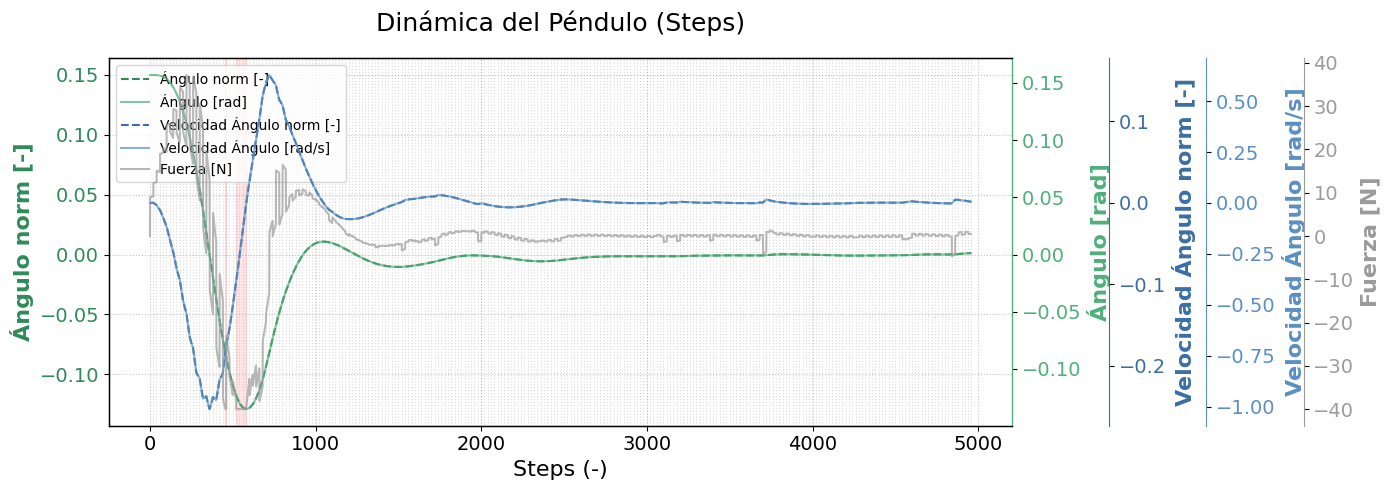

In [29]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['pendulum_angle_norm', 'pendulum_angle_raw', 'pendulum_velocity_norm', 'pendulum_velocity_raw', 'cart_force']
col_names    = ['Ángulo norm [-]', 'Ángulo [rad]', 'Velocidad Ángulo norm [-]', 'Velocidad Ángulo [rad/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas  = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

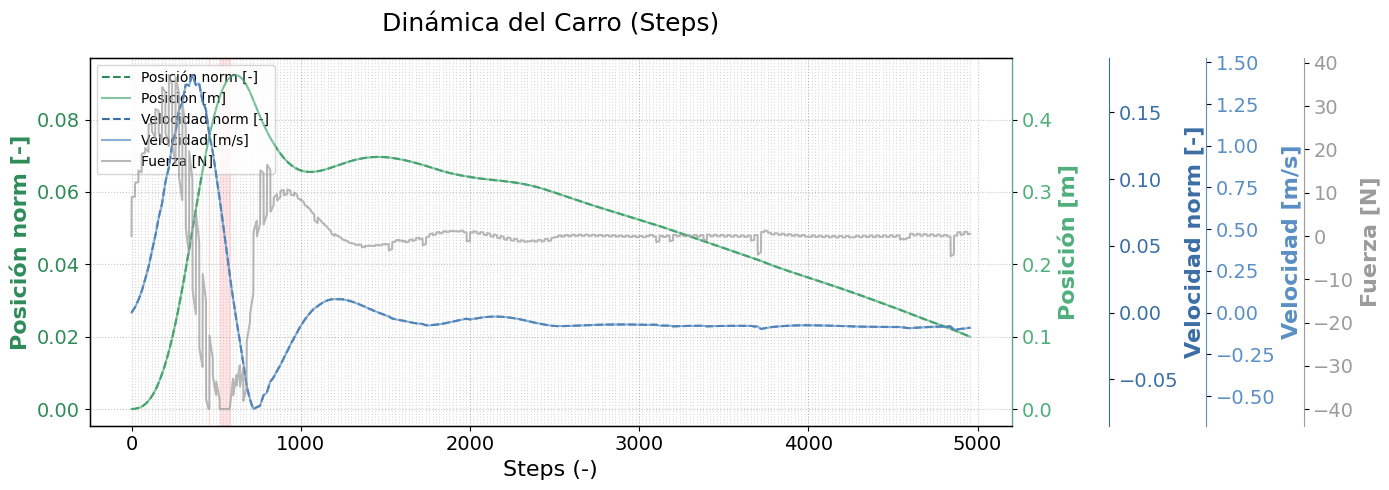

In [30]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['cart_position_norm', 'cart_position_raw', 'cart_velocity_norm', 'cart_velocity_raw', 'cart_force']
col_names = ['Posición norm [-]', 'Posición [m]', 'Velocidad norm [-]', 'Velocidad [m/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Caja 6.5 - Sanity Check de Validación de Rangos de Normalización
- Se valida formalmente la consistencia entre el estado físico (`*_raw`) y el estado normalizado (`*_norm`) registrado por step.
- El objetivo es distinguir si un comportamiento extraño proviene del fenómeno físico o de una representación mal escalada para el controlador.
- Se revisa:
  - cumplimiento del rango raw configurado;
  - cumplimiento del rango norm esperado;
  - proporción de clipping;
  - correspondencia entre normalización observada y normalización esperada.

In [34]:
metadata_files = sorted(RUN_DIR.resolve().rglob('*metadata*.json'))
metadata_path = metadata_files[0]

run_metadata = load_json(metadata_path)
config_main = run_metadata['config_main']

state_norm_cfg = config_main['dynamic_system']['state_normalization']
ranges_params = state_norm_cfg['ranges_params']
output_limits = state_norm_cfg['output_limits']

norm_validation_df = build_state_norm_validation_df(step_df, ranges_params, output_limits)

print('metadata_path:', metadata_path)
print('variables normalizadas:', list(ranges_params.keys()))

norm_validation_df

metadata_path: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\results_history_CartPole\cart_pole\20260416_2048\metadata.json
variables normalizadas: ['pendulum_angle', 'pendulum_velocity', 'cart_position', 'cart_velocity']


,var_name,raw_col,norm_col,raw_min_cfg,raw_max_cfg,norm_min_cfg,norm_max_cfg,raw_min_obs,raw_max_obs,norm_min_obs,norm_max_obs,prp_out_of_range_raw,prp_clipped_norm,mapping_mae_norm
0,pendulum_angle,pendulum_angle_raw,pendulum_angle_norm,-1.0472,1.0472,-1.0,1.0,-0.135135,0.157012,-0.129044,0.149935,0.0,0.0,0.0
1,pendulum_velocity,pendulum_velocity_raw,pendulum_velocity_norm,-4.0000,4.0000,-1.0,1.0,-1.011720,0.628324,-0.252930,0.157081,0.0,0.0,0.0
2,cart_position,cart_position_raw,cart_position_norm,-5.0000,5.0000,-1.0,1.0,0.000000,0.461719,0.000000,0.092344,0.0,0.0,0.0
3,cart_velocity,cart_velocity_raw,cart_velocity_norm,-8.0000,8.0000,-1.0,1.0,-0.577817,1.424108,-0.072227,0.178014,0.0,0.0,0.0


In [35]:
norm_summary_df = norm_validation_df.loc[:, [
    'var_name',
    'raw_min_cfg',
    'raw_max_cfg',
    'raw_min_obs',
    'raw_max_obs',
    'norm_min_cfg',
    'norm_max_cfg',
    'norm_min_obs',
    'norm_max_obs',
    'prp_out_of_range_raw',
    'prp_clipped_norm',
    'mapping_mae_norm',
]].copy()

norm_summary_df

,var_name,raw_min_cfg,raw_max_cfg,raw_min_obs,raw_max_obs,norm_min_cfg,norm_max_cfg,norm_min_obs,norm_max_obs,prp_out_of_range_raw,prp_clipped_norm,mapping_mae_norm
0,pendulum_angle,-1.0472,1.0472,-0.135135,0.157012,-1.0,1.0,-0.129044,0.149935,0.0,0.0,0.0
1,pendulum_velocity,-4.0000,4.0000,-1.011720,0.628324,-1.0,1.0,-0.252930,0.157081,0.0,0.0,0.0
2,cart_position,-5.0000,5.0000,0.000000,0.461719,-1.0,1.0,0.000000,0.092344,0.0,0.0,0.0
3,cart_velocity,-8.0000,8.0000,-0.577817,1.424108,-1.0,1.0,-0.072227,0.178014,0.0,0.0,0.0


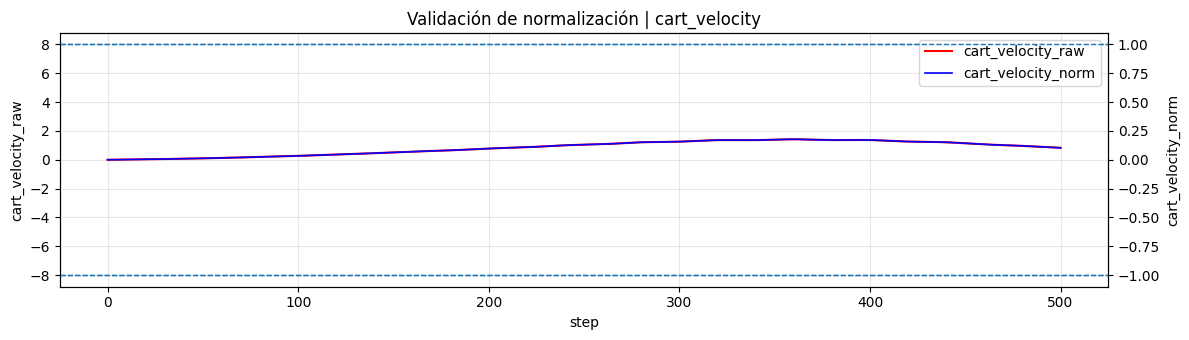

In [50]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = 'cart_velocity'
T_START = 0
T_END = min(len(step_df) - 1, 500)

raw_col = f'{VAR_NAME}_raw'
norm_col = f'{VAR_NAME}_norm'

raw_min_cfg = ranges_params[VAR_NAME][0]
raw_max_cfg = ranges_params[VAR_NAME][1]
norm_min_cfg = output_limits[0]
norm_max_cfg = output_limits[1]

plot_df = step_df.loc[T_START:T_END, [raw_col, norm_col]].copy()

fig, ax1 = plt.subplots(figsize=(12, 3.5))

ax1.plot(plot_df.index, plot_df[raw_col], color='r', label=raw_col, linewidth=1.5)
ax1.axhline(raw_min_cfg, linestyle='--', linewidth=1)
ax1.axhline(raw_max_cfg, linestyle='--', linewidth=1)
ax1.set_xlabel('step')
ax1.set_ylabel(raw_col)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(plot_df.index, plot_df[norm_col], color='b', label=norm_col, linewidth=1.2)
ax2.axhline(norm_min_cfg, linestyle='--', linewidth=1)
ax2.axhline(norm_max_cfg, linestyle='--', linewidth=1)
ax2.set_ylabel(norm_col)

ax1.set_title(f'Validación de normalización | {VAR_NAME}')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

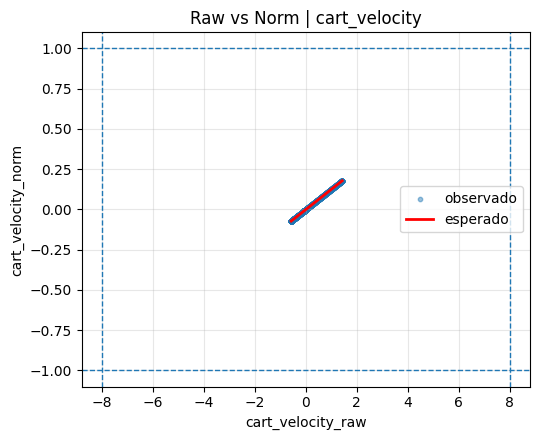

In [51]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = 'cart_velocity'

raw_col = f'{VAR_NAME}_raw'
norm_col = f'{VAR_NAME}_norm'

raw_values = pd.to_numeric(step_df[raw_col], errors='coerce').to_numpy()
obs_norm_values = pd.to_numeric(step_df[norm_col], errors='coerce').to_numpy()

exp_norm_values = linear_normalize_clipped(
    raw_values,
    ranges_params[VAR_NAME][0],
    ranges_params[VAR_NAME][1],
    output_limits[0],
    output_limits[1]
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.scatter(raw_values, obs_norm_values, s=10, alpha=0.45, label='observado')
order = np.argsort(raw_values)
ax.plot(raw_values[order], exp_norm_values[order], color='r', linewidth=2, label='esperado')

ax.axvline(ranges_params[VAR_NAME][0], linestyle='--', linewidth=1)
ax.axvline(ranges_params[VAR_NAME][1], linestyle='--', linewidth=1)
ax.axhline(output_limits[0], linestyle='--', linewidth=1)
ax.axhline(output_limits[1], linestyle='--', linewidth=1)

ax.set_xlabel(raw_col)
ax.set_ylabel(norm_col)
ax.set_title(f'Raw vs Norm | {VAR_NAME}')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

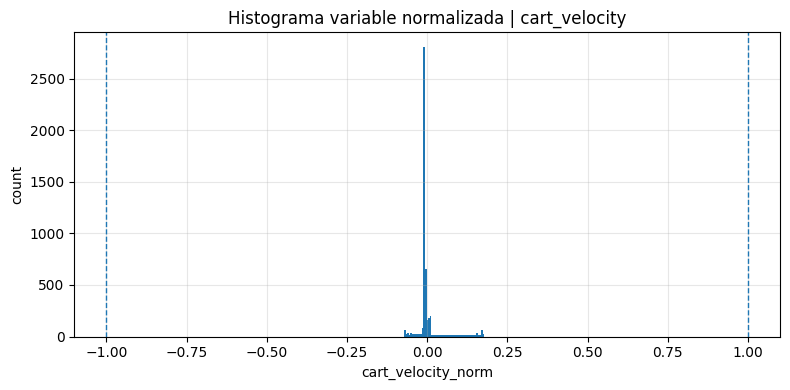

In [52]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = 'cart_velocity'
BINS = 50

norm_col = f'{VAR_NAME}_norm'

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(pd.to_numeric(step_df[norm_col], errors='coerce').dropna(), bins=BINS)
ax.axvline(output_limits[0], linestyle='--', linewidth=1)
ax.axvline(output_limits[1], linestyle='--', linewidth=1)

ax.set_xlabel(norm_col)
ax.set_ylabel('count')
ax.set_title(f'Histograma variable normalizada | {VAR_NAME}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

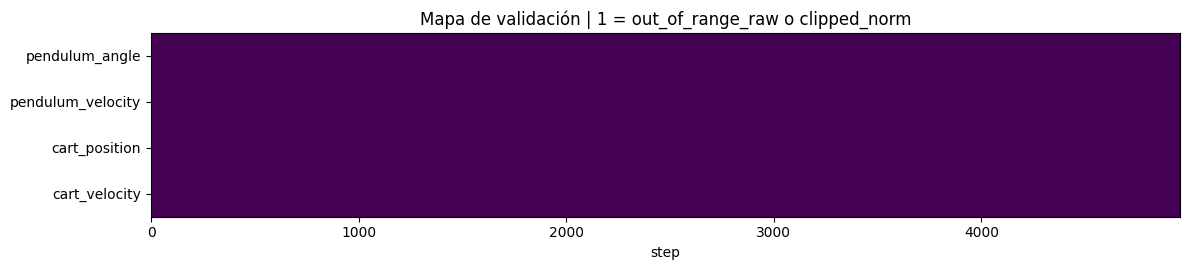

In [47]:
norm_flags = []

for var_name in ranges_params.keys():
    raw_col = f'{var_name}_raw'
    norm_col = f'{var_name}_norm'

    raw_values = pd.to_numeric(step_df[raw_col], errors='coerce').to_numpy()
    norm_values = pd.to_numeric(step_df[norm_col], errors='coerce').to_numpy()

    raw_flag = (raw_values < ranges_params[var_name][0]) | (raw_values > ranges_params[var_name][1])
    clip_flag = (norm_values <= output_limits[0]) | (norm_values >= output_limits[1])

    combined_flag = raw_flag | clip_flag
    norm_flags.append(combined_flag.astype(int))

norm_flag_matrix = np.vstack(norm_flags)

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.imshow(norm_flag_matrix, aspect='auto', interpolation='nearest')

ax.set_yticks(np.arange(len(ranges_params)))
ax.set_yticklabels(list(ranges_params.keys()))
ax.set_xlabel('step')
ax.set_title('Mapa de validación | 1 = out_of_range_raw o clipped_norm')

plt.tight_layout()
plt.show()

In [53]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = 'cart_velocity'
TOP_N = 20

raw_col = f'{VAR_NAME}_raw'
norm_col = f'{VAR_NAME}_norm'

raw_values = pd.to_numeric(step_df[raw_col], errors='coerce')
norm_values = pd.to_numeric(step_df[norm_col], errors='coerce')

exp_norm_values = pd.Series(
    linear_normalize_clipped(
        raw_values.to_numpy(),
        ranges_params[VAR_NAME][0],
        ranges_params[VAR_NAME][1],
        output_limits[0],
        output_limits[1]
    ),
    index=raw_values.index
)

critical_df = pd.DataFrame({
    'step_idx': step_df.index,
    raw_col: raw_values,
    norm_col: norm_values,
    'expected_norm': exp_norm_values,
})

critical_df['is_out_of_range_raw'] = (
    (critical_df[raw_col] < ranges_params[VAR_NAME][0]) |
    (critical_df[raw_col] > ranges_params[VAR_NAME][1])
)

critical_df['is_clipped_norm'] = (
    (critical_df[norm_col] <= output_limits[0]) |
    (critical_df[norm_col] >= output_limits[1])
)

critical_df['mapping_abs_error'] = (critical_df[norm_col] - critical_df['expected_norm']).abs()

critical_df = critical_df.sort_values(
    ['is_out_of_range_raw', 'is_clipped_norm', 'mapping_abs_error'],
    ascending=[False, False, False]
).head(TOP_N)

critical_df

,step_idx,cart_velocity_raw,cart_velocity_norm,expected_norm,is_out_of_range_raw,is_clipped_norm,mapping_abs_error
0,0,0.000000,0.000000,0.000000,False,False,0.0
1,1,0.001491,0.000186,0.000186,False,False,0.0
2,2,0.002983,0.000373,0.000373,False,False,0.0
3,3,0.004475,0.000559,0.000559,False,False,0.0
4,4,0.005969,0.000746,0.000746,False,False,0.0
5,5,0.007463,0.000933,0.000933,False,False,0.0
6,6,0.008958,0.001120,0.001120,False,False,0.0
7,7,0.010454,0.001307,0.001307,False,False,0.0
8,8,0.011951,0.001494,0.001494,False,False,0.0
9,9,0.013449,0.001681,0.001681,False,False,0.0


### Sanity check: Controller Data
- Se valida la consistencia interna del bloque de control usando solo las señales efectivamente persistidas.
- El objetivo es revisar:
  - saturación global del actuador;
  - diferencia entre acción calculada y acción efectiva;
  - reparto real del control entre lazos;
  - coherencia temporal entre error, acción de control y ganancias.
- Este bloque no busca todavía interpretar la recompensa, sino verificar que la capa de control esté operando de forma legible y consistente.

In [76]:
controller_loop_vars = get_controller_loop_vars(step_df)

controller_sc_df = build_controller_sanity_df(step_df, controller_loop_vars)
controller_summary_df = build_controller_summary_df(controller_sc_df, controller_loop_vars)

print('controller_loop_vars:', controller_loop_vars)
controller_summary_df

controller_loop_vars: ['pendulum_angle', 'cart_position']


,section,metric,value
0,global,sat_prp_steps,0.013113
1,global,u_total_raw_mean_abs,0.120108
2,global,u_total_saturated_mean_abs,0.118665
3,global,u_total_sat_gap_mean_abs,0.001444
4,global,u_total_sat_gap_max_abs,0.202309
5,pendulum_angle,error_mean_abs,0.018368
6,pendulum_angle,control_action_mean_abs,0.117280
7,pendulum_angle,u_eff_mean_abs,0.115890
8,pendulum_angle,u_eff_loss_mean_abs,0.001390
9,pendulum_angle,delta_control_action_mean_abs,0.002729


In [78]:
controller_interval_jobs = [
    ('is_saturated_global_int', 'mean', 'sat_prp_interval_ctrl'),
    ('u_total_raw', 'mean_abs', 'u_total_raw_mean_abs_ctrl'),
    ('u_total', 'mean_abs', 'u_total_saturated_mean_abs_ctrl'),
    ('u_total_sat_gap_abs', 'mean_abs', 'u_total_sat_gap_mean_abs_ctrl'),
]

for var_name in controller_loop_vars:
    controller_interval_jobs.extend([
        (f'error_abs_{var_name}', 'mean', f'error_mean_abs_{var_name}_ctrl'),
        (f'control_action_abs_{var_name}', 'mean', f'control_action_mean_abs_{var_name}_ctrl'),
        (f'u_eff_abs_{var_name}', 'mean', f'u_eff_mean_abs_{var_name}_ctrl'),
        (f'u_eff_loss_abs_{var_name}', 'mean', f'u_eff_loss_mean_abs_{var_name}_ctrl'),
        (f'control_share_{var_name}', 'mean', f'control_share_mean_{var_name}_ctrl'),
        (f'u_eff_share_{var_name}', 'mean', f'u_eff_share_mean_{var_name}_ctrl'),
    ])

controller_interval_df = add_interval_aggs(
    interval_df[['interval_id', 'interval_start_step_idx', 'interval_end_step_idx']].copy(),
    controller_sc_df,
    controller_interval_jobs
)

controller_interval_df.head(10)

,interval_id,interval_start_step_idx,interval_end_step_idx,sat_prp_interval_ctrl,u_total_raw_mean_abs_ctrl,u_total_saturated_mean_abs_ctrl,u_total_sat_gap_mean_abs_ctrl,error_mean_abs_pendulum_angle_ctrl,control_action_mean_abs_pendulum_angle_ctrl,u_eff_mean_abs_pendulum_angle_ctrl,u_eff_loss_mean_abs_pendulum_angle_ctrl,control_share_mean_pendulum_angle_ctrl,u_eff_share_mean_pendulum_angle_ctrl,error_mean_abs_cart_position_ctrl,control_action_mean_abs_cart_position_ctrl,u_eff_mean_abs_cart_position_ctrl,u_eff_loss_mean_abs_cart_position_ctrl,control_share_mean_cart_position_ctrl,u_eff_share_mean_cart_position_ctrl
0,0,0,19,0.0,0.214782,0.214782,0.0,0.142430,0.216001,0.216001,0.0,0.994421,0.994421,0.000016,0.001219,0.001219,0.0,0.005579,0.005579
1,1,20,39,0.0,0.304733,0.304733,0.0,0.149914,0.304873,0.304873,0.0,0.999399,0.999399,0.000133,0.000140,0.000140,0.0,0.000601,0.000601
2,2,40,59,0.0,0.370508,0.370508,0.0,0.149697,0.379627,0.379627,0.0,0.976789,0.976789,0.000418,0.009119,0.009119,0.0,0.023211,0.023211
3,3,60,79,0.0,0.472621,0.472621,0.0,0.149055,0.473677,0.473677,0.0,0.997518,0.997518,0.000918,0.001056,0.001056,0.0,0.002482,0.002482
4,4,80,99,0.0,0.497288,0.497288,0.0,0.147729,0.518998,0.518998,0.0,0.960054,0.960054,0.001686,0.021710,0.021710,0.0,0.039946,0.039946
5,5,100,119,0.0,0.639411,0.639411,0.0,0.145547,0.640735,0.640735,0.0,0.997546,0.997546,0.002757,0.001323,0.001323,0.0,0.002454,0.002454
6,6,120,139,0.0,0.590574,0.590574,0.0,0.142214,0.629061,0.629061,0.0,0.942398,0.942398,0.004193,0.038487,0.038487,0.0,0.057602,0.057602
7,7,140,159,0.0,0.721156,0.721156,0.0,0.137683,0.723399,0.723399,0.0,0.996582,0.996582,0.006000,0.002243,0.002243,0.0,0.003418,0.003418
8,8,160,179,0.0,0.576950,0.576950,0.0,0.131750,0.634201,0.634201,0.0,0.916931,0.916931,0.008218,0.057251,0.057251,0.0,0.083069,0.083069
9,9,180,199,0.0,0.832235,0.832235,0.0,0.124505,0.835459,0.835459,0.0,0.995191,0.995191,0.010822,0.003224,0.003224,0.0,0.004809,0.004809


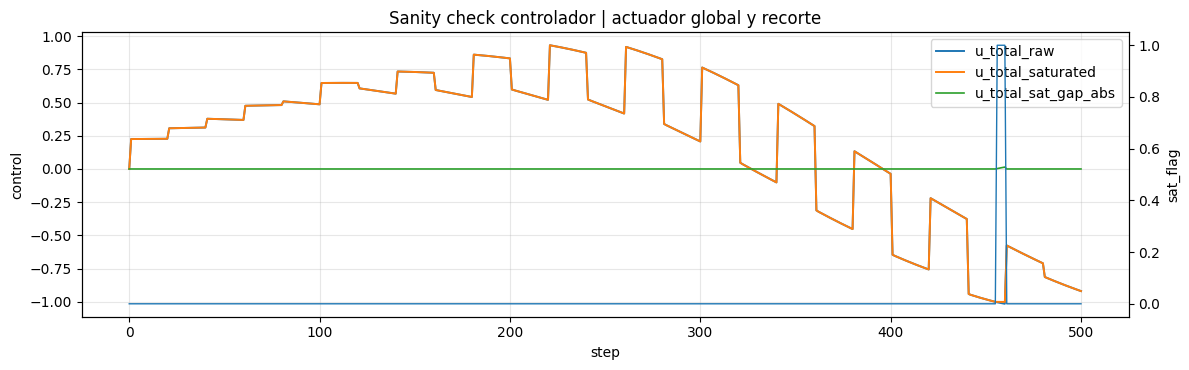

In [80]:
# --- CONFIGURACIÓN CELDA ---
T_START = 0
T_END = min(len(controller_sc_df) - 1, 500)

plot_df = controller_sc_df.loc[T_START:T_END].copy()

fig, ax1 = plt.subplots(figsize=(12, 3.8))

ax1.plot(plot_df.index, plot_df['u_total_raw'], label='u_total_raw', linewidth=1.4)
ax1.plot(plot_df.index, plot_df['u_total'], label='u_total_saturated', linewidth=1.4)
ax1.plot(plot_df.index, plot_df['u_total_sat_gap_abs'], label='u_total_sat_gap_abs', linewidth=1.2)

ax1.set_xlabel('step')
ax1.set_ylabel('control')
ax1.set_title('Sanity check controlador | actuador global y recorte')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(plot_df.index, plot_df['is_saturated_global_int'], label='is_saturated_global', linewidth=1.0)
ax2.set_ylabel('sat_flag')

plt.tight_layout()
plt.show()

**Qué valida**

- cuánto difiere u_total_raw de u_total_saturated;
- cuándo aparece saturación;
- y cuánto recorta realmente el actuador global.

Eso es exactamente coherente con cómo ControllerBase calcula u_total_raw, satura globalmente y luego reparte el escalado a cada lazo mediante u_eff_i.

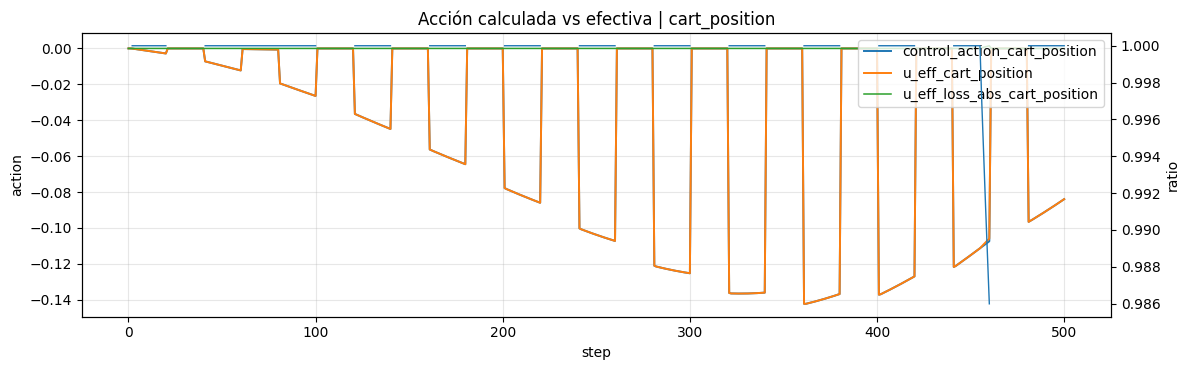

In [82]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = controller_loop_vars[1]
T_START = 0
T_END = min(len(controller_sc_df) - 1, 500)

control_col = f'control_action_{VAR_NAME}'
u_eff_col = f'u_eff_{VAR_NAME}'
loss_col = f'u_eff_loss_abs_{VAR_NAME}'
ratio_col = f'u_eff_ratio_{VAR_NAME}'

plot_df = controller_sc_df.loc[T_START:T_END].copy()

fig, ax1 = plt.subplots(figsize=(12, 3.8))

ax1.plot(plot_df.index, plot_df[control_col], label=control_col, linewidth=1.4)
ax1.plot(plot_df.index, plot_df[u_eff_col], label=u_eff_col, linewidth=1.4)
ax1.plot(plot_df.index, plot_df[loss_col], label=loss_col, linewidth=1.1)

ax1.set_xlabel('step')
ax1.set_ylabel('action')
ax1.set_title(f'Acción calculada vs efectiva | {VAR_NAME}')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(plot_df.index, plot_df[ratio_col], label=ratio_col, linewidth=1.0)
ax2.set_ylabel('ratio')

plt.tight_layout()
plt.show()

**Qué valida**

- si el lazo mantiene su intención al pasar de `control_action_*` a `u_eff_*`;
- cuánto pierde por saturación global;
- y si el ratio efectivo se mantiene razonable.

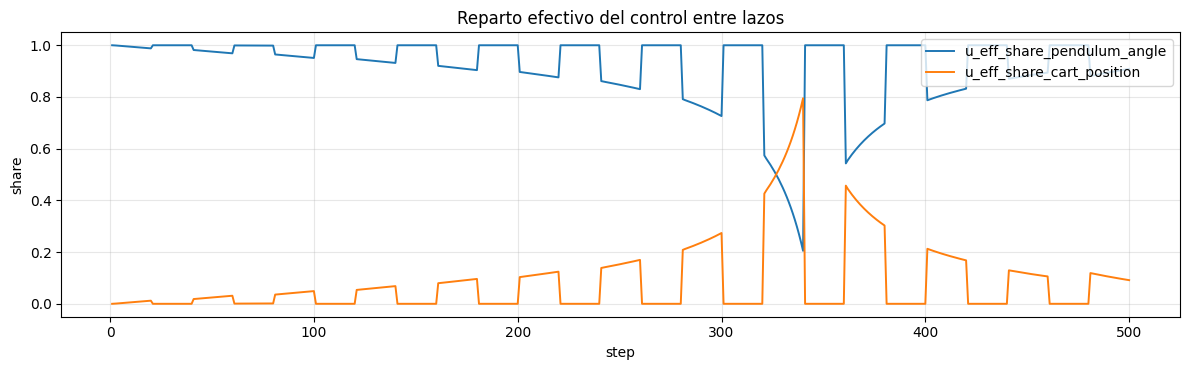

In [83]:
# --- CONFIGURACIÓN CELDA ---
T_START = 0
T_END = min(len(controller_sc_df) - 1, 500)

plot_df = controller_sc_df.loc[T_START:T_END].copy()

fig, ax = plt.subplots(figsize=(12, 3.8))

for var_name in controller_loop_vars:
    ax.plot(
        plot_df.index,
        plot_df[f'u_eff_share_{var_name}'],
        label=f'u_eff_share_{var_name}',
        linewidth=1.4
    )

ax.set_xlabel('step')
ax.set_ylabel('share')
ax.set_title('Reparto efectivo del control entre lazos')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Qué valida**

- qué lazo domina realmente;
- si un lazo desaparece operativamente;
- y si el reparto cambia bruscamente por saturación o por evolución del episodio.

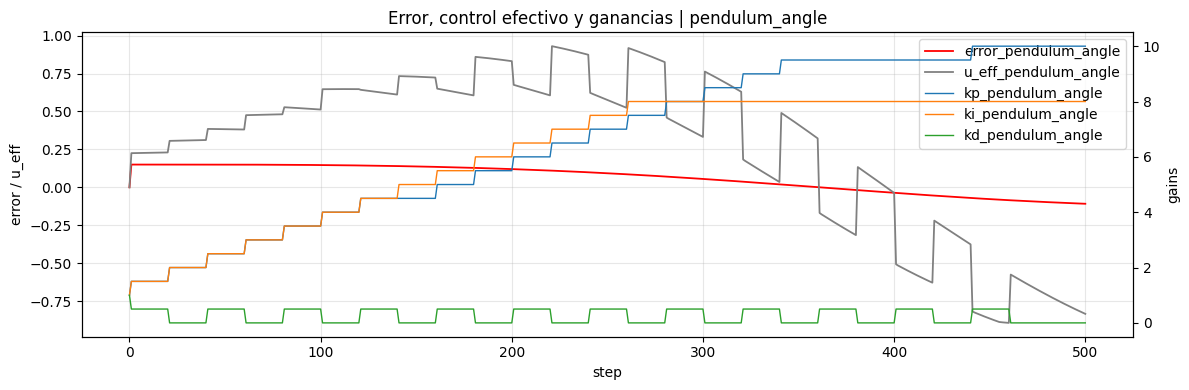

In [85]:
# --- CONFIGURACIÓN CELDA ---
VAR_NAME = controller_loop_vars[0]
T_START = 0
T_END = min(len(controller_sc_df) - 1, 500)

error_col = f'error_{VAR_NAME}'
u_eff_col = f'u_eff_{VAR_NAME}'
kp_col = f'kp_{VAR_NAME}'
ki_col = f'ki_{VAR_NAME}'
kd_col = f'kd_{VAR_NAME}'

plot_df = controller_sc_df.loc[T_START:T_END].copy()

fig, ax1 = plt.subplots(figsize=(12, 4.0))

ax1.plot(plot_df.index, plot_df[error_col], color='r' , label=error_col, linewidth=1.3)
ax1.plot(plot_df.index, plot_df[u_eff_col], color='gray' ,label=u_eff_col, linewidth=1.3)
ax1.set_xlabel('step')
ax1.set_ylabel('error / u_eff')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(plot_df.index, plot_df[kp_col], label=kp_col, linewidth=1.0)
ax2.plot(plot_df.index, plot_df[ki_col], label=ki_col, linewidth=1.0)
ax2.plot(plot_df.index, plot_df[kd_col], label=kd_col, linewidth=1.0)
ax2.set_ylabel('gains')

ax1.set_title(f'Error, control efectivo y ganancias | {VAR_NAME}')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

**Qué valida**

- si cambios de ganancia están acompañados por cambios legibles en error y acción efectiva;
- si el controlador responde de forma coherente o errática;
- y si las ganancias evolucionan sin efecto aparente.

In [86]:
controller_interval_view_cols = [
    'interval_id',
    'sat_prp_interval_ctrl',
    'u_total_raw_mean_abs_ctrl',
    'u_total_saturated_mean_abs_ctrl',
    'u_total_sat_gap_mean_abs_ctrl',
]

for var_name in controller_loop_vars:
    controller_interval_view_cols.extend([
        f'error_mean_abs_{var_name}_ctrl',
        f'control_action_mean_abs_{var_name}_ctrl',
        f'u_eff_mean_abs_{var_name}_ctrl',
        f'u_eff_loss_mean_abs_{var_name}_ctrl',
        f'control_share_mean_{var_name}_ctrl',
        f'u_eff_share_mean_{var_name}_ctrl',
    ])

controller_interval_view_df = controller_interval_df[controller_interval_view_cols].copy()
controller_interval_view_df

,interval_id,sat_prp_interval_ctrl,u_total_raw_mean_abs_ctrl,u_total_saturated_mean_abs_ctrl,u_total_sat_gap_mean_abs_ctrl,error_mean_abs_pendulum_angle_ctrl,control_action_mean_abs_pendulum_angle_ctrl,u_eff_mean_abs_pendulum_angle_ctrl,u_eff_loss_mean_abs_pendulum_angle_ctrl,control_share_mean_pendulum_angle_ctrl,u_eff_share_mean_pendulum_angle_ctrl,error_mean_abs_cart_position_ctrl,control_action_mean_abs_cart_position_ctrl,u_eff_mean_abs_cart_position_ctrl,u_eff_loss_mean_abs_cart_position_ctrl,control_share_mean_cart_position_ctrl,u_eff_share_mean_cart_position_ctrl
0,0,0.0,0.214782,0.214782,0.0,0.142430,0.216001,0.216001,0.0,0.994421,0.994421,0.000016,0.001219,0.001219,0.0,0.005579,0.005579
1,1,0.0,0.304733,0.304733,0.0,0.149914,0.304873,0.304873,0.0,0.999399,0.999399,0.000133,0.000140,0.000140,0.0,0.000601,0.000601
2,2,0.0,0.370508,0.370508,0.0,0.149697,0.379627,0.379627,0.0,0.976789,0.976789,0.000418,0.009119,0.009119,0.0,0.023211,0.023211
3,3,0.0,0.472621,0.472621,0.0,0.149055,0.473677,0.473677,0.0,0.997518,0.997518,0.000918,0.001056,0.001056,0.0,0.002482,0.002482
4,4,0.0,0.497288,0.497288,0.0,0.147729,0.518998,0.518998,0.0,0.960054,0.960054,0.001686,0.021710,0.021710,0.0,0.039946,0.039946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,243,0.0,0.007112,0.007112,0.0,0.000246,0.002173,0.002173,0.0,0.953073,0.953073,0.021682,0.005683,0.005683,0.0,0.046927,0.046927
244,244,0.0,0.020791,0.020791,0.0,0.000536,0.011354,0.011354,0.0,0.565200,0.565200,0.021280,0.009437,0.009437,0.0,0.434800,0.434800
245,245,0.0,0.008257,0.008257,0.0,0.000781,0.007769,0.007769,0.0,0.977888,0.977888,0.020889,0.000488,0.000488,0.0,0.022112,0.022112
246,246,0.0,0.023100,0.023100,0.0,0.000991,0.014117,0.014117,0.0,0.623491,0.623491,0.020505,0.008983,0.008983,0.0,0.376509,0.376509


#### Gráficos específicos

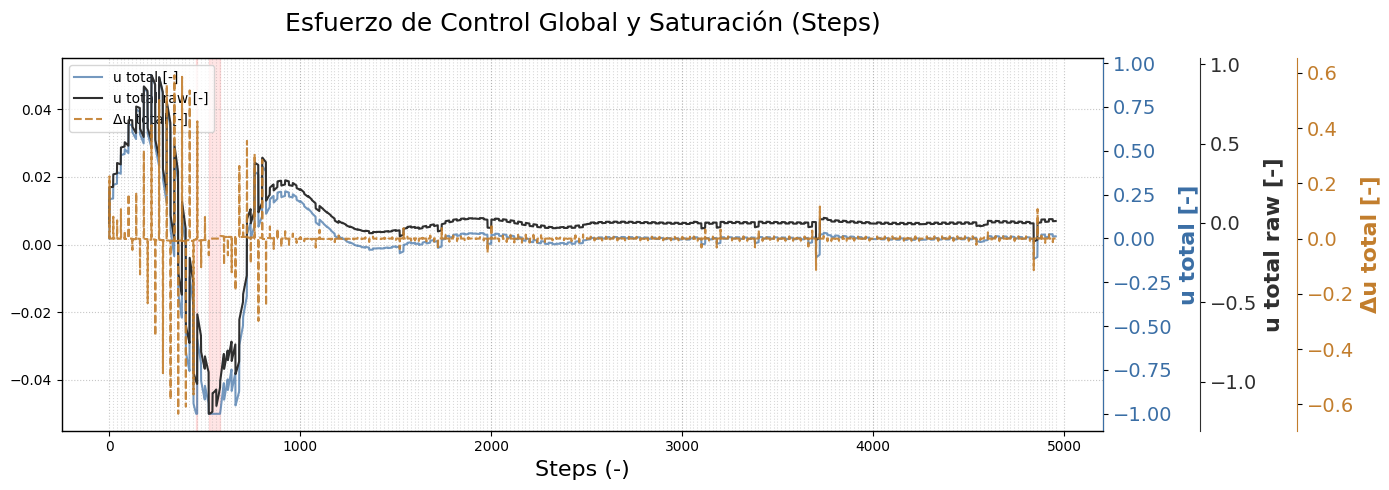

In [87]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['u_total_saturated', 'u_total', 'u_total_raw', 'delta_u_total']

col_names = ['u saturada [-]', 'u total [-]', 'u total raw [-]', 'Δu total [-]']

colors = ['#5A8FC4', '#3A6EA5', '#2F2F2F', '#C27D2C']
styles = ['--', '-', '-', '--']
alphas  = [1.0, 0.7, 1.0, 0.9]
title  = "Esfuerzo de Control Global y Saturación (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

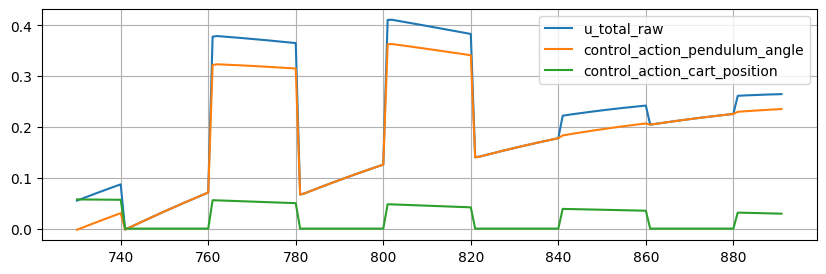

In [88]:
step_df.loc[730:891, 'u_total_raw'].plot()
step_df.loc[730:891, 'control_action_pendulum_angle'].plot()
step_df.loc[730:891, 'control_action_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()

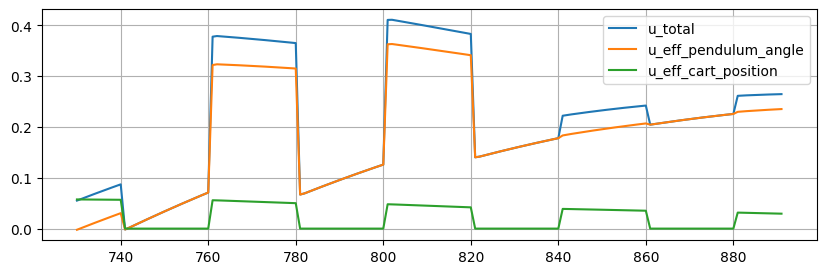

In [89]:
step_df.loc[730:891, 'u_total'].plot()
step_df.loc[730:891, 'u_eff_pendulum_angle'].plot()
step_df.loc[730:891, 'u_eff_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()

#### Prueba de evaluación más específica


--- EVENT @ step 1 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
0,0.157000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000
1,0.157000,0.000062,0.149924,0.000000,0.000150,1.5,1.5,0.5,0.225110,0.225110,0.225110,0.225110
2,0.157000,0.000122,0.149924,0.000029,0.000300,1.5,1.5,0.5,0.225350,0.000240,0.225350,0.000240
3,0.157000,0.000181,0.149924,0.000088,0.000450,1.5,1.5,0.5,0.225604,0.000254,0.225604,0.000254
4,0.157000,0.000240,0.149924,0.000145,0.000600,1.5,1.5,0.5,0.225858,0.000254,0.225858,0.000254
5,0.157001,0.000298,0.149924,0.000201,0.000750,1.5,1.5,0.5,0.226111,0.000253,0.226111,0.000253
6,0.157001,0.000355,0.149924,0.000257,0.000900,1.5,1.5,0.5,0.226364,0.000253,0.226364,0.000253
7,0.157001,0.000411,0.149925,0.000312,0.001049,1.5,1.5,0.5,0.226617,0.000253,0.226617,0.000253
8,0.157002,0.000467,0.149925,0.000366,0.001199,1.5,1.5,0.5,0.226869,0.000252,0.226869,0.000252
9,0.157002,0.000521,0.149925,0.000419,0.001349,1.5,1.5,0.5,0.227122,0.000252,0.227122,0.000252


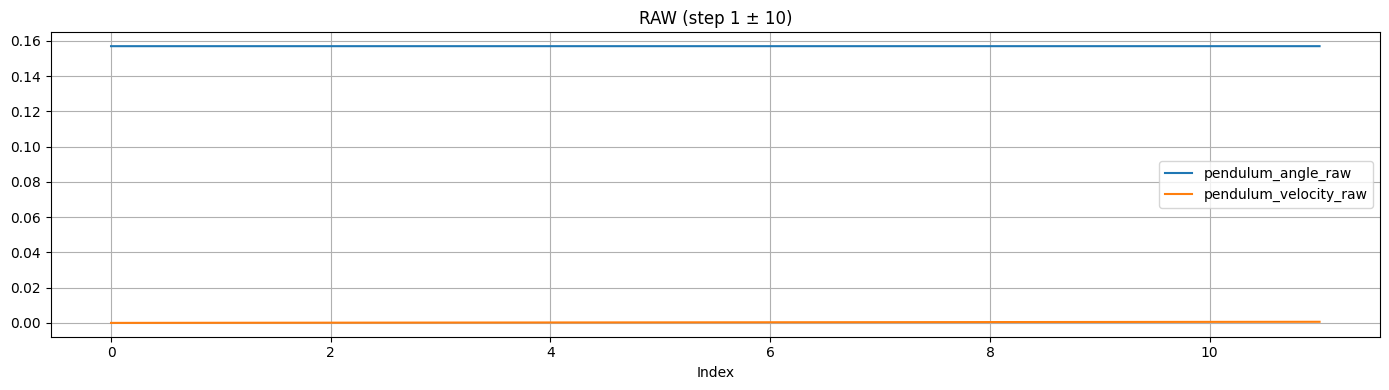

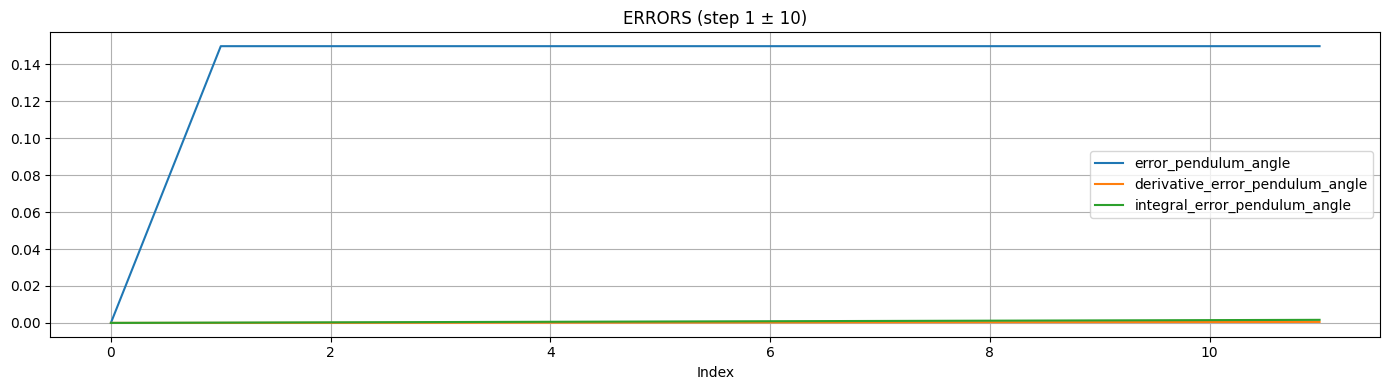

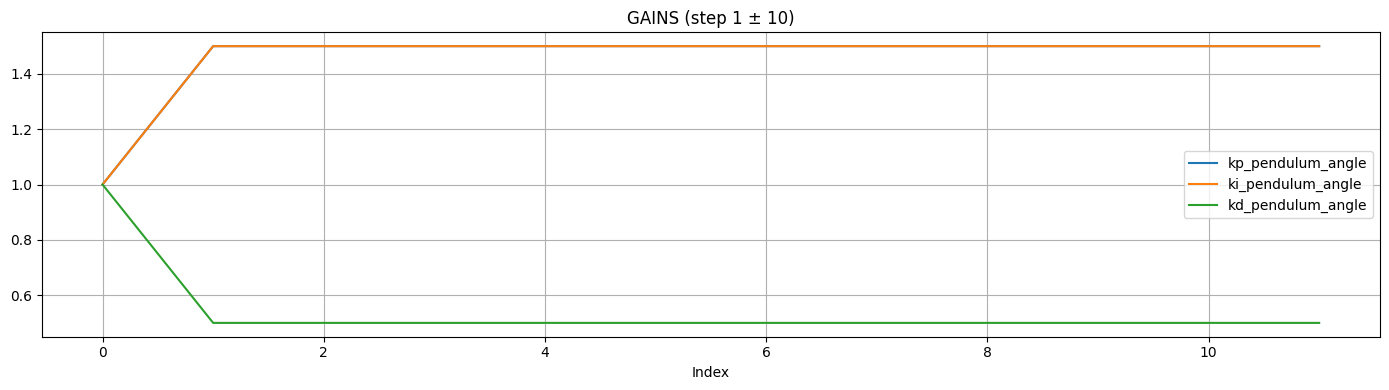

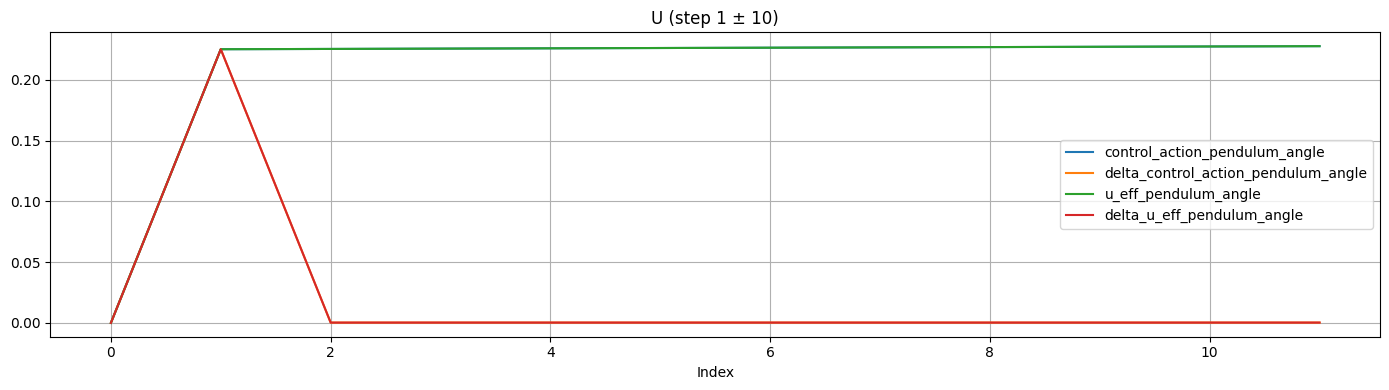


--- EVENT @ step 101 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
91,0.154505,-0.095474,0.147631,-0.088149,0.013599,3.5,3.5,0.5,0.520231,-0.000804,0.520231,-0.000804
92,0.154408,-0.097573,0.147541,-0.090165,0.013746,3.5,3.5,0.5,0.519423,-0.000807,0.519423,-0.000807
93,0.154310,-0.099664,0.147449,-0.092173,0.013894,3.5,3.5,0.5,0.518613,-0.000811,0.518613,-0.000811
94,0.154209,-0.101746,0.147355,-0.094173,0.014041,3.5,3.5,0.5,0.517799,-0.000814,0.517799,-0.000814
95,0.154106,-0.103821,0.147258,-0.096166,0.014188,3.5,3.5,0.5,0.516981,-0.000818,0.516981,-0.000818
96,0.154001,-0.105888,0.147160,-0.098151,0.014336,3.5,3.5,0.5,0.516160,-0.000821,0.516160,-0.000821
97,0.153894,-0.107947,0.147060,-0.100129,0.014483,3.5,3.5,0.5,0.515336,-0.000824,0.515336,-0.000824
98,0.153786,-0.109998,0.146958,-0.102099,0.014630,3.5,3.5,0.5,0.514508,-0.000828,0.514508,-0.000828
99,0.153674,-0.112040,0.146854,-0.104061,0.014777,3.5,3.5,0.5,0.513676,-0.000831,0.513676,-0.000831
100,0.153561,-0.114075,0.146748,-0.106016,0.014923,3.5,3.5,0.5,0.512842,-0.000835,0.512842,-0.000835


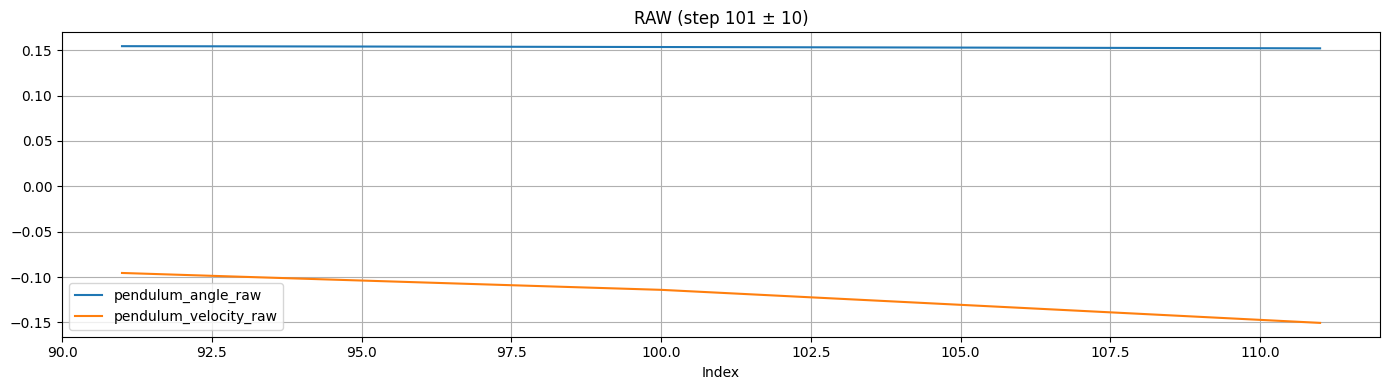

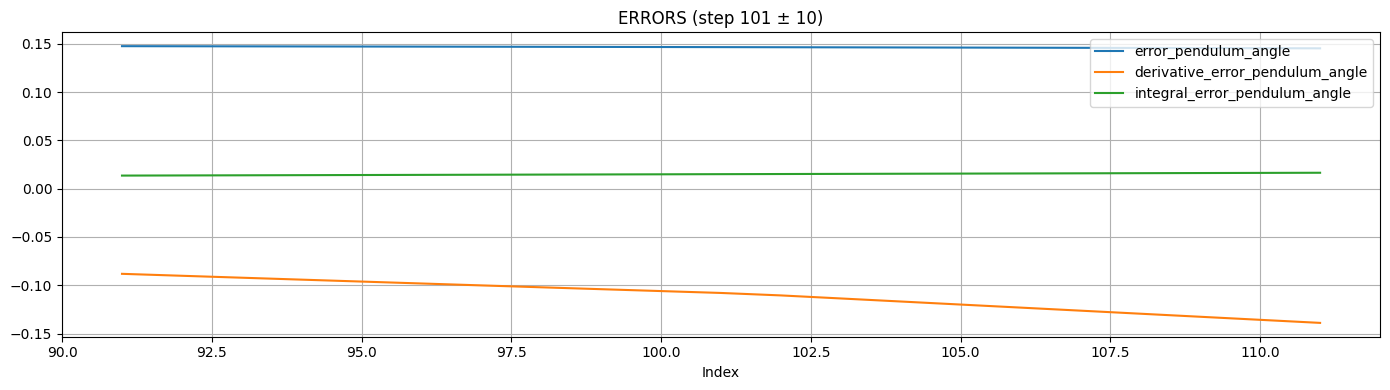

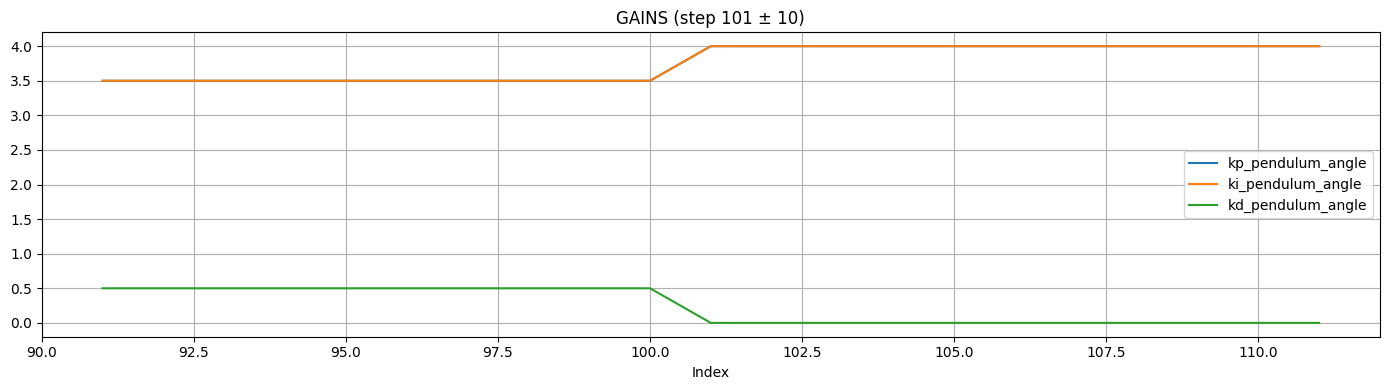

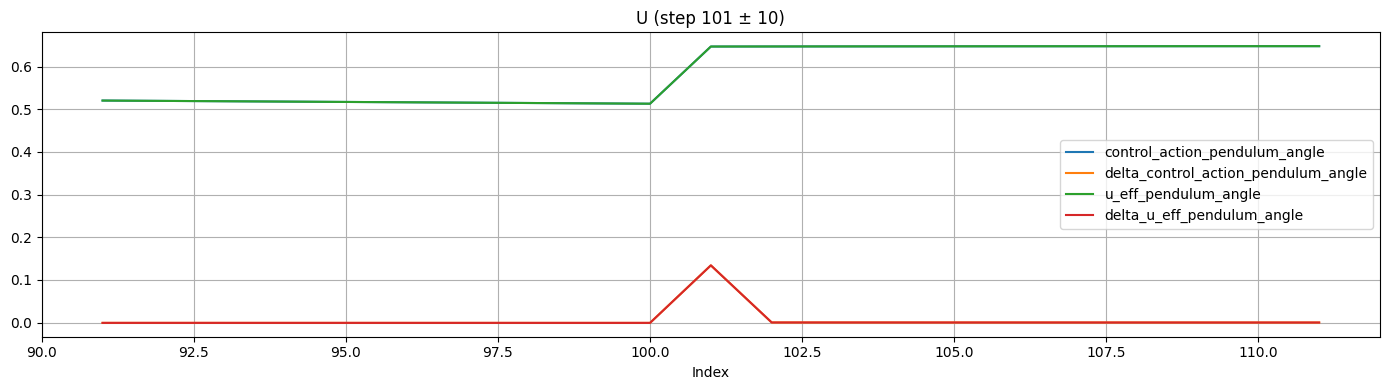


--- EVENT @ step 181 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
171,0.137146,-0.352155,0.131299,-0.332163,0.024882,5.0,5.5,0.5,0.627268,-0.002322,0.627268,-0.002322
172,0.136792,-0.355008,0.130964,-0.334913,0.025013,5.0,5.5,0.5,0.624938,-0.002329,0.624938,-0.002329
173,0.136436,-0.357844,0.130627,-0.337646,0.025144,5.0,5.5,0.5,0.622602,-0.002336,0.622602,-0.002336
174,0.136077,-0.360663,0.130286,-0.340363,0.025274,5.0,5.5,0.5,0.620259,-0.002344,0.620259,-0.002344
175,0.135715,-0.363464,0.129943,-0.343062,0.025404,5.0,5.5,0.5,0.617908,-0.002351,0.617908,-0.002351
176,0.135350,-0.366248,0.129598,-0.345746,0.025534,5.0,5.5,0.5,0.615550,-0.002358,0.615550,-0.002358
177,0.134982,-0.369015,0.129249,-0.348413,0.025663,5.0,5.5,0.5,0.613186,-0.002365,0.613186,-0.002365
178,0.134612,-0.371764,0.128898,-0.351063,0.025792,5.0,5.5,0.5,0.610814,-0.002371,0.610814,-0.002371
179,0.134239,-0.374496,0.128544,-0.353696,0.025920,5.0,5.5,0.5,0.608436,-0.002378,0.608436,-0.002378
180,0.133863,-0.377210,0.128188,-0.356313,0.026049,5.0,5.5,0.5,0.606051,-0.002385,0.606051,-0.002385


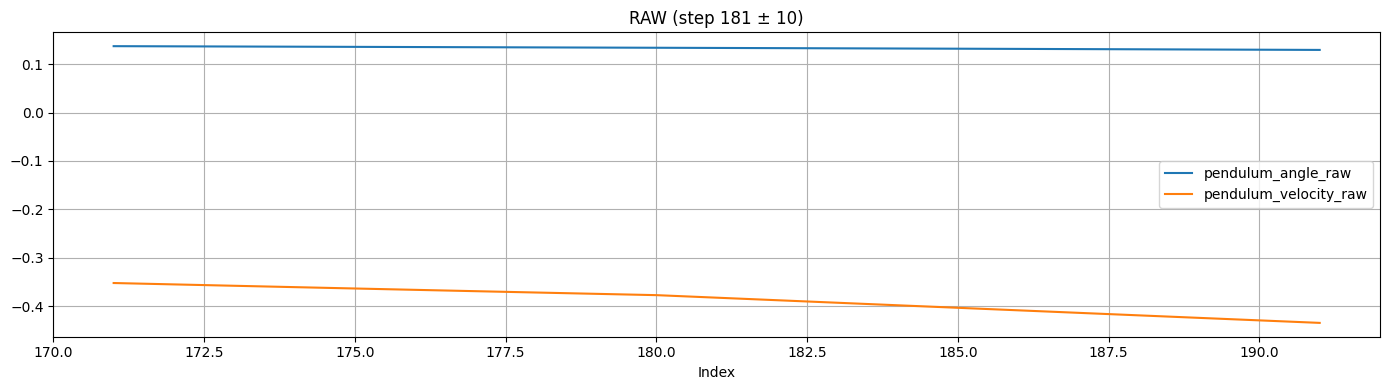

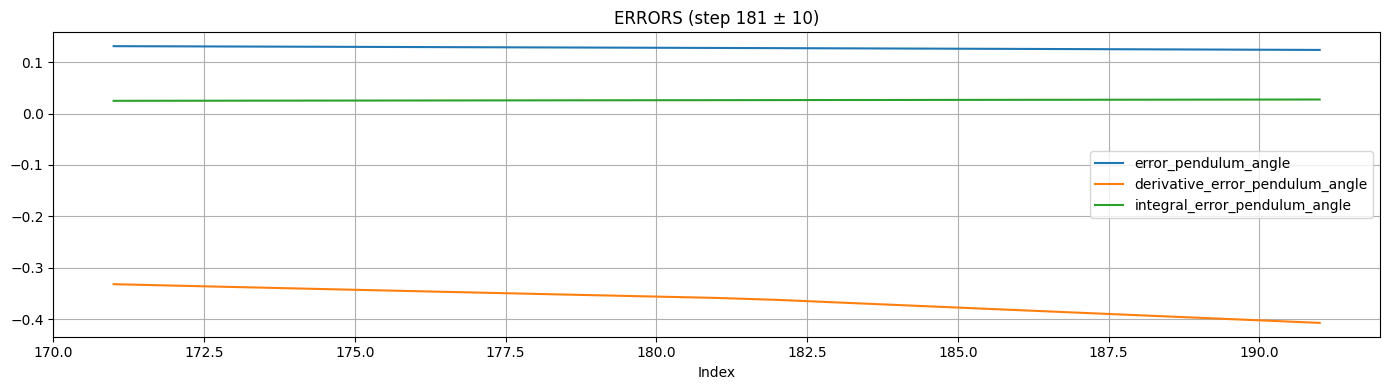

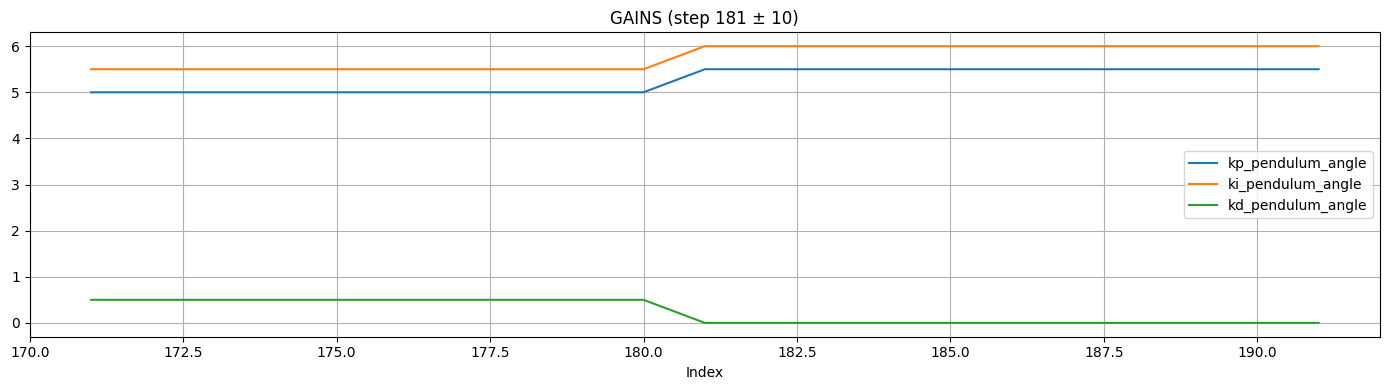

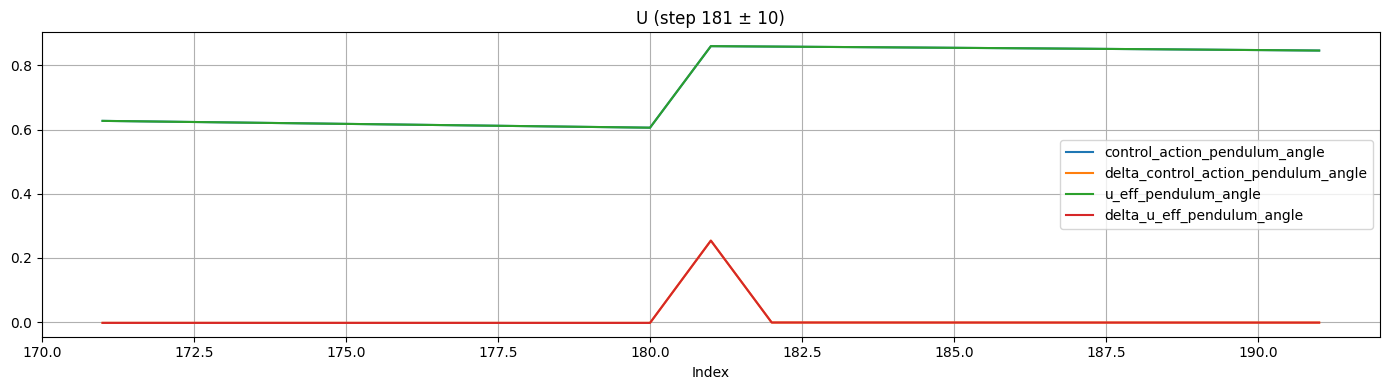


--- EVENT @ step 261 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
251,0.095600,-0.689718,0.091948,-0.654901,0.033971,7.0,7.5,0.5,0.570971,-0.005159,0.570971,-0.005159
252,0.094909,-0.692276,0.091291,-0.657395,0.034062,7.0,7.5,0.5,0.565807,-0.005164,0.565807,-0.005164
253,0.094215,-0.694799,0.090631,-0.659855,0.034153,7.0,7.5,0.5,0.560638,-0.005169,0.560638,-0.005169
254,0.093519,-0.697286,0.089969,-0.662281,0.034243,7.0,7.5,0.5,0.555464,-0.005174,0.555464,-0.005174
255,0.092821,-0.699737,0.089304,-0.664673,0.034332,7.0,7.5,0.5,0.550285,-0.005179,0.550285,-0.005179
256,0.092120,-0.702154,0.088637,-0.667031,0.034421,7.0,7.5,0.5,0.545102,-0.005184,0.545102,-0.005184
257,0.091417,-0.704535,0.087968,-0.669355,0.034509,7.0,7.5,0.5,0.539914,-0.005188,0.539914,-0.005188
258,0.090711,-0.706880,0.087296,-0.671646,0.034596,7.0,7.5,0.5,0.534722,-0.005192,0.534722,-0.005192
259,0.090003,-0.709190,0.086622,-0.673902,0.034683,7.0,7.5,0.5,0.529526,-0.005196,0.529526,-0.005196
260,0.089292,-0.711465,0.085946,-0.676125,0.034769,7.0,7.5,0.5,0.524326,-0.005200,0.524326,-0.005200


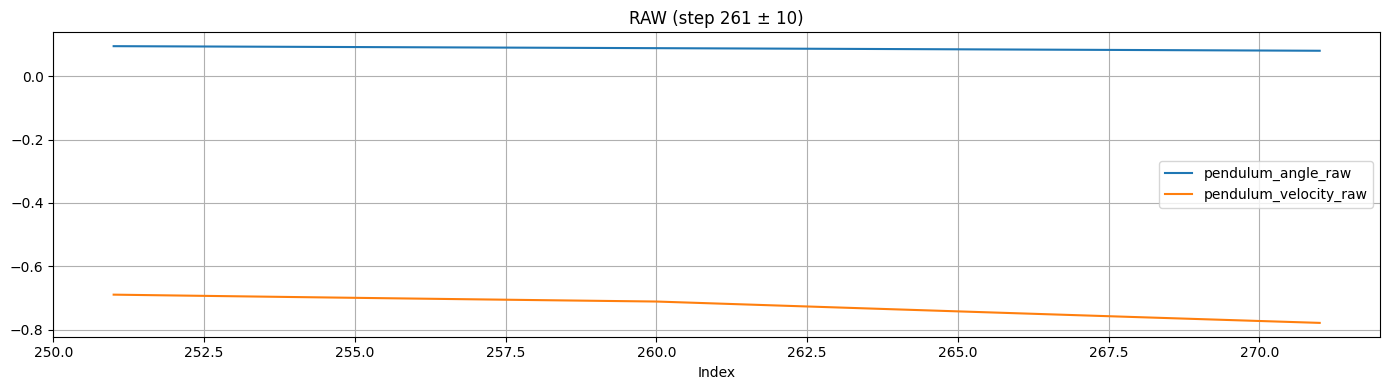

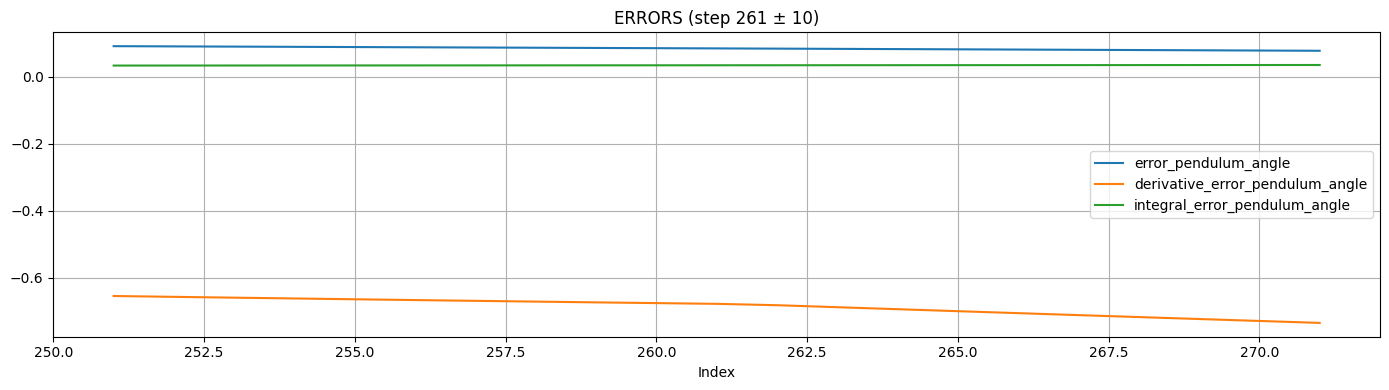

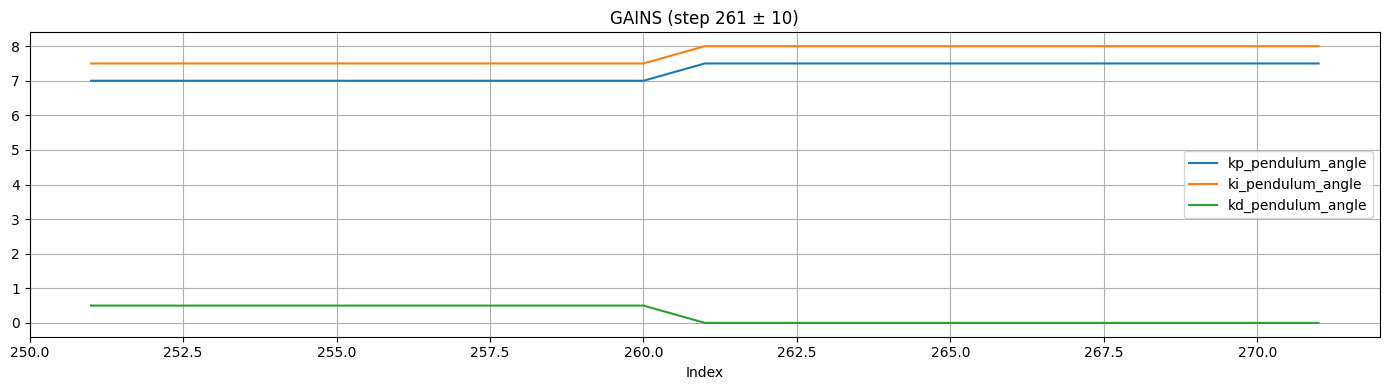

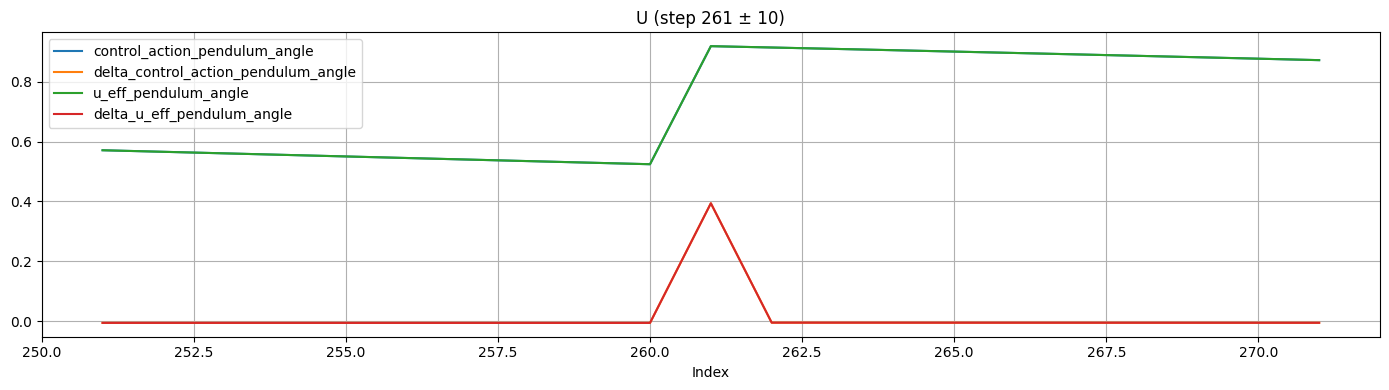


--- EVENT @ step 341 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
331,0.028126,-0.956399,0.027772,-0.914117,0.038876,9.0,8.0,0.5,0.103893,-0.007758,0.103893,-0.007758
332,0.027170,-0.955756,0.026858,-0.913575,0.038902,9.0,8.0,0.5,0.096157,-0.007737,0.096157,-0.007737
333,0.026214,-0.955063,0.025945,-0.912986,0.038928,9.0,8.0,0.5,0.088442,-0.007714,0.088442,-0.007714
334,0.025260,-0.954320,0.025033,-0.912348,0.038953,9.0,8.0,0.5,0.080750,-0.007692,0.080750,-0.007692
335,0.024306,-0.953526,0.024121,-0.911662,0.038978,9.0,8.0,0.5,0.073081,-0.007669,0.073081,-0.007669
336,0.023353,-0.952683,0.023210,-0.910928,0.039001,9.0,8.0,0.5,0.065436,-0.007646,0.065436,-0.007646
337,0.022401,-0.951791,0.022300,-0.910147,0.039023,9.0,8.0,0.5,0.057813,-0.007622,0.057813,-0.007622
338,0.021449,-0.950849,0.021391,-0.909318,0.039045,9.0,8.0,0.5,0.050215,-0.007598,0.050215,-0.007598
339,0.020499,-0.949859,0.020482,-0.908442,0.039065,9.0,8.0,0.5,0.042641,-0.007574,0.042641,-0.007574
340,0.019550,-0.948819,0.019575,-0.907519,0.039085,9.0,8.0,0.5,0.035091,-0.007550,0.035091,-0.007550


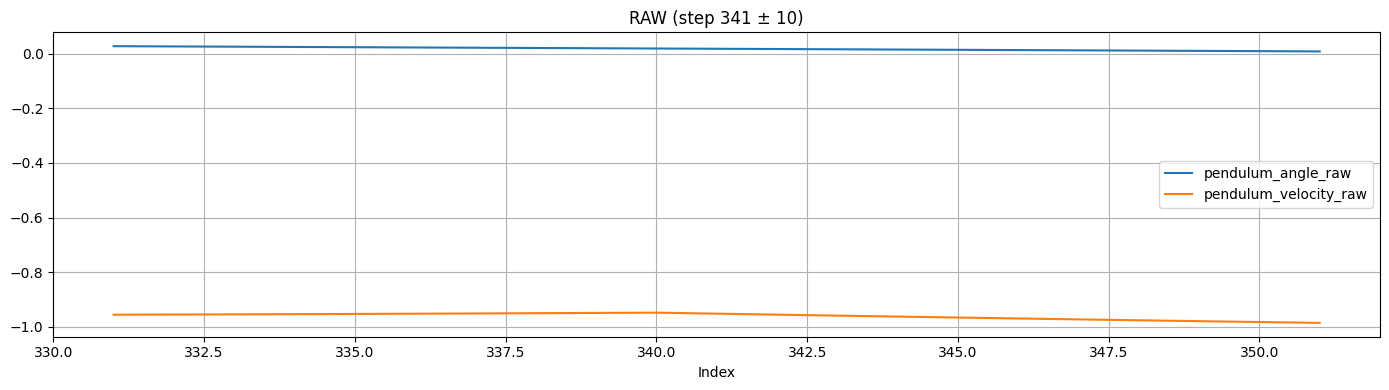

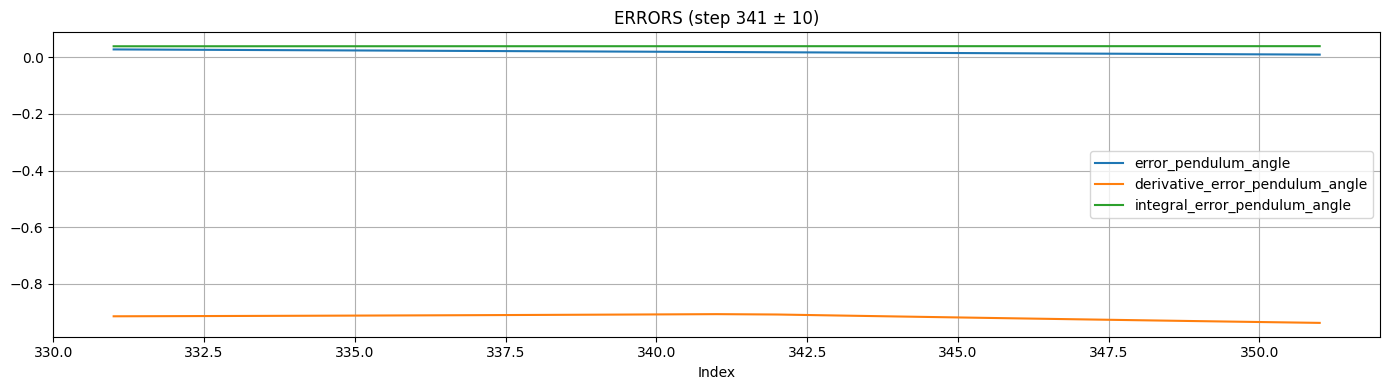

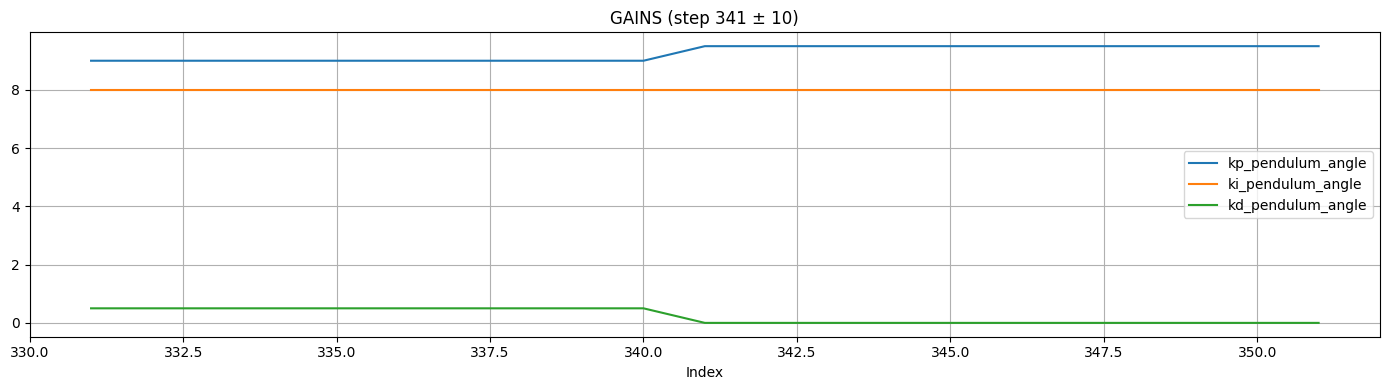

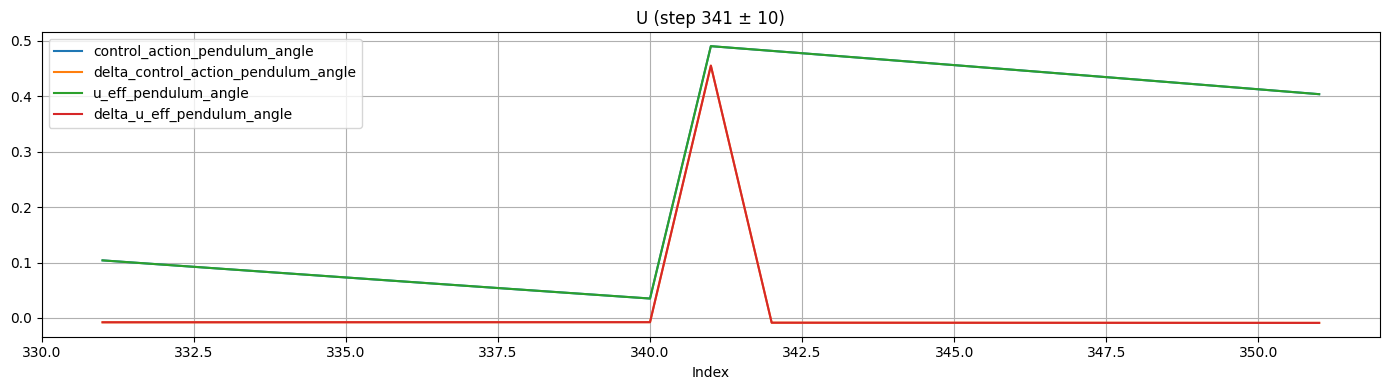


--- EVENT @ step 421 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
411,-0.049358,-0.913416,-0.046258,-0.879496,0.038088,9.5,8.0,0.5,-0.574497,-0.006327,-0.574497,-0.006327
412,-0.050268,-0.908305,-0.047133,-0.874665,0.038041,9.5,8.0,0.5,-0.580767,-0.006271,-0.580767,-0.006271
413,-0.051174,-0.903159,-0.048003,-0.869801,0.037993,9.5,8.0,0.5,-0.586982,-0.006215,-0.586982,-0.006215
414,-0.052075,-0.897980,-0.048868,-0.864903,0.037944,9.5,8.0,0.5,-0.593141,-0.006159,-0.593141,-0.006159
415,-0.052970,-0.892767,-0.049728,-0.859973,0.037894,9.5,8.0,0.5,-0.599244,-0.006103,-0.599244,-0.006103
416,-0.053860,-0.887521,-0.050583,-0.855012,0.037844,9.5,8.0,0.5,-0.605290,-0.006046,-0.605290,-0.006046
417,-0.054745,-0.882243,-0.051433,-0.850018,0.037792,9.5,8.0,0.5,-0.611280,-0.005990,-0.611280,-0.005990
418,-0.055625,-0.876933,-0.052278,-0.844993,0.037740,9.5,8.0,0.5,-0.617213,-0.005933,-0.617213,-0.005933
419,-0.056499,-0.871591,-0.053118,-0.839938,0.037687,9.5,8.0,0.5,-0.623090,-0.005877,-0.623090,-0.005877
420,-0.057368,-0.866219,-0.053952,-0.834852,0.037633,9.5,8.0,0.5,-0.628910,-0.005820,-0.628910,-0.005820


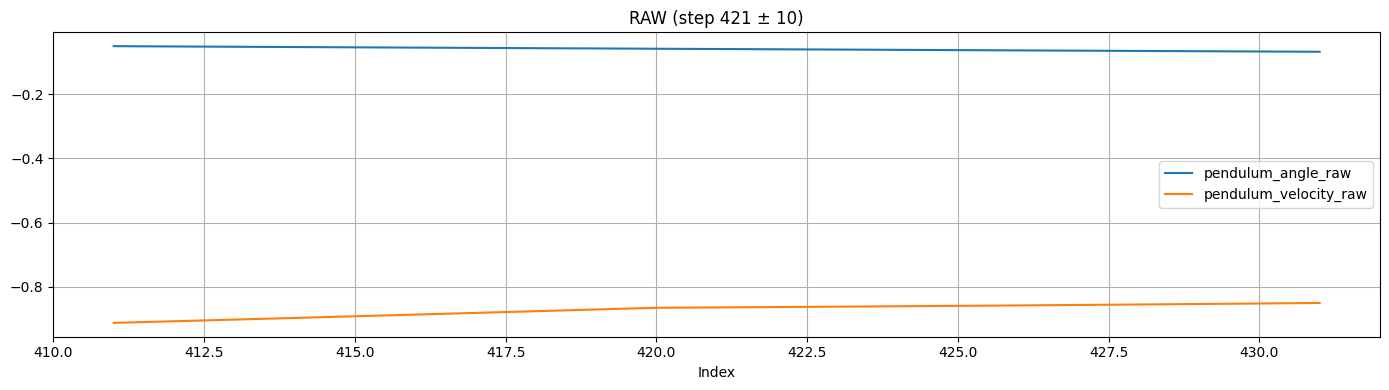

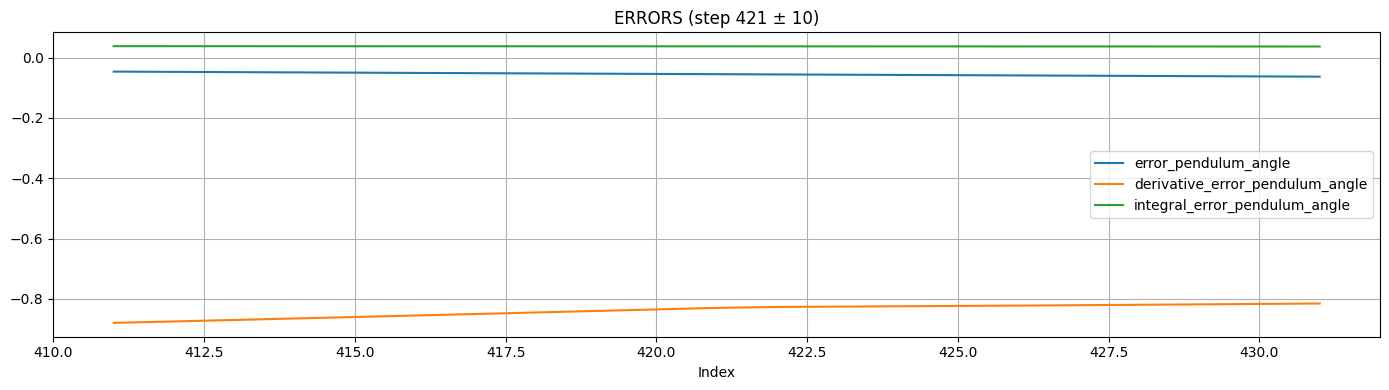

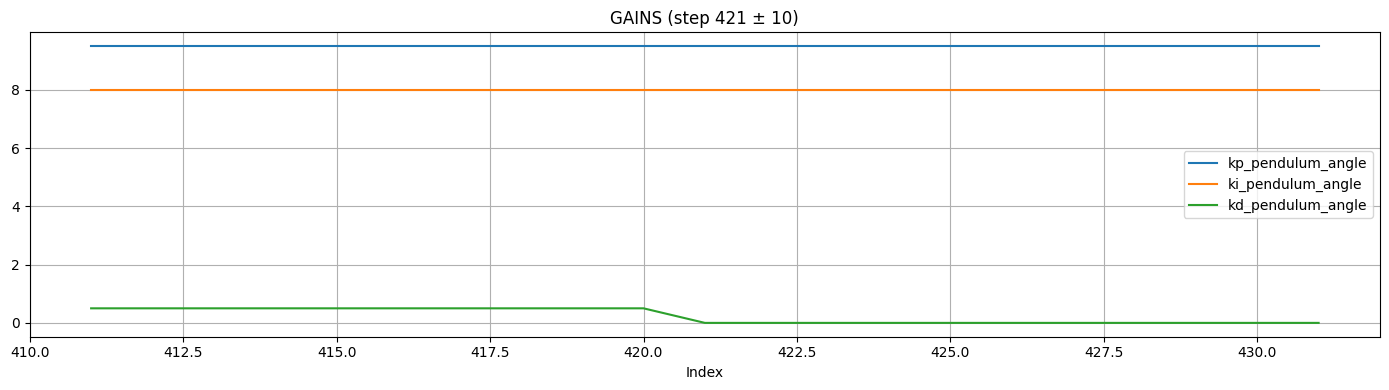

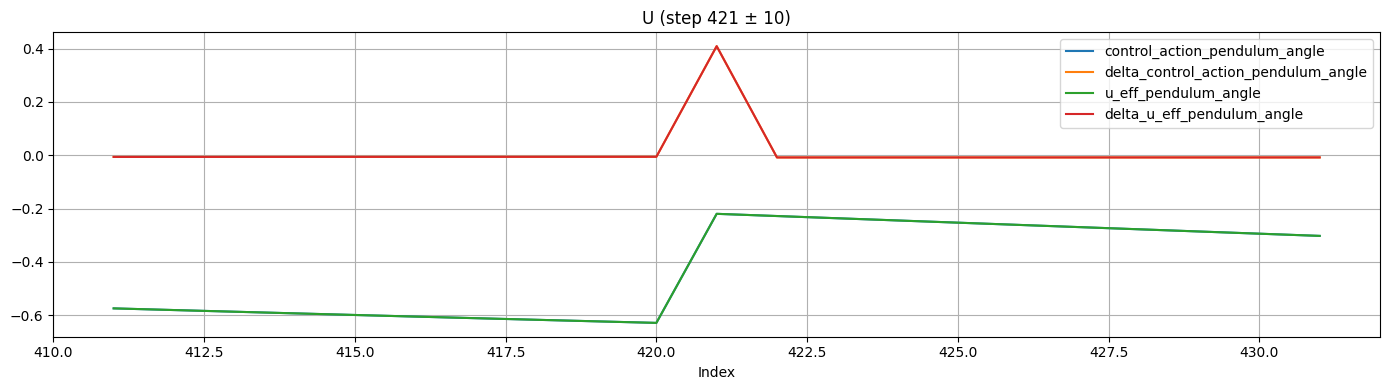


--- EVENT @ step 521 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
511,-0.119384,-0.444472,-0.113576,-0.432579,0.030108,10.0,8.0,0.0,-0.894898,-0.005234,-0.894898,-0.005234
512,-0.119826,-0.438739,-0.114003,-0.427155,0.029994,10.0,8.0,0.0,-0.900081,-0.005184,-0.900081,-0.005184
513,-0.120261,-0.432971,-0.114425,-0.421697,0.029879,10.0,8.0,0.0,-0.905213,-0.005132,-0.905213,-0.005132
514,-0.120691,-0.427169,-0.114841,-0.416206,0.029764,10.0,8.0,0.0,-0.910294,-0.005081,-0.910294,-0.005081
515,-0.121116,-0.421332,-0.115252,-0.410682,0.029649,10.0,8.0,0.0,-0.915323,-0.005029,-0.915323,-0.005029
516,-0.121534,-0.415462,-0.115657,-0.405125,0.029533,10.0,8.0,0.0,-0.920300,-0.004976,-0.920300,-0.004976
517,-0.121947,-0.409558,-0.116056,-0.399535,0.029417,10.0,8.0,0.0,-0.925223,-0.004924,-0.925223,-0.004924
518,-0.122353,-0.403620,-0.116450,-0.393913,0.029301,10.0,8.0,0.0,-0.930094,-0.004871,-0.930094,-0.004871
519,-0.122754,-0.397650,-0.116838,-0.388259,0.029184,10.0,8.0,0.0,-0.934911,-0.004817,-0.934911,-0.004817
520,-0.123148,-0.391648,-0.117221,-0.382574,0.029067,10.0,8.0,0.0,-0.939675,-0.004764,-0.939675,-0.004764


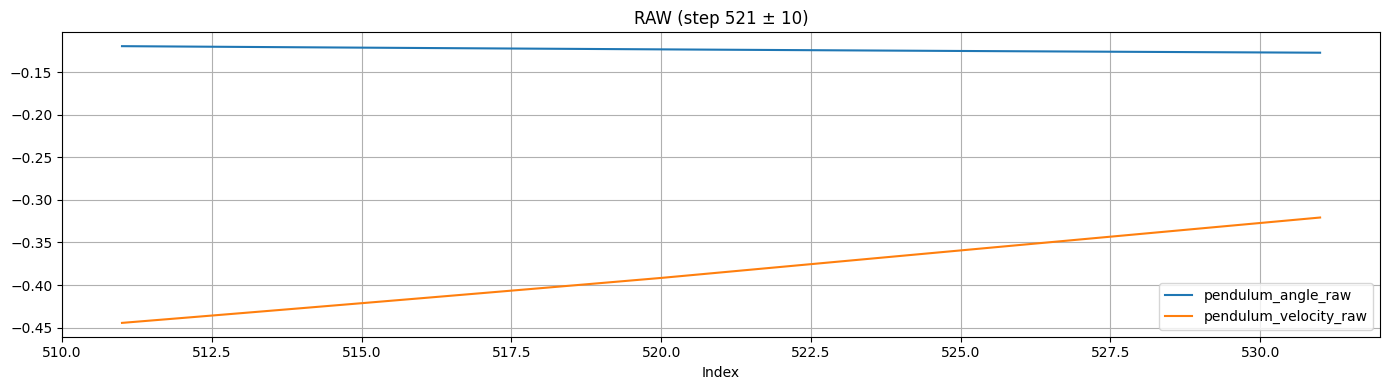

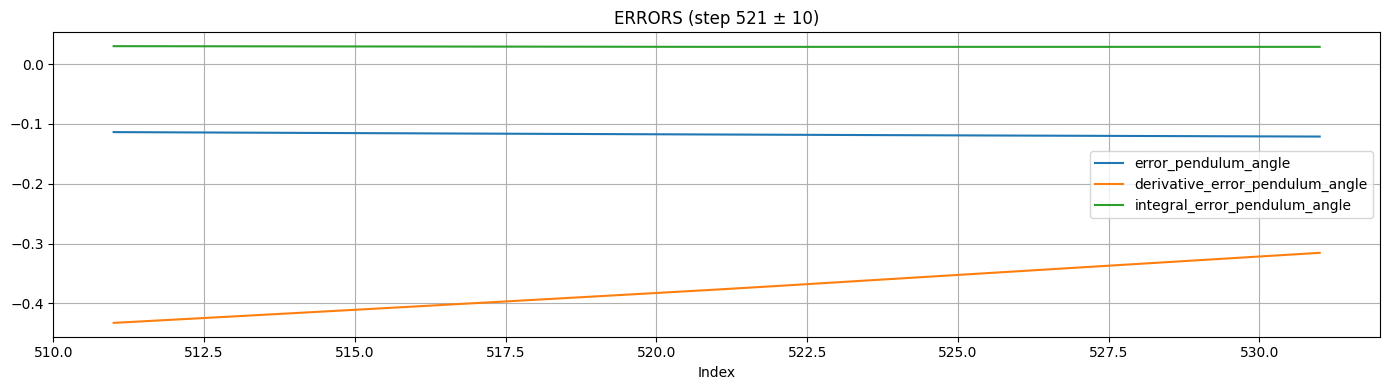

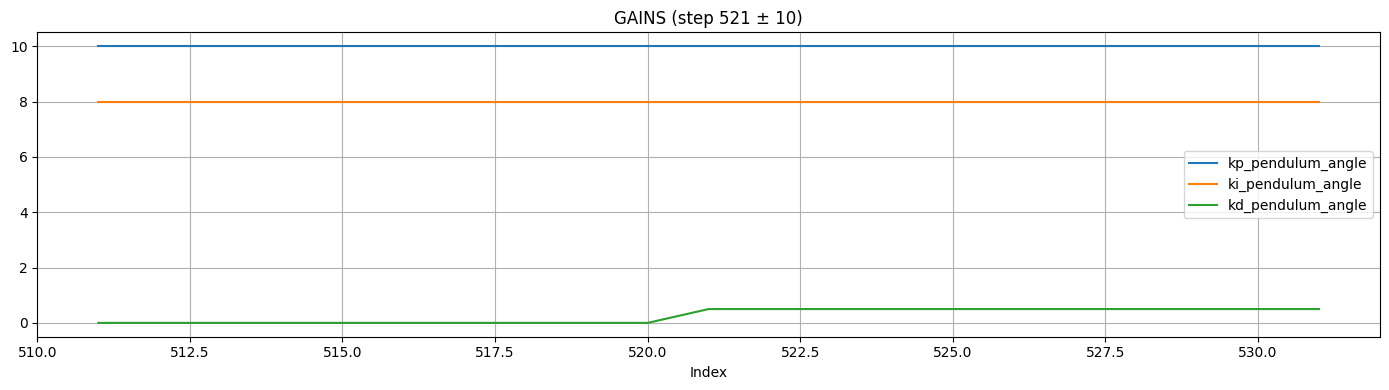

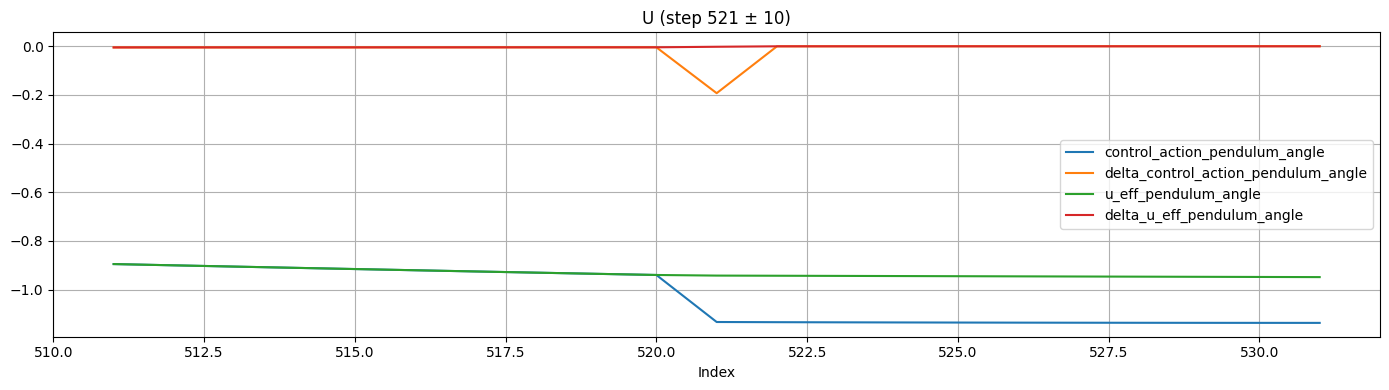


--- EVENT @ step 641 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
631,-0.128418,0.263577,-0.122880,0.244731,0.022602,10.0,8.0,1.0,-0.803254,0.006160,-0.803254,0.006160
632,-0.128153,0.268382,-0.122630,0.249384,0.022479,10.0,8.0,1.0,-0.797088,0.006166,-0.797088,0.006166
633,-0.127882,0.273141,-0.122376,0.253993,0.022357,10.0,8.0,1.0,-0.790918,0.006170,-0.790918,0.006170
634,-0.127606,0.277854,-0.122118,0.258559,0.022234,10.0,8.0,1.0,-0.784743,0.006175,-0.784743,0.006175
635,-0.127326,0.282523,-0.121855,0.263082,0.022113,10.0,8.0,1.0,-0.778564,0.006179,-0.778564,0.006179
636,-0.127041,0.287146,-0.121587,0.267562,0.021991,10.0,8.0,1.0,-0.772381,0.006183,-0.772381,0.006183
637,-0.126752,0.291724,-0.121315,0.271998,0.021870,10.0,8.0,1.0,-0.766195,0.006186,-0.766195,0.006186
638,-0.126458,0.296256,-0.121039,0.276392,0.021749,10.0,8.0,1.0,-0.760007,0.006189,-0.760007,0.006189
639,-0.126159,0.300744,-0.120758,0.280742,0.021628,10.0,8.0,1.0,-0.753815,0.006191,-0.753815,0.006191
640,-0.125856,0.305186,-0.120473,0.285048,0.021507,10.0,8.0,1.0,-0.747622,0.006194,-0.747622,0.006194


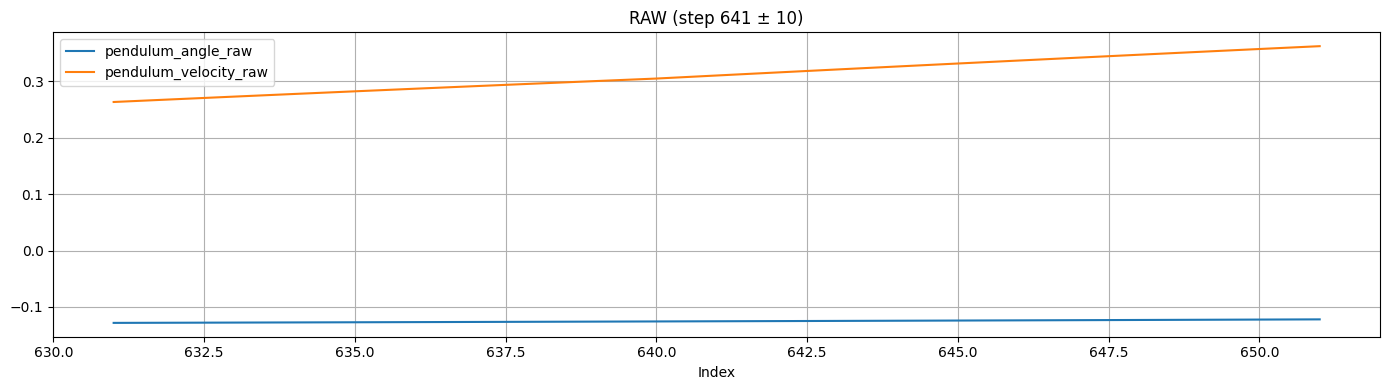

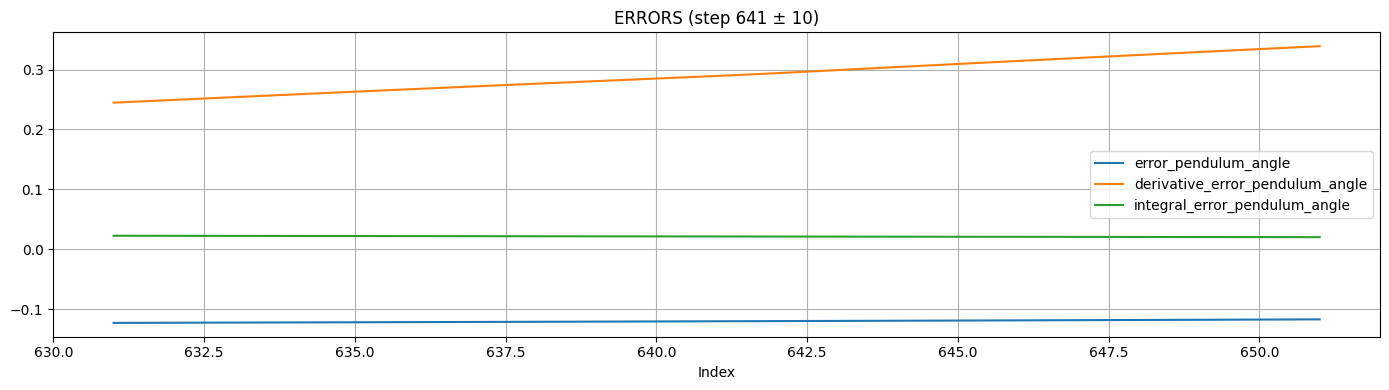

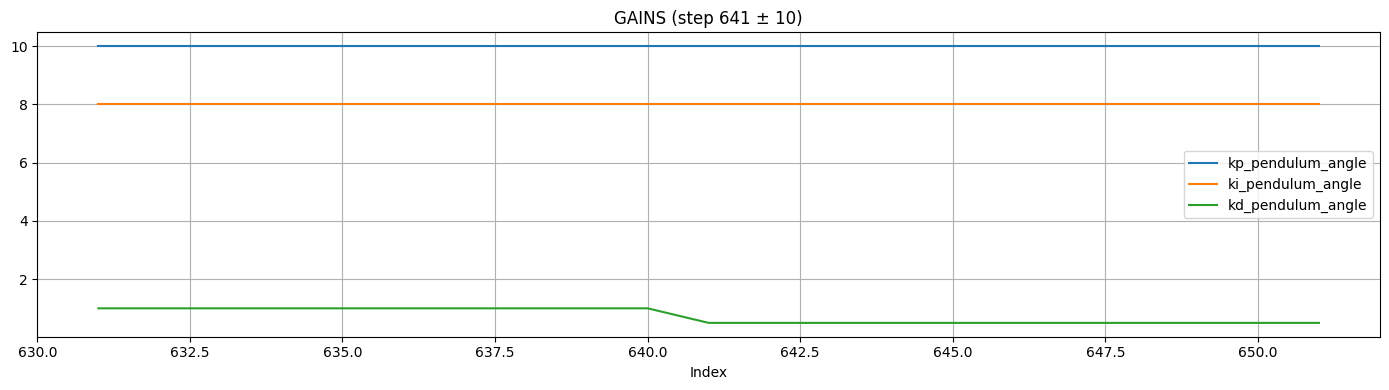

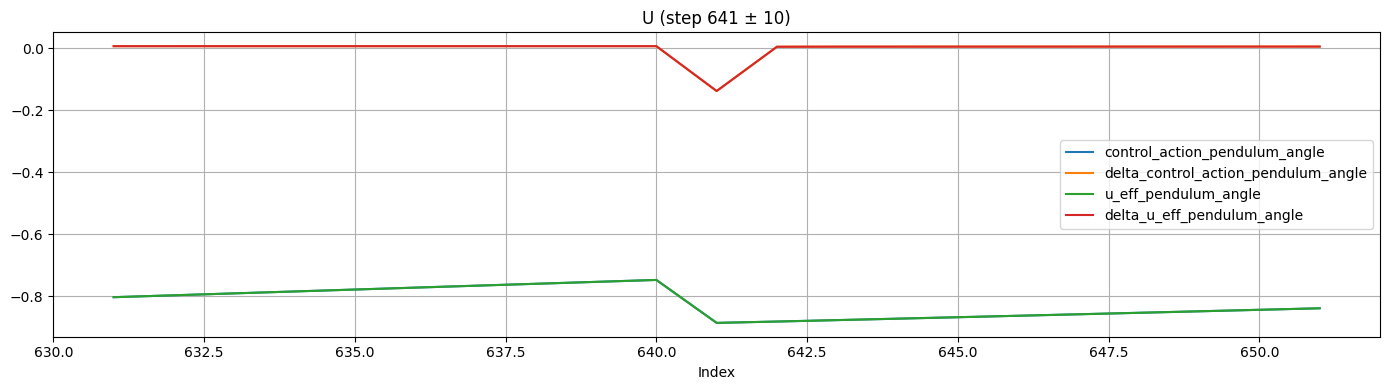


--- EVENT @ step 721 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
711,-0.091641,0.612196,-0.088094,0.581726,0.013988,9.5,7.5,0.5,-0.441120,0.005850,-0.441120,0.005850
712,-0.091028,0.614154,-0.087510,0.583654,0.013900,9.5,7.5,0.5,-0.435267,0.005853,-0.435267,0.005853
713,-0.090412,0.616070,-0.086925,0.585544,0.013814,9.5,7.5,0.5,-0.429412,0.005855,-0.429412,0.005855
714,-0.089795,0.617944,-0.086337,0.587393,0.013727,9.5,7.5,0.5,-0.423554,0.005857,-0.423554,0.005857
715,-0.089177,0.619777,-0.085748,0.589203,0.013641,9.5,7.5,0.5,-0.417695,0.005859,-0.417695,0.005859
716,-0.088556,0.621569,-0.085157,0.590973,0.013556,9.5,7.5,0.5,-0.411834,0.005861,-0.411834,0.005861
717,-0.087933,0.623320,-0.084564,0.592704,0.013472,9.5,7.5,0.5,-0.405973,0.005862,-0.405973,0.005862
718,-0.087309,0.625029,-0.083970,0.594396,0.013388,9.5,7.5,0.5,-0.400110,0.005863,-0.400110,0.005863
719,-0.086683,0.626697,-0.083374,0.596048,0.013304,9.5,7.5,0.5,-0.394247,0.005863,-0.394247,0.005863
720,-0.086056,0.628324,-0.082776,0.597660,0.013222,9.5,7.5,0.5,-0.388384,0.005863,-0.388384,0.005863


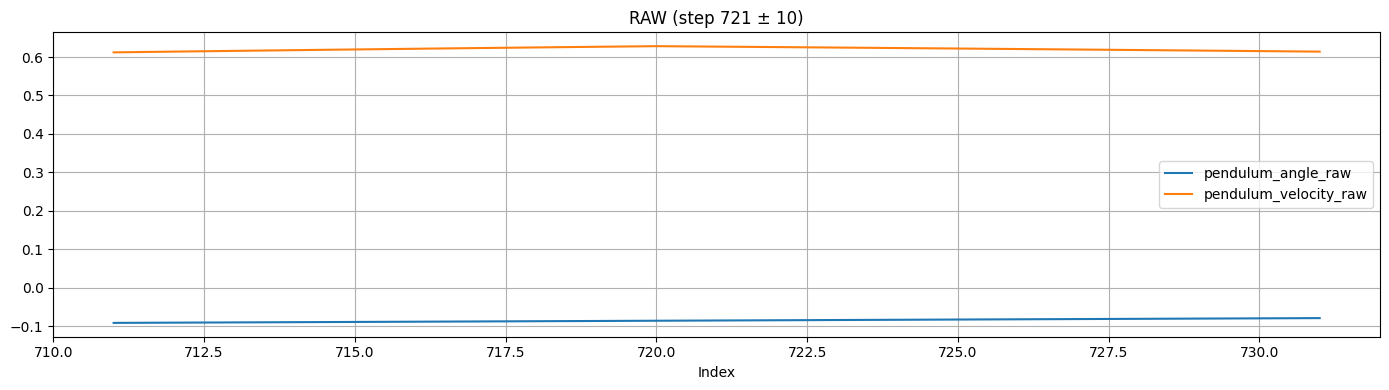

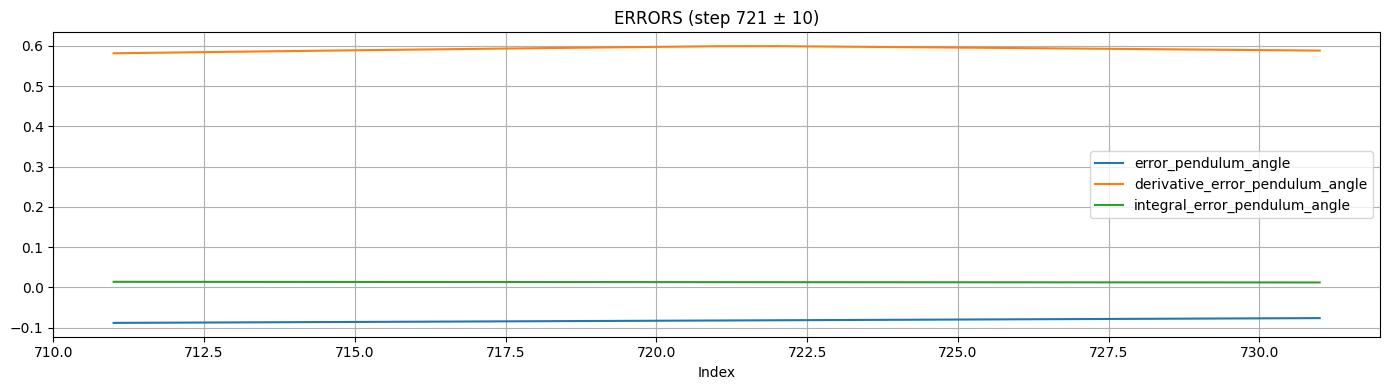

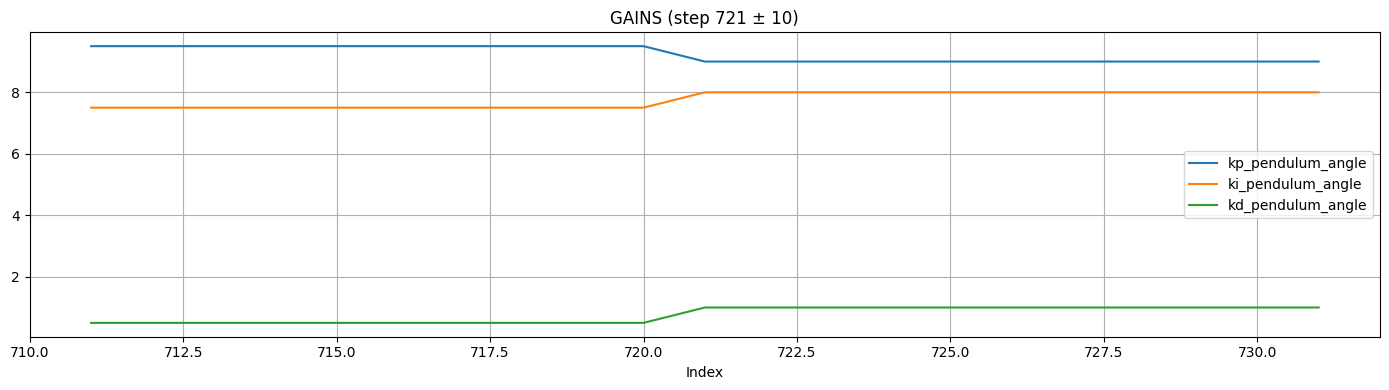

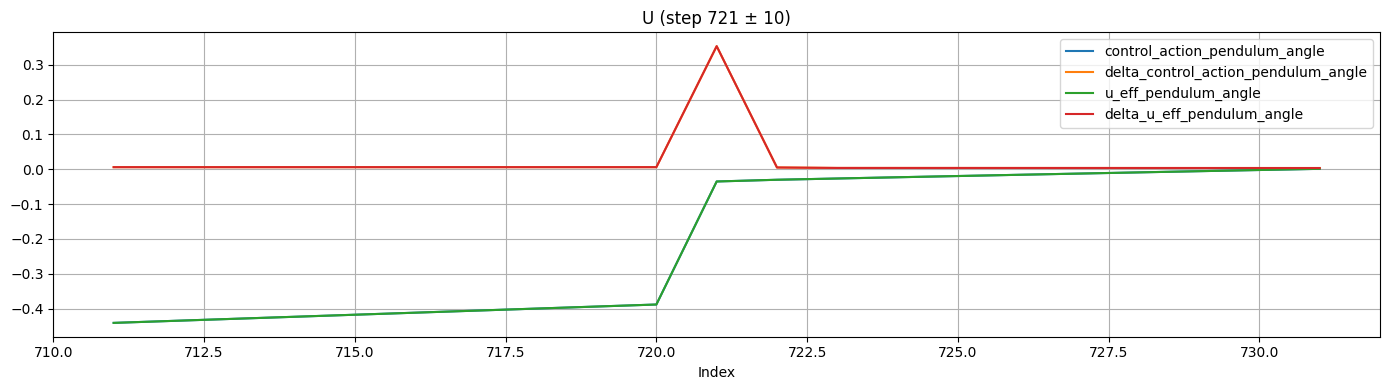


--- EVENT @ step 801 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
791,-0.045586,0.493112,-0.044003,0.472769,0.008797,10.0,7.5,1.0,0.098722,0.003160,0.098722,0.003160
792,-0.045093,0.491767,-0.043531,0.471512,0.008754,10.0,7.5,1.0,0.101854,0.003132,0.101854,0.003132
793,-0.044602,0.490403,-0.043061,0.470237,0.008711,10.0,7.5,1.0,0.104959,0.003104,0.104959,0.003104
794,-0.044113,0.489021,-0.042592,0.468944,0.008668,10.0,7.5,1.0,0.108035,0.003077,0.108035,0.003077
795,-0.043624,0.487619,-0.042124,0.467632,0.008626,10.0,7.5,1.0,0.111084,0.003049,0.111084,0.003049
796,-0.043137,0.486199,-0.041658,0.466303,0.008585,10.0,7.5,1.0,0.114105,0.003021,0.114105,0.003021
797,-0.042652,0.484761,-0.041193,0.464956,0.008543,10.0,7.5,1.0,0.117099,0.002993,0.117099,0.002993
798,-0.042168,0.483305,-0.040730,0.463591,0.008503,10.0,7.5,1.0,0.120065,0.002966,0.120065,0.002966
799,-0.041685,0.481831,-0.040267,0.462209,0.008462,10.0,7.5,1.0,0.123003,0.002938,0.123003,0.002938
800,-0.041204,0.480339,-0.039807,0.460810,0.008423,10.0,7.5,1.0,0.125913,0.002910,0.125913,0.002910


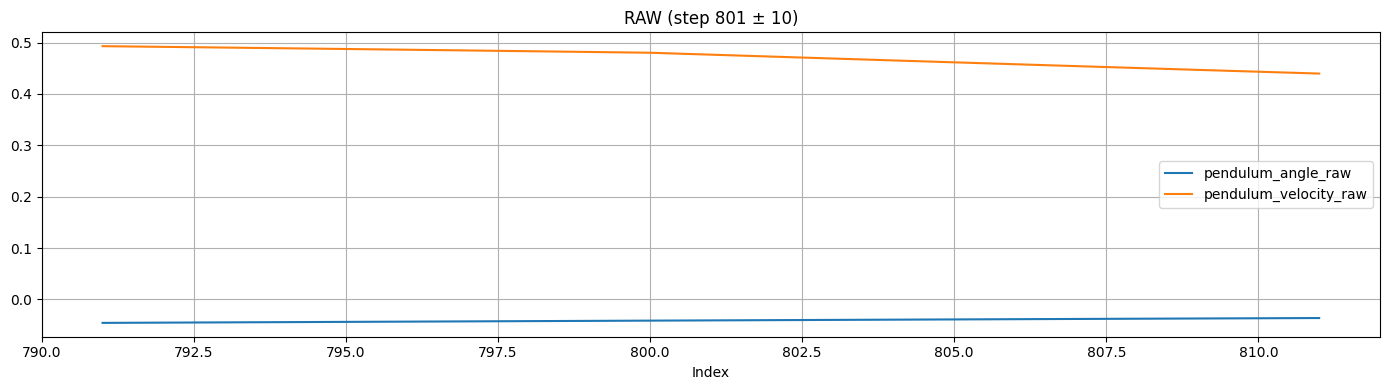

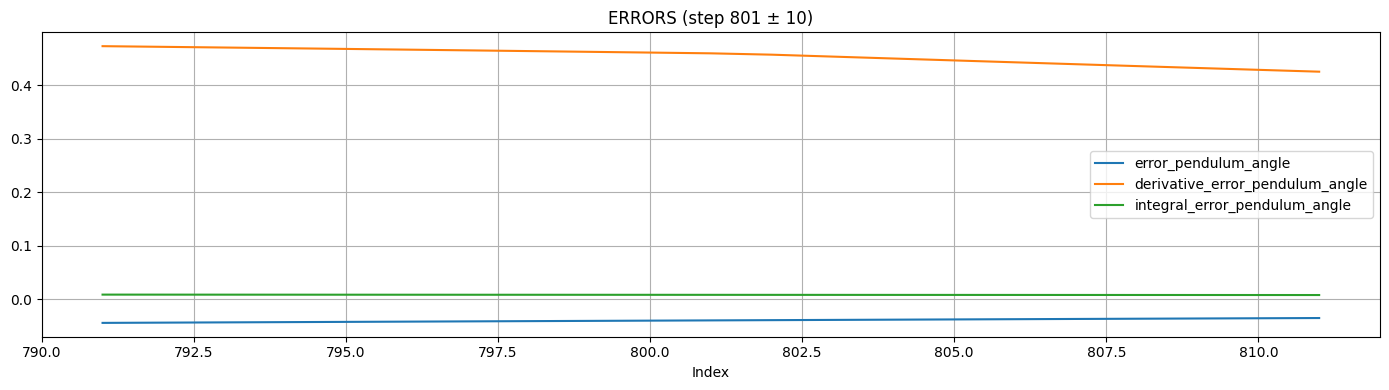

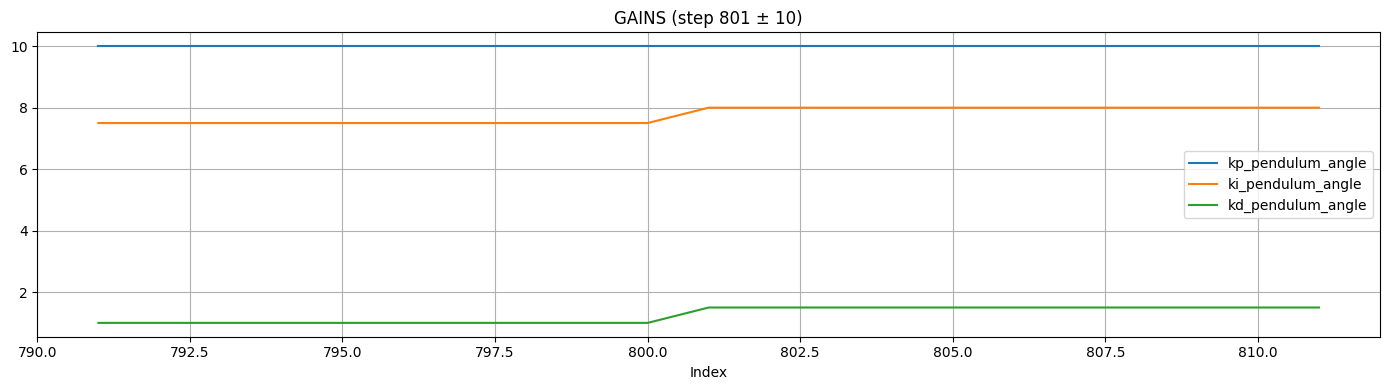

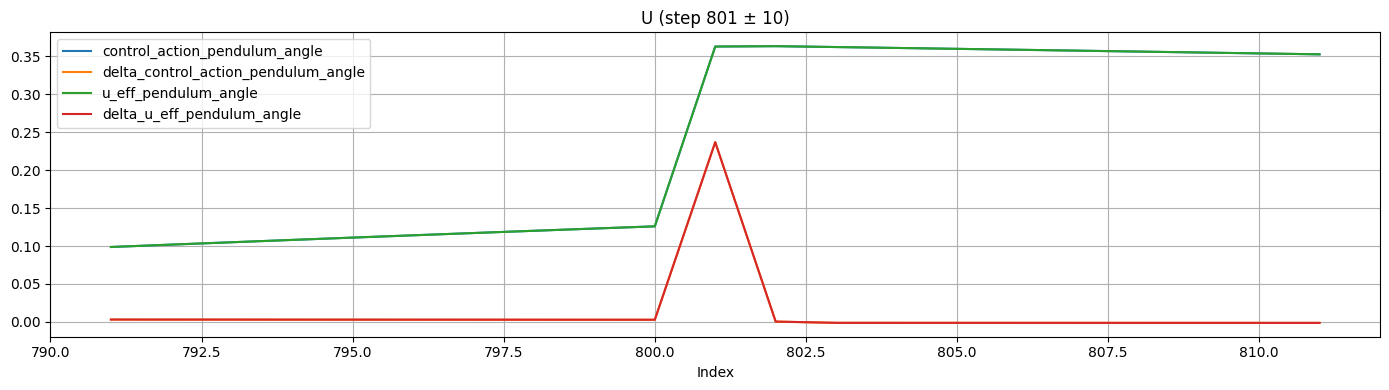

In [90]:
PIPE = {
    "Pendulum": {
        "gains":   ["kp_pendulum_angle", "ki_pendulum_angle", "kd_pendulum_angle"],
        "errors":  ["error_pendulum_angle", "derivative_error_pendulum_angle", "integral_error_pendulum_angle"],
        "u":       ["control_action_pendulum_angle", "delta_control_action_pendulum_angle",
                    "u_eff_pendulum_angle", "delta_u_eff_pendulum_angle"],
        "raw":     ["pendulum_angle_raw", "pendulum_velocity_raw"],
    },
    "Cart": {
        "gains":   ["kp_cart_position", "ki_cart_position", "kd_cart_position"],
        "errors":  ["error_cart_position", "derivative_error_cart_position", "integral_error_cart_position"],
        "u":       ["control_action_cart_position", "delta_control_action_cart_position",
                    "u_eff_cart_position", "delta_u_eff_cart_position"],
        "raw":     ["cart_position_raw", "cart_velocity_raw"],
    }
}

def plot_cols(df, cols, title="Plot", x_col=None, figsize=(14, 4)):
    x = df[x_col].to_numpy() if x_col and x_col in df.columns else np.arange(len(df))
    y_cols = [c for c in cols if c in df.columns]

    if not y_cols:
        return

    ax = df.plot(x=x_col if (x_col and x_col in df.columns) else None,
                 y=y_cols, figsize=figsize, title=title, grid=True)

    ax.set_xlabel(x_col if (x_col and x_col in df.columns) else "Index")
    plt.tight_layout()
    plt.show()
    
def cols_exist(df, cols): 
    return [c for c in cols if c in df.columns]

# --- 1) Vista “forense” de una ventana (elige idx) ---
def view_window(df, i, w=5, cols=None):
    a = max(0, i - w); b = min(len(df) - 1, i + w)
    return df.loc[a:b, cols] if cols else df.loc[a:b]

# --- 2) Plot secuencial por bloques (raw -> errors -> gains -> u) ---
def plot_pipeline(df, pipe, title_prefix="Pipeline", x_col=None):
    for block_name in ["raw", "errors", "gains", "u"]:
        cols = cols_exist(df, pipe.get(block_name, []))
        if cols:
            plot_walk(df, cols, x_col=x_col)  # usa tu plot_walk anterior

# --- 3) “Event-driven”: salta a puntos relevantes (saturación / grandes cambios de u) ---
def find_events(df, u_col, sat_col="is_saturated_global",
                top_du=20, min_gap=50):
    idx = set()

    if sat_col in df.columns:
        idx |= set(df.index[df[sat_col].astype(bool)])

    if u_col in df.columns:
        du = df[u_col].diff().abs()
        idx |= set(du.nlargest(top_du).index)

    idx = sorted(idx)
    # compacta para no mostrar puntos pegados
    out = []
    last = -10**9
    for i in idx:
        if i - last >= min_gap:
            out.append(i); last = i
    return out

# --- 4) Runner: para cada evento, muestra tabla + plots por bloque ---
def forensic_control_flow(df, pipe, events, w=5, x_col=None):
    # columnas que miras en tabla
    table_cols = cols_exist(df, sum([pipe.get(k, []) for k in ["raw","errors","gains","u"]], []))

    for i in events:
        print(f"\n--- EVENT @ step {i} ---")
        display(view_window(df, i, w=w, cols=table_cols))  # en notebook

        for block, cols in [("raw", pipe.get("raw", [])),
                            ("errors", pipe.get("errors", [])),
                            ("gains", pipe.get("gains", [])),
                            ("u", pipe.get("u", []))]:
            cols = cols_exist(df, cols)
            if cols:
                plot_cols(df.loc[max(0,i-w):min(len(df)-1,i+w), :], cols,
                          title=f"{block.upper()} (step {i} ± {w})",
                          x_col=x_col)

# --- 5) Uso (Péndulo) ---
p = PIPE["Pendulum"]

events = find_events(step_df,
                     u_col="u_eff_pendulum_angle" if "u_eff_pendulum_angle" in step_df.columns else "control_action_pendulum_angle",
                     sat_col="is_saturated_global",
                     top_du=25,
                     min_gap=80)

forensic_control_flow(step_df, p, events, w=10, x_col=None)

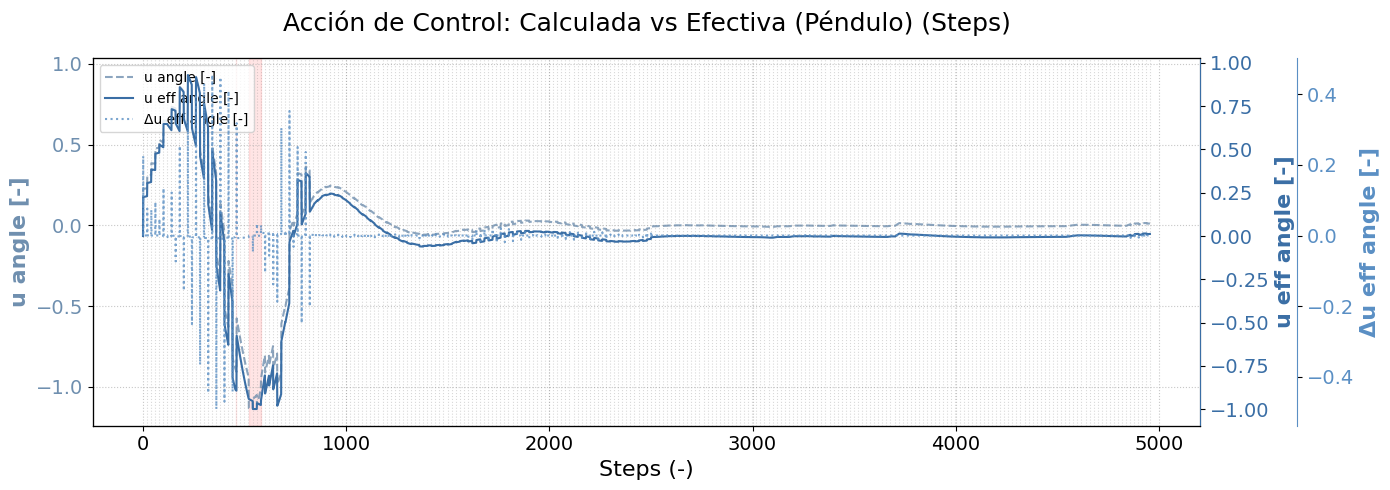

In [91]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_pendulum_angle', 'u_eff_pendulum_angle', 'delta_u_eff_pendulum_angle']

col_names = ['u angle [-]','u eff angle [-]', 'Δu eff angle [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Péndulo) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

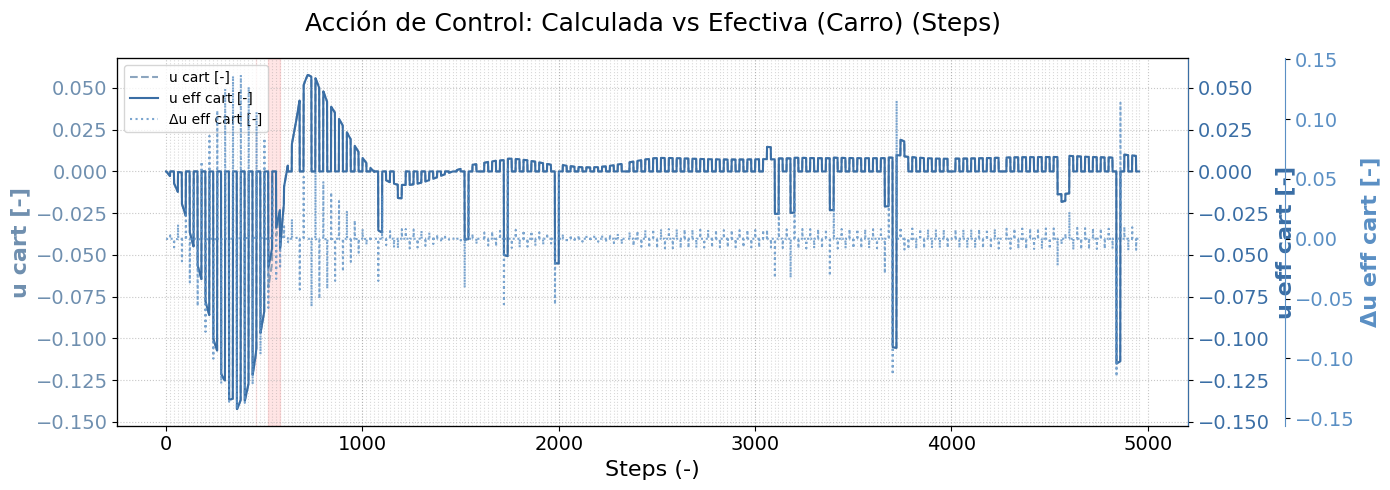

In [92]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_cart_position', 'u_eff_cart_position', 'delta_u_eff_cart_position']

col_names = ['u cart [-]', 'u eff cart [-]', 'Δu eff cart [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Carro) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

#### Análisis Ganancias

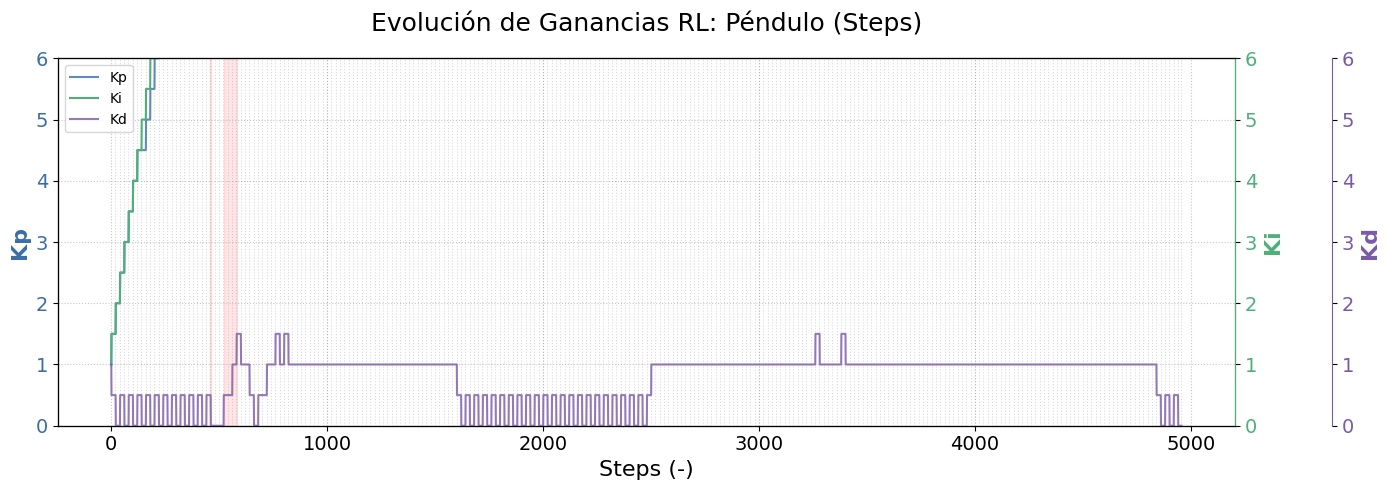

In [93]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_pendulum_angle', 'ki_pendulum_angle', 'kd_pendulum_angle']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alpha  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 6])

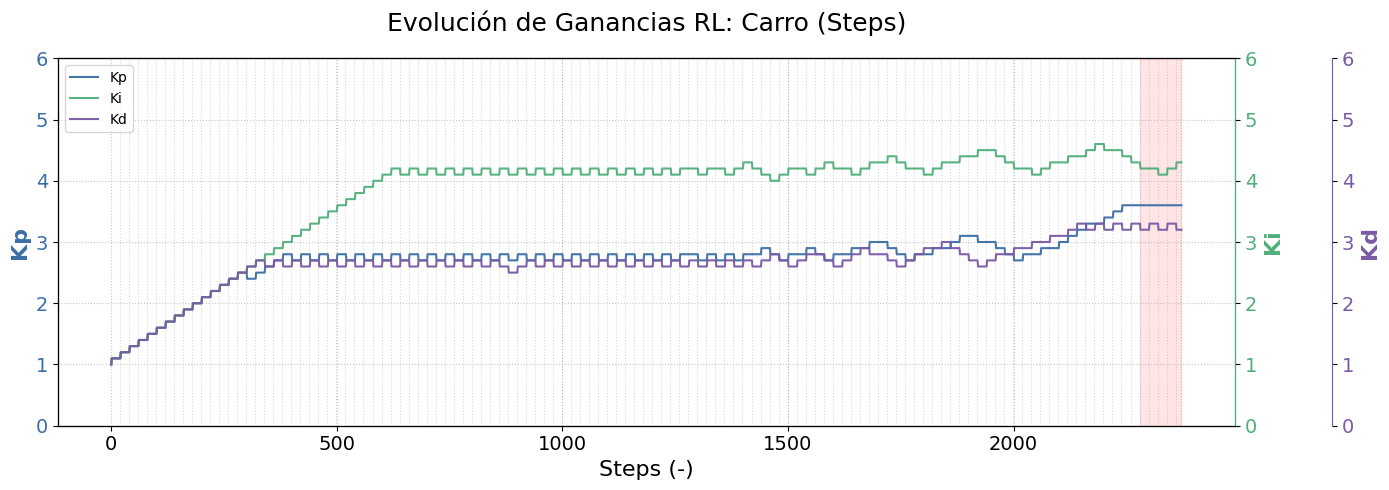

In [36]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_cart_position', 'ki_cart_position', 'kd_cart_position']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alphas  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 6])

In [94]:
dynamic_interval_df = interval_timeline_df.loc[:,['kp_pendulum_angle_mean','ki_pendulum_angle_mean','kd_pendulum_angle_mean']]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

In [95]:
dynamic_interval_df = interval_timeline_df.loc[:,['kp_cart_position_mean','ki_cart_position_mean','kd_cart_position_mean']]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

#### Análisis interno de los controladores

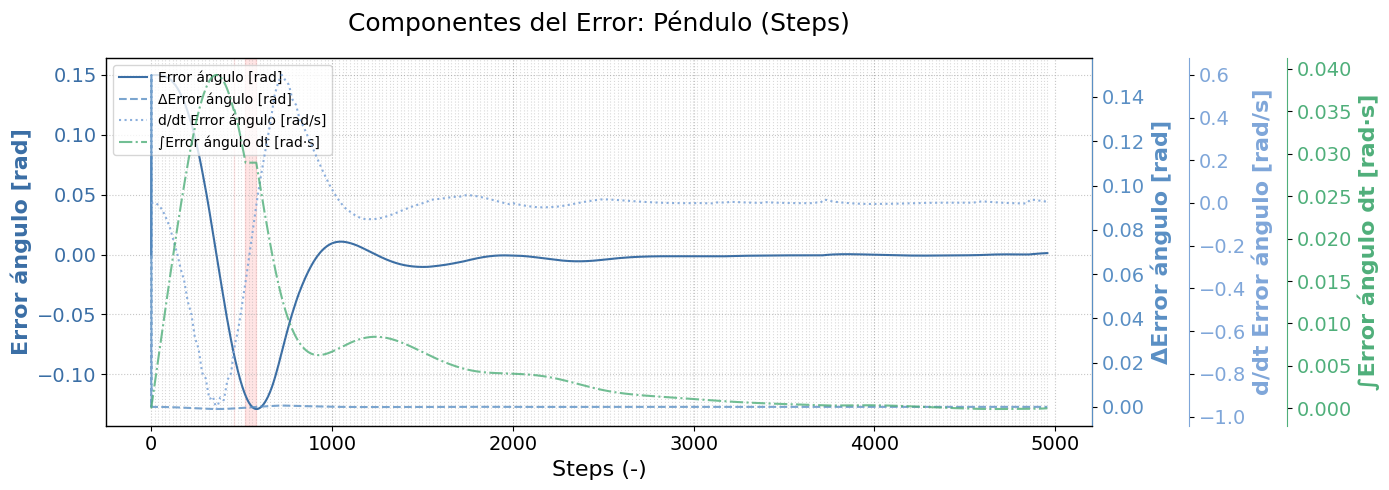

In [96]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_pendulum_angle', 'delta_error_pendulum_angle', 
                'derivative_error_pendulum_angle', 'integral_error_pendulum_angle']
col_names = ['Error ángulo [rad]', 'ΔError ángulo [rad]','d/dt Error ángulo [rad/s]', '∫Error ángulo dt [rad·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

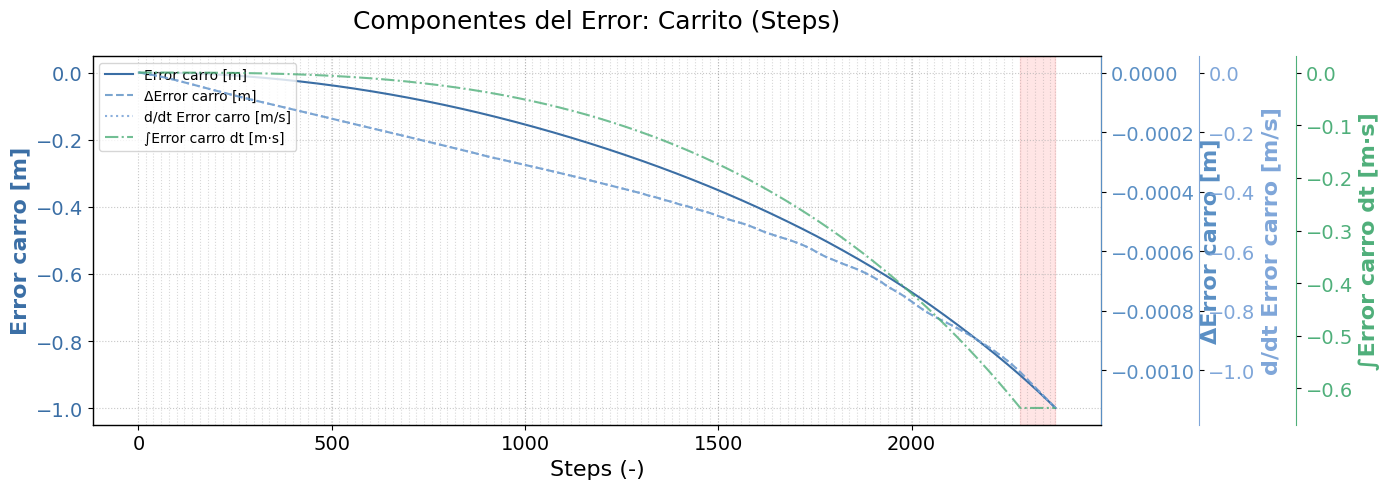

In [38]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_cart_position',
                'delta_error_cart_position',
                'derivative_error_cart_position',
                'integral_error_cart_position']

col_names = ['Error carro [m]', 'ΔError carro [m]',
             'd/dt Error carro [m/s]', '∫Error carro dt [m·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Carrito (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Caja Reward - Auditoría estructural y causal
- Se analiza la recompensa a nivel de intervalo usando únicamente las señales efectivamente persistidas en `interval_df`.
- La caja se divide en cuatro partes:
  1. inventario declarativo de la recompensa activa;
  2. descomposición estructural por familia;
  3. contraste entre reward y comportamiento físico/control;
  4. ventana forense local para reconstrucción causal.
- El objetivo no es solo ver cuánto reward hubo, sino entender qué bloque lo produjo, cómo se distribuyó y si quedó alineado con la evolución real del sistema.

In [123]:
reward_col_map = build_reward_column_map(interval_df)
reward_inventory_df = build_col_inventory_df(reward_col_map)
reward_config_df = build_reward_config_df(config_main)

principal_feature_df = build_active_principal_feature_df(config_main, interval_df)

principal_term_active_cols = get_active_available_principal_cols(principal_feature_df, 'term')
principal_gate_active_cols = get_active_available_principal_cols(principal_feature_df, 'gate')
principal_contrib_active_cols = get_active_available_principal_cols(principal_feature_df, 'contrib')

display(reward_config_df)
display(principal_feature_df)
display(reward_inventory_df)

,section,metric,value
0,reward_base,reward_approach,controller_reward
1,principal,enabled,True
2,principal,method,weighted_exponential
3,extras,enabled,True
4,coordination,enabled,True
5,principal,features,"[L_e, L_edot, L_I, L_u]"
6,extras,penalty_instantaneous_enabled,False
7,extras,penalty_delta_var_enabled,False
8,extras,goal_bonus_enabled,False
9,extras,band_bonus_enabled,False


,feature_name,var_obj,term_col,term_available,gate_col,gate_available,contrib_col,contrib_available
0,L_e,pendulum_angle,L_e_pendulum_angle,True,principal_gate_L_e_pendulum_angle,False,principal_contribution_L_e_pendulum_angle,False
1,L_e,cart_position,L_e_cart_position,True,principal_gate_L_e_cart_position,False,principal_contribution_L_e_cart_position,False
2,L_edot,pendulum_angle,L_edot_pendulum_angle,True,principal_gate_L_edot_pendulum_angle,True,principal_contribution_L_edot_pendulum_angle,True
3,L_edot,cart_position,L_edot_cart_position,True,principal_gate_L_edot_cart_position,True,principal_contribution_L_edot_cart_position,True
4,L_I,pendulum_angle,L_I_pendulum_angle,False,principal_gate_L_I_pendulum_angle,False,principal_contribution_L_I_pendulum_angle,False
5,L_I,cart_position,L_I_cart_position,False,principal_gate_L_I_cart_position,False,principal_contribution_L_I_cart_position,False
6,L_u,pendulum_angle,L_u_pendulum_angle,False,principal_gate_L_u_pendulum_angle,False,principal_contribution_L_u_pendulum_angle,False
7,L_u,cart_position,L_u_cart_position,False,principal_gate_L_u_cart_position,False,principal_contribution_L_u_cart_position,False


,family,n_cols,cols
0,principal_terms,6,"[L_e_pendulum_angle, L_e_cart_position, L_edot..."
1,principal_gates,4,"[principal_gate_L_edot_pendulum_angle, princip..."
2,principal_contributions,4,"[principal_contribution_L_edot_pendulum_angle,..."
3,processed_metric_aggregates,8,"[error_pendulum_angle_mean_squared, error_cart..."
4,agent_actions,6,"[action_kp_pendulum_angle, action_ki_pendulum_..."
5,global_reward,1,[global_interval_reward]
6,assigned_agent_rewards,6,"[reward_kp_pendulum_angle, reward_ki_pendulum_..."
7,extra_penalty_instantaneous,2,"[extra_penalty_instantaneous_pendulum_angle, e..."
8,extra_penalty_delta,2,"[extra_penalty_pendulum_angle, extra_penalty_c..."
9,extra_bonus_goal,2,"[extra_bonus_goal_pendulum_angle, extra_bonus_..."


In [125]:
reward_timeline_df['principal_component_rebuilt'] = row_sum_existing(
    interval_df,
    principal_contrib_active_cols
)

reward_timeline_df['principal_terms_active_sum'] = row_sum_existing(
    interval_df,
    principal_term_active_cols
)

reward_timeline_df['principal_gates_active_mean'] = row_mean_existing(
    interval_df,
    principal_gate_active_cols
)

reward_timeline_df['extra_penalty_total_rebuilt'] = (
    row_sum_existing(interval_df, reward_col_map['extra_penalty_instantaneous'])
    + row_sum_existing(interval_df, reward_col_map['extra_penalty_delta'])
)

reward_timeline_df['extra_goal_bonus_total_rebuilt'] = row_max_existing(
    interval_df,
    reward_col_map['extra_bonus_goal']
)

reward_timeline_df['extra_band_bonus_total_rebuilt'] = row_sum_existing(
    interval_df,
    reward_col_map['extra_bonus_band']
)

reward_timeline_df['extra_dynamic_penalty_total_rebuilt'] = row_sum_existing(
    interval_df,
    reward_col_map['extra_dynamic_penalty']
)

reward_timeline_df['extra_dynamic_incentive_total_rebuilt'] = row_sum_existing(
    interval_df,
    reward_col_map['extra_dynamic_incentive_total']
)

reward_timeline_df['extra_reward_rebuilt'] = (
    reward_timeline_df['extra_penalty_total_rebuilt']
    + reward_timeline_df['extra_goal_bonus_total_rebuilt']
    + reward_timeline_df['extra_band_bonus_total_rebuilt']
    + reward_timeline_df['extra_dynamic_penalty_total_rebuilt']
    + reward_timeline_df['extra_dynamic_incentive_total_rebuilt']
)

reward_timeline_df['coordination_bonus_by_loop_total_rebuilt'] = row_sum_existing(
    interval_df,
    reward_col_map['coordination_bonus_by_loop']
)

reward_timeline_df['coordination_reward_rebuilt'] = row_sum_existing(
    interval_df,
    reward_col_map['coordination_reward_total']
)

reward_timeline_df['assigned_reward_mean'] = row_mean_existing(
    interval_df,
    reward_col_map['assigned_agent_rewards']
)

reward_timeline_df['assigned_reward_std'] = (
    interval_df[reward_col_map['assigned_agent_rewards']]
    .apply(pd.to_numeric, errors='coerce')
    .std(axis=1)
    if len(reward_col_map['assigned_agent_rewards']) > 0
    else pd.Series(np.nan, index=interval_df.index, dtype=float)
)

reward_timeline_df['global_reward_gap_vs_rebuilt'] = (
    pd.to_numeric(reward_timeline_df['global_interval_reward'], errors='coerce')
    - (
        pd.to_numeric(reward_timeline_df['principal_component_rebuilt'], errors='coerce')
        + pd.to_numeric(reward_timeline_df['extra_reward_rebuilt'], errors='coerce')
        + pd.to_numeric(reward_timeline_df['coordination_reward_rebuilt'], errors='coerce')
    )
)

reward_timeline_df.head(5)

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,...,extra_dynamic_penalty_total_rebuilt,extra_dynamic_incentive_total_rebuilt,extra_reward_rebuilt,coordination_bonus_by_loop_total_rebuilt,coordination_reward_rebuilt,assigned_reward_mean,assigned_reward_std,global_reward_gap_vs_rebuilt,principal_terms_active_sum,principal_gates_active_mean
0,0,0,19,0.00,20,0.149927,0.000025,0.000380,0.003999,0.002534,...,0.0,0.0,0.0,0.0,0.0,-0.061676,0.067561,-0.123351,0.154331,1.0
1,1,20,39,0.02,20,0.149910,0.000155,0.003469,0.012719,0.000291,...,0.0,0.0,0.0,0.0,0.0,-0.062081,0.067980,-0.124136,0.166251,1.0
2,2,40,59,0.04,20,0.149677,0.000453,0.013962,0.024632,0.000268,...,0.0,0.0,0.0,0.0,0.0,-0.062406,0.068263,-0.124696,0.188724,1.0
3,3,60,79,0.06,20,0.149007,0.000967,0.032880,0.039841,0.000447,...,0.0,0.0,0.0,0.0,0.0,-0.062718,0.068448,-0.125052,0.222695,1.0
4,4,80,99,0.08,20,0.147643,0.001752,0.058529,0.057746,0.000110,...,0.0,0.0,0.0,0.0,0.0,-0.062323,0.067715,-0.123675,0.265670,1.0


In [127]:
reward_summary_rows = [
    {
        'section': 'principal',
        'metric': 'active_principal_features',
        'value': get_active_principal_feature_names(config_main)
    },
    {
        'section': 'principal',
        'metric': 'principal_component_sum',
        'value': float(pd.to_numeric(reward_timeline_df['principal_component_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'principal',
        'metric': 'principal_terms_active_sum',
        'value': float(pd.to_numeric(reward_timeline_df['principal_terms_active_sum'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_penalty_total_sum',
        'value': float(pd.to_numeric(reward_timeline_df['extra_penalty_total_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_goal_bonus_total_sum',
        'value': float(pd.to_numeric(reward_timeline_df['extra_goal_bonus_total_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_band_bonus_total_sum',
        'value': float(pd.to_numeric(reward_timeline_df['extra_band_bonus_total_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_dynamic_penalty_total_sum',
        'value': float(pd.to_numeric(reward_timeline_df['extra_dynamic_penalty_total_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_dynamic_incentive_total_sum',
        'value': float(pd.to_numeric(reward_timeline_df['extra_dynamic_incentive_total_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'extras',
        'metric': 'extra_reward_sum_total',
        'value': float(pd.to_numeric(reward_timeline_df['extra_reward_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'coordination',
        'metric': 'coordination_reward_sum_total',
        'value': float(pd.to_numeric(reward_timeline_df['coordination_reward_rebuilt'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'global',
        'metric': 'global_interval_reward_sum',
        'value': float(pd.to_numeric(reward_timeline_df['global_interval_reward'], errors='coerce').fillna(0.0).sum())
    },
    {
        'section': 'global',
        'metric': 'global_reward_gap_vs_rebuilt_mean_abs',
        'value': float(pd.to_numeric(reward_timeline_df['global_reward_gap_vs_rebuilt'], errors='coerce').abs().mean())
    },
]

reward_summary_df = pd.DataFrame(reward_summary_rows)
reward_summary_df

,section,metric,value
0,principal,active_principal_features,"[L_e, L_edot, L_I, L_u]"
1,principal,principal_component_sum,-0.902827
2,principal,principal_terms_active_sum,43.589544
3,extras,extra_penalty_total_sum,0.0
4,extras,extra_goal_bonus_total_sum,0.0
5,extras,extra_band_bonus_total_sum,0.0
6,extras,extra_dynamic_penalty_total_sum,0.0
7,extras,extra_dynamic_incentive_total_sum,0.0
8,extras,extra_reward_sum_total,0.0
9,coordination,coordination_reward_sum_total,0.047237


,available_cols,missing_cols
0,L_e_pendulum_angle,NaN
1,L_edot_pendulum_angle,NaN
2,pendulum_angle_mean_abs,NaN
3,pendulum_velocity_mean_abs,NaN
4,u_eff_pendulum_mean_abs,NaN


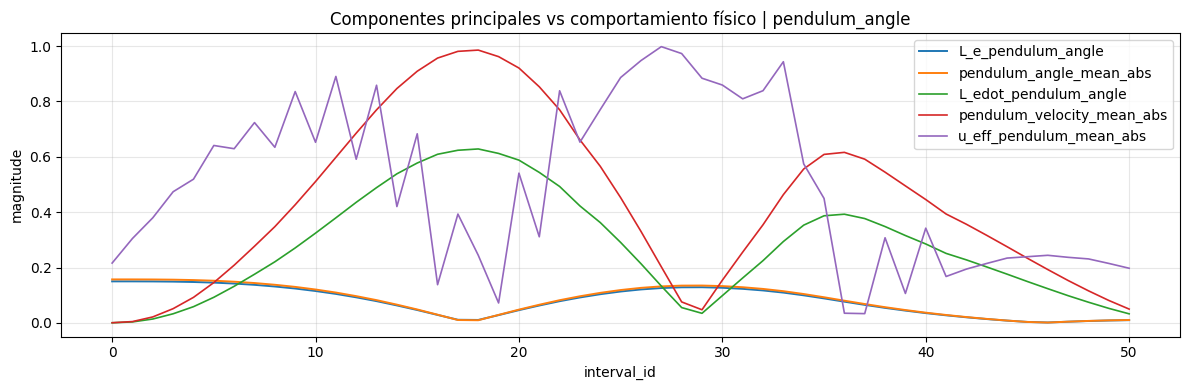

In [128]:
# --- CONFIGURACIÓN CELDA ---
VAR_OBJ = 'pendulum_angle'
I_START = 0
I_END = min(len(reward_timeline_df) - 1, 50)

if VAR_OBJ == 'pendulum_angle':
    phys_col = 'pendulum_angle_mean_abs'
    phys_dot_col = 'pendulum_velocity_mean_abs'
    effort_col = 'u_eff_pendulum_mean_abs'
else:
    phys_col = 'cart_position_mean_abs'
    phys_dot_col = 'cart_velocity_mean_abs'
    effort_col = 'u_eff_cart_mean_abs'

l_e_col = f'L_e_{VAR_OBJ}'
l_edot_col = f'L_edot_{VAR_OBJ}'
l_u_col = f'L_u_{VAR_OBJ}'

required_cols = [l_e_col, l_edot_col, phys_col, phys_dot_col, effort_col]
available_cols = [c for c in required_cols if c in reward_timeline_df.columns]
missing_cols = [c for c in required_cols if c not in reward_timeline_df.columns]

display(pd.DataFrame({
    'available_cols': pd.Series(available_cols),
    'missing_cols': pd.Series(missing_cols),
}))

plot_df = reward_timeline_df.loc[I_START:I_END].copy()

fig, ax = plt.subplots(figsize=(12, 4))

if l_e_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[l_e_col], label=l_e_col, linewidth=1.4)

if phys_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[phys_col], label=phys_col, linewidth=1.4)

if l_edot_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[l_edot_col], label=l_edot_col, linewidth=1.2)

if phys_dot_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[phys_dot_col], label=phys_dot_col, linewidth=1.2)

if l_u_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[l_u_col], label=l_u_col, linewidth=1.2)

if effort_col in plot_df.columns:
    ax.plot(plot_df['interval_id'], plot_df[effort_col], label=effort_col, linewidth=1.2)

ax.set_xlabel('interval_id')
ax.set_ylabel('magnitude')
ax.set_title(f'Componentes principales vs comportamiento físico | {VAR_OBJ}')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [129]:
principal_missing_df = principal_feature_df.loc[
    (~principal_feature_df['term_available']) |
    (~principal_feature_df['contrib_available'])
].copy()

principal_missing_df

,feature_name,var_obj,term_col,term_available,gate_col,gate_available,contrib_col,contrib_available
0,L_e,pendulum_angle,L_e_pendulum_angle,True,principal_gate_L_e_pendulum_angle,False,principal_contribution_L_e_pendulum_angle,False
1,L_e,cart_position,L_e_cart_position,True,principal_gate_L_e_cart_position,False,principal_contribution_L_e_cart_position,False
4,L_I,pendulum_angle,L_I_pendulum_angle,False,principal_gate_L_I_pendulum_angle,False,principal_contribution_L_I_pendulum_angle,False
5,L_I,cart_position,L_I_cart_position,False,principal_gate_L_I_cart_position,False,principal_contribution_L_I_cart_position,False
6,L_u,pendulum_angle,L_u_pendulum_angle,False,principal_gate_L_u_pendulum_angle,False,principal_contribution_L_u_pendulum_angle,False
7,L_u,cart_position,L_u_cart_position,False,principal_gate_L_u_cart_position,False,principal_contribution_L_u_cart_position,False


In [130]:
active_principal_term_view_df = interval_df[['interval_id'] + principal_term_active_cols].copy()
active_principal_term_view_df.head(10)

,interval_id,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position
0,0,0.149927,0.000025,0.000380,0.003999
1,1,0.149910,0.000155,0.003469,0.012719
2,2,0.149677,0.000453,0.013962,0.024632
3,3,0.149007,0.000967,0.032880,0.039841
4,4,0.147643,0.001752,0.058529,0.057746
5,5,0.145412,0.002843,0.092426,0.078765
6,6,0.142022,0.004300,0.132148,0.102024
7,7,0.137429,0.006129,0.175634,0.126498
8,8,0.131434,0.008368,0.220580,0.151315
9,9,0.124122,0.010995,0.270664,0.177736


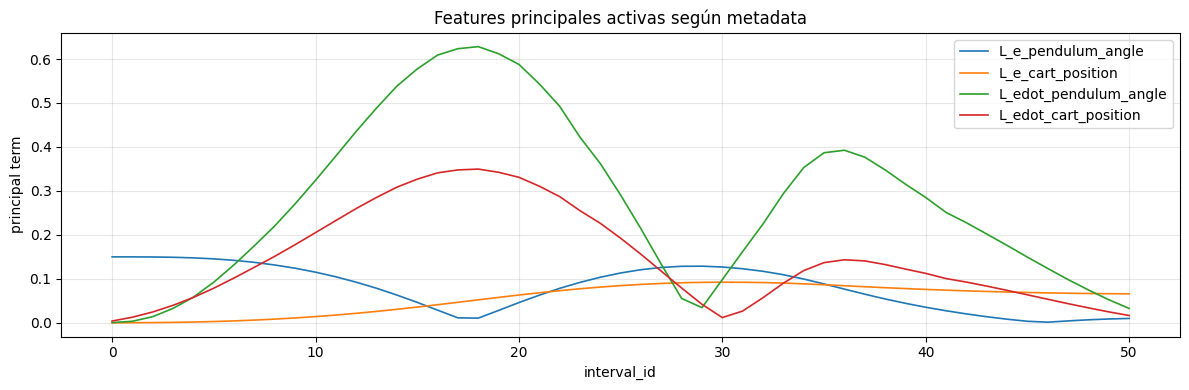

In [131]:
# --- CONFIGURACIÓN CELDA ---
I_START = 0
I_END = min(len(active_principal_term_view_df) - 1, 50)

plot_df = active_principal_term_view_df.loc[I_START:I_END].copy()

fig, ax = plt.subplots(figsize=(12, 4))

for col in principal_term_active_cols:
    ax.plot(plot_df['interval_id'], plot_df[col], label=col, linewidth=1.2)

ax.set_xlabel('interval_id')
ax.set_ylabel('principal term')
ax.set_title('Features principales activas según metadata')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

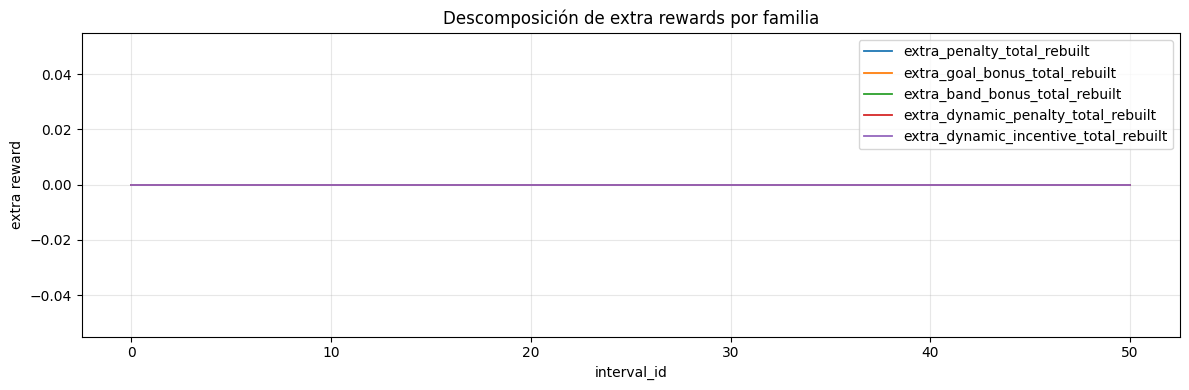

In [103]:
# --- CONFIGURACIÓN CELDA ---
I_START = 0
I_END = min(len(reward_timeline_df) - 1, 50)

plot_df = reward_timeline_df.loc[I_START:I_END].copy()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(plot_df['interval_id'], plot_df['extra_penalty_total_rebuilt'], label='extra_penalty_total_rebuilt', linewidth=1.3)
ax.plot(plot_df['interval_id'], plot_df['extra_goal_bonus_total_rebuilt'], label='extra_goal_bonus_total_rebuilt', linewidth=1.3)
ax.plot(plot_df['interval_id'], plot_df['extra_band_bonus_total_rebuilt'], label='extra_band_bonus_total_rebuilt', linewidth=1.3)
ax.plot(plot_df['interval_id'], plot_df['extra_dynamic_penalty_total_rebuilt'], label='extra_dynamic_penalty_total_rebuilt', linewidth=1.3)
ax.plot(plot_df['interval_id'], plot_df['extra_dynamic_incentive_total_rebuilt'], label='extra_dynamic_incentive_total_rebuilt', linewidth=1.3)

ax.set_xlabel('interval_id')
ax.set_ylabel('extra reward')
ax.set_title('Descomposición de extra rewards por familia')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [132]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_u_pendulum_angle', 
          'L_e_cart_position', 'L_edot_cart_position','L_u_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

KeyError: "['L_u_pendulum_angle', 'L_u_cart_position'] not in index"

In [110]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_u_pendulum_angle', 'reward_kp_pendulum_angle']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

KeyError: "['L_u_pendulum_angle'] not in index"

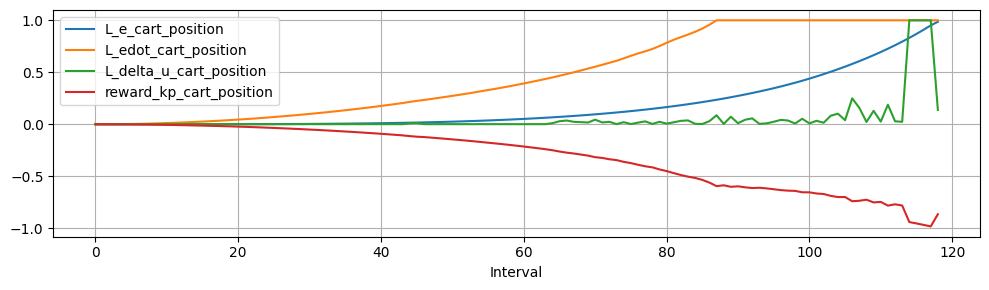

In [ ]:
y_cols = ['L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

In [ ]:
y_cols_cart = ['L_e_cart_position', 'L_edot_cart_position', 'L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols_cart, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
ax.set_title('Reward Components - Cart Position')
plt.tight_layout()
plt.show()

In [ ]:
# Recompensa global por intervalo
ax = interval_timeline_df.plot(x='interval_id', y='global_interval_reward', figsize=(10, 3), grid=True, color='purple')
ax.set_xlabel('Interval')
ax.set_title('Global Interval Reward')
plt.tight_layout()
plt.show()

## Caja 7 - Análisis de Episodios (Global)
- Extraemos las métricas finales (`end_episode_data`) de todos los episodios iterando sobre los chunks encontrados.
- Generamos un DataFrame global para ver la evolución del entrenamiento y del Reward.

In [ ]:
# Cargar un resumen de todos los episodios
global_records = []

for cf in chunk_files:
    try:
        chunk_data = load_json(cf)
        for ep in chunk_data:
            ep_id = extract_episode_id(ep)
            end_data = ep.get('end_episode_data', {})
            
            record = {'episode_id': ep_id}
            if end_data:
                record.update(end_data)
            
            global_records.append(record)
    except Exception as e:
        print(f"Error cargando {cf}: {e}")

global_df = pd.DataFrame(global_records).sort_values('episode_id').reset_index(drop=True)
print(f"Total episodios cargados: {len(global_df)}")
global_df.head()

In [ ]:
# Gráfico de evolución del Total Reward a lo largo de los episodios
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(global_df['episode_id'], global_df['total_reward'], color='tab:blue', alpha=0.6, label='Total Reward')
ax1.set_xlabel('Episode ID')
ax1.set_ylabel('Total Reward', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Epsilon en otro eje Y, si está presente
if 'epsilon' in global_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(global_df['episode_id'], global_df['epsilon'], color='tab:orange', linewidth=2, label='Epsilon')
    ax2.set_ylabel('Epsilon', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Evolución del Reward Total y Epsilon por Episodio')
fig.tight_layout()
plt.show()

In [ ]:
# Razón de terminación de los episodios (estadísticas)
if 'end_termination_reason' in global_df.columns:
    term_counts = global_df['end_termination_reason'].value_counts()
    print("Razones de terminación de episodio:")
    print(term_counts)
    
    # Gráfico de torta
    term_counts.plot.pie(autopct='%1.1f%%', figsize=(5,5))
    plt.title('Termination Reasons')
    plt.ylabel('')
    plt.show()